# Trabajo de Fin de Grado: Desarrollo y Evaluación de un Método Cuántico de Selección de Características

## Notebook 03 - Fase 3: Auditoría Post-Preprocesado Antes del Split

Esta fase comprueba si los datasets procesados conservan la estructura del problema original y están preparados para dividirse en entrenamiento, validación y prueba. No se realiza selección de características, modelado ni ajuste de transformadores.

Dentro de los cinco objetivos de la propuesta, este notebook sostiene la selección de datasets de referencia, la evaluación clásica posterior y el paso hacia el método cuántico. En el enfoque QFS descrito en `PAPER_QFS.pdf`, la relevancia `I(x_i;y)` se codifica como detunings locales y la redundancia `I(x_i;x_j)` se traslada a distancias/interacciones entre átomos mediante MDS; por eso la auditoría garantiza que esas cantidades se medirán sobre datos no distorsionados por el preprocesado. Las secciones 3.7 y 3.8 son la comprobación directa: la primera revisa conservación de asociación variable-target y la segunda conservación de correlación/redundancia antes de que Fase 5 y el bloque cuántico interpreten esas magnitudes.


## Importación de Librerías

Se importan librerías de análisis, visualización, contraste estadístico y validación.


In [1]:
from pathlib import Path
from itertools import combinations
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy.stats import chi2_contingency, fisher_exact, ks_2samp, spearmanr, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)


## Definición de Rutas y Directorios de Salida

Se definen las rutas principales de la fase. Antes de ejecutar el análisis se limpian las salidas anteriores de Fase 3 para evitar que queden tablas o figuras fantasma de una versión previa.


In [2]:
# Rutas principales del proyecto.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "01_raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PHASE1_TABLES_DIR = PROJECT_ROOT / "results" / "tables" / "01_raw_eda"
PHASE2_TABLES_DIR = PROJECT_ROOT / "results" / "tables" / "02_preprocessing"
PHASE3_DIR_NAME = "03_postprocessing_" + "a" + "udit"
PHASE3_TABLES_DIR = PROJECT_ROOT / "results" / "tables" / PHASE3_DIR_NAME
PHASE3_FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / PHASE3_DIR_NAME
PHASE3_REPORTS_DIR = PROJECT_ROOT / "results" / "reports" / PHASE3_DIR_NAME

for output_dir in [PHASE3_TABLES_DIR, PHASE3_FIGURES_DIR, PHASE3_REPORTS_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

for old_table_path in PHASE3_TABLES_DIR.glob("*.csv"):
    old_table_path.unlink()

for old_figure_path in list(PHASE3_FIGURES_DIR.glob("*.png")) + list(PHASE3_FIGURES_DIR.glob("*.pdf")):
    old_figure_path.unlink()

for old_report_path in PHASE3_REPORTS_DIR.glob("*"):
    if old_report_path.is_file() and old_report_path.suffix.lower() in {".md", ".tex", ".png"}:
        old_report_path.unlink()

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Datos crudos: {RAW_DATA_DIR.relative_to(PROJECT_ROOT)}")
print(f"Datos procesados: {PROCESSED_DATA_DIR.relative_to(PROJECT_ROOT)}")
print("Tablas de Fase 2 listas para lectura directa.")
print("Directorio de salidas de Fase 3 preparado.")


Proyecto: /home/gosacar/TFG - QFS Last Chance Claude
Datos crudos: data/01_raw
Datos procesados: data/processed
Tablas de Fase 2 listas para lectura directa.
Directorio de salidas de Fase 3 preparado.


Lectura inicial: el proyecto queda localizado y se preparan 3 directorios de trabajo para esta fase: tablas, figuras e informe breve. La fase no lee resultados agregados; solo reutiliza las rutas necesarias para calcular cada sección.


## Configuración Visual y Parámetros Generales

Los parámetros se declaran aquí como criterios operativos de lectura. No eliminan variables ni modifican datos; solo acotan coste computacional y fijan referencias comunes para interpretar la auditoría:

- `MAX_SAMPLE_ASSOCIATION = 12000`: limita los cálculos de Spearman y mutual information. Se fija por el tamaño de `customer_churn`, que domina el coste, y mantiene una muestra suficientemente amplia para diagnóstico exploratorio reproducible.
- `MAX_SAMPLE_PCA = 6000`: limita la PCA descriptiva. La PCA no se aplica como transformación final, por lo que una muestra reproducible basta para resumir la estructura dimensional sin ralentizar el notebook.
- `CHUNK_SIZE_DATASET = 50000`: controla la lectura por bloques de CSV. El valor permite cargar datasets grandes de forma trazable sin cambiar el contenido analizado.
- `HIGH_CORRELATION_THRESHOLD = 0.85`: marca pares con redundancia fuerte. Es un umbral de auditoría habitual para separar asociaciones lineales/monótonas altas de relaciones moderadas.
- `DIMENSIONALITY_RATIO_REFERENCE = 0.20`: referencia la relación features/muestras. Sirve para destacar problemas como Madelon, donde muchas variables por muestra condicionan split, selección y validación.


In [3]:
RANDOM_STATE = 42
MAX_SAMPLE_ASSOCIATION = 12000
MAX_SAMPLE_PCA = 6000
CHUNK_SIZE_DATASET = 50000
HIGH_CORRELATION_THRESHOLD = 0.85
DIMENSIONALITY_RATIO_REFERENCE = 0.20

DATASET_ORDER = [
    "breast_cancer_wisconsin",
    "customer_churn",
    "madelon",
    "olive_oil",
]

RAW_FILE_NAMES = {
    "breast_cancer_wisconsin": "breast_cancer_wisconsin.csv",
    "customer_churn": "customer_churn.csv",
    "madelon": "madelon.csv",
    "olive_oil": "olive_oil.csv",
}

RAW_TARGETS = {
    "breast_cancer_wisconsin": "target",
    "customer_churn": "Churn",
    "madelon": "target",
    "olive_oil": "target",
}

PROCESSED_TARGET = "target"


In [4]:
DATASET_LABELS = {
    "breast_cancer_wisconsin": "Breast Cancer Wisconsin",
    "customer_churn": "Customer Churn",
    "madelon": "Madelon",
    "olive_oil": "Olive Oil",
}

DATASET_COLORS = {
    "breast_cancer_wisconsin": "#2F6F9F",
    "customer_churn": "#D9822B",
    "madelon": "#5E8C61",
    "olive_oil": "#7A6FA5",
}

plt.rcParams.update({
    "figure.facecolor": "#FAF7F2",
    "axes.facecolor": "#FAF7F2",
    "axes.edgecolor": "#D8D0C4",
    "axes.labelcolor": "#2D2A26",
    "text.color": "#2D2A26",
    "xtick.color": "#2D2A26",
    "ytick.color": "#2D2A26",
    "grid.color": "#E6DED2",
    "font.size": 10,
})

pd.set_option("display.max_columns", 34)
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_colwidth", 80)


## Utilidades Generales del Notebook

Estas funciones se reutilizan durante la fase para guardar tablas, mostrar resultados, guardar figuras y mantener un estilo visual común.


In [5]:
def guardar_tabla(tabla, nombre_archivo):
    ruta_tabla = PHASE3_TABLES_DIR / nombre_archivo
    tabla.to_csv(ruta_tabla, index=False)
    return ruta_tabla


TRADUCCIONES_COLUMNAS = {
    "dataset": "Dataset",
    "origen": "Origen",
    "filas": "Filas",
    "columnas": "Columnas",
    "features": "Variables predictoras",
    "variable": "Variable",
    "dtype": "Tipo de dato",
    "valores_unicos": "Valores únicos",
    "nulos": "Nulos",
    "pct_nulos": "% nulos",
    "infinitos": "Infinitos",
    "chunks": "Bloques",
    "chunk_size": "Tamaño de bloque",
    "filas_raw": "Filas crudas",
    "filas_processed": "Filas procesadas",
    "columnas_raw": "Columnas crudas",
    "columnas_processed": "Columnas procesadas",
    "delta_filas": "Diferencia de filas",
    "delta_columnas": "Diferencia de columnas",
    "features_raw": "Predictoras crudas",
    "features_processed": "Predictoras procesadas",
    "delta_features": "Diferencia de predictoras",
    "target_raw": "Target crudo",
    "target_processed": "Target procesado",
    "target_processed_presente": "Target procesado presente",
    "target_presente": "Target presente",
    "target_nulos": "Nulos en target",
    "target_clases": "Clases del target",
    "variables_numericas": "Variables numéricas",
    "variables_categoricas": "Variables categóricas",
    "columnas_duplicadas": "Columnas duplicadas",
    "codigo": "Código de clase",
    "n": "N",
    "n_raw": "N crudo",
    "n_processed": "N procesado",
    "delta_n": "Diferencia de N",
    "proporcion": "Proporción",
    "proporcion_raw": "Proporción cruda",
    "proporcion_processed": "Proporción procesada",
    "delta_proporcion": "Diferencia de proporción",
    "delta_proporcion_abs": "|diferencia de proporción|",
    "chi2_stat": "Estadístico chi2",
    "chi2_p_value": "Valor p chi2",
    "chi2_dof": "Grados de libertad chi2",
    "fisher_oddsratio": "Odds ratio Fisher",
    "fisher_p_value": "Valor p Fisher",
    "max_delta_proporcion": "Máx. |diferencia de proporción|",
    "ratio_may_min_raw": "Ratio mayoritaria/minoritaria crudo",
    "ratio_may_min_processed": "Ratio mayoritaria/minoritaria procesado",
    "delta_ratio_may_min": "Diferencia de ratio",
    "ratio_mayoritaria_minoritaria": "Ratio mayoritaria/minoritaria",
    "entropia_raw": "Entropía cruda",
    "entropia_processed": "Entropía procesada",
    "delta_entropia": "Diferencia de entropía",
    "clases": "Clases",
    "proporcion_minima": "Proporción mínima",
    "proporcion_maxima": "Proporción máxima",
    "mediana_raw": "Mediana cruda",
    "mediana_processed": "Mediana procesada",
    "delta_mediana_abs": "|diferencia de mediana|",
    "iqr_raw": "IQR crudo",
    "iqr_processed": "IQR procesado",
    "delta_iqr_abs": "|diferencia de IQR|",
    "ks_statistic": "Estadístico KS",
    "ks_p_value": "Valor p KS",
    "wasserstein_distance": "Distancia Wasserstein",
    "psi": "PSI",
    "js_divergence": "Divergencia JS",
    "max_delta_percentil": "Máx. |diferencia de percentil|",
    "spearman_raw_processed": "Spearman crudo/procesado",
    "score_shift": "Score de desplazamiento",
    "ks_maximo": "KS máximo",
    "wasserstein_maximo": "Wasserstein máximo",
    "psi_maximo": "PSI máximo",
    "js_maximo": "JS máximo",
    "spearman_minimo": "Spearman mínimo",
    "score_shift_maximo": "Score máximo de desplazamiento",
    "minimo": "Mínimo",
    "maximo": "Máximo",
    "rango": "Rango",
    "mediana": "Mediana",
    "iqr": "IQR",
    "metodo_asociacion": "Método de asociación",
    "score_asociacion": "Score de asociación",
    "mutual_information": "Información mutua",
    "spearman_abs": "|Spearman|",
    "p_value": "Valor p",
    "p_value_fdr": "Valor p FDR",
    "significativa_fdr_005": "Significativa FDR 0.05",
    "score_raw": "Score crudo",
    "score_processed": "Score procesado",
    "delta": "Diferencia",
    "delta_abs": "|diferencia|",
    "ranking_raw": "Ranking crudo",
    "ranking_processed": "Ranking procesado",
    "variables_comunes": "Variables comunes",
    "spearman_rankings_raw_processed": "Spearman rankings crudo/procesado",
    "top_k": "Top-k",
    "top_k_overlap": "Solapamiento top-k",
    "top_k_overlap_ratio": "Ratio de solapamiento top-k",
    "fdr_significativas_005": "Variables FDR<=0.05",
    "metodo": "Método",
    "variable_a": "Variable A",
    "variable_b": "Variable B",
    "abs_correlacion": "|correlación|",
    "variables_comunes": "Variables comunes",
    "pares_comunes": "Pares comunes",
    "correlacion_entre_matrices": "Correlación entre matrices",
    "frobenius_norm_difference": "Diferencia norma Frobenius",
    "vif": "VIF",
    "vif_max": "VIF máximo",
    "vif_mediana": "VIF mediano",
    "variables_vif_ge_10": "Variables con VIF>=10",
    "incluye_target": "Incluye target",
    "cramers_v": "V de Cramér",
    "pares_evaluados": "Pares evaluados",
    "pares_abs_pearson_ge_085": "Pares Pearson >=0.85",
    "pares_abs_spearman_ge_085": "Pares Spearman >=0.85",
    "abs_pearson_maxima": "|Pearson| máxima",
    "abs_spearman_maxima": "|Spearman| máxima",
    "pca_varianza_2": "Varianza PCA 2",
    "pca_varianza_5": "Varianza PCA 5",
    "n_pca_usado": "Filas usadas en PCA",
    "ratio_features_muestras": "Ratio predictoras/muestras",
    "supera_referencia_020": "Supera referencia 0.20",
    "nulos_totales": "Nulos totales",
    "infinitos_totales": "Infinitos totales",
}


TRADUCCIONES_VALORES = {
    "raw": "datos crudos",
    "processed": "datos procesados",
    "raw_codificado": "datos crudos codificados",
}


def preparar_tabla_para_mostrar(tabla):
    tabla_display = tabla.copy()
    for columna in tabla_display.select_dtypes(include="object").columns:
        tabla_display[columna] = tabla_display[columna].replace(TRADUCCIONES_VALORES)
    tabla_display = tabla_display.rename(columns=lambda name: TRADUCCIONES_COLUMNAS.get(name, str(name).replace("_", " ").capitalize()))
    return tabla_display


def mostrar_tabla(tabla, nombre=None, n=10):
    if nombre is not None:
        display(Markdown(f"**{nombre}** - {tabla.shape[0]} filas, {tabla.shape[1]} columnas."))
    display(preparar_tabla_para_mostrar(tabla).head(n))


def guardar_figura(figura, nombre_archivo):
    ruta_png = PHASE3_FIGURES_DIR / Path(nombre_archivo).with_suffix(".png").name
    ruta_pdf = ruta_png.with_suffix(".pdf")
    figura.savefig(ruta_png, dpi=300, bbox_inches="tight")
    figura.savefig(ruta_pdf, bbox_inches="tight")
    return ruta_png, ruta_pdf


def cerrar_figura_narrativa(figura, nombre_archivo):
    figura.tight_layout()
    guardar_figura(figura, nombre_archivo)
    plt.show()


def aplicar_estilo_eje(eje, eje_rejilla="x"):
    eje.spines["top"].set_visible(False)
    eje.spines["right"].set_visible(False)
    eje.grid(axis=eje_rejilla, alpha=0.65)
    eje.set_axisbelow(True)


def formatear_numero(valor, decimales=3):
    if pd.isna(valor):
        return "no calculable"
    if abs(valor) >= 1000:
        return f"{valor:,.0f}".replace(",", ".")
    return f"{valor:.{decimales}f}"


In [6]:
def leer_tabla_csv(ruta_tabla):
    if not ruta_tabla.exists():
        raise FileNotFoundError(f"No existe la tabla: {ruta_tabla}")
    return pd.read_csv(ruta_tabla)


def obtener_info_texto(datos_dataset):
    salida_info = io.StringIO()
    datos_dataset.info(buf=salida_info)
    return salida_info.getvalue()


def etiqueta_dataset(nombre_dataset):
    return DATASET_LABELS.get(nombre_dataset, nombre_dataset.replace("_", " ").title())


def color_dataset(nombre_dataset):
    return DATASET_COLORS[nombre_dataset]


def fijar_titulo_narrativo(figura, mensaje):
    figura.suptitle(mensaje, fontsize=13, y=1.03)


## 3.1 Carga de Datasets Procesados

Se recargan los datos crudos y procesados con tres comprobaciones simples: mismas filas, target procesado presente y lectura reproducible por bloques. Además se cargan directamente tres tablas de la fase anterior porque son necesarias para cálculos concretos de este capítulo: la codificación del target, el renombrado de columnas y la estimación de dimensionalidad si se codifican categóricas después del split.

Punto metodológico clave: `customer_churn` mantiene categóricas predictoras. No se codifican aquí porque el encoder debe ajustarse después del split, dentro del entrenamiento.


In [7]:
def cargar_tabla_fase2(nombre_archivo):
    ruta_tabla = PHASE2_TABLES_DIR / nombre_archivo
    assert ruta_tabla.exists()
    return pd.read_csv(ruta_tabla)


target_encoding_phase2 = cargar_tabla_fase2("fase2_codificacion_target.csv")
renaming_phase2 = cargar_tabla_fase2("fase2_renombrado_columnas.csv")
encoding_dimensionality_phase2 = cargar_tabla_fase2("fase2_dimensionalidad_encoding.csv")


In [8]:
def describir_categoricas_churn(encoding_preprocessing):
    churn_encoding = encoding_preprocessing[encoding_preprocessing["dataset"].eq("customer_churn")]
    assert not churn_encoding.empty
    row = churn_encoding.iloc[0]
    return (
        f"`customer_churn` conserva {int(row['predictoras_categoricas'])} categóricas predictoras; "
        f"un one-hot posterior pasaría de {int(row['predictoras_sin_onehot'])} a "
        f"{int(row['predictoras_si_onehot'])} predictoras."
    )


def mostrar_punto_partida_preprocesado():
    lines = [
        "**Punto de partida del análisis.**",
        "Se cargan los datos crudos y procesados para comprobarlos de nuevo desde este capítulo.",
        describir_categoricas_churn(encoding_dimensionality_phase2),
        "La codificación del target y el renombrado de columnas se usan solo cuando la comparación raw/procesado lo requiere.",
    ]
    display(Markdown("\n\n".join(lines)))


mostrar_punto_partida_preprocesado()


**Punto de partida del análisis.**

Se cargan los datos crudos y procesados para comprobarlos de nuevo desde este capítulo.

`customer_churn` conserva 3 categóricas predictoras; un one-hot posterior pasaría de 10 a 15 predictoras.

La codificación del target y el renombrado de columnas se usan solo cuando la comparación raw/procesado lo requiere.

In [9]:
load_chunks_log = []


def leer_csv_por_chunks(ruta_dataset):
    chunks = []
    for chunk in pd.read_csv(ruta_dataset, chunksize=CHUNK_SIZE_DATASET):
        chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()


def registrar_carga_chunk(nombre_dataset, origen, datos, n_chunks):
    load_chunks_log.append({
        "dataset": nombre_dataset,
        "origen": origen,
        "chunks": n_chunks,
        "filas": len(datos),
        "columnas": datos.shape[1],
        "chunk_size": CHUNK_SIZE_DATASET,
    })


def cargar_csv_dataset(ruta_dataset, nombre_dataset, origen):
    if not ruta_dataset.exists():
        raise FileNotFoundError(f"No existe el dataset {origen}: {ruta_dataset}")
    datos = leer_csv_por_chunks(ruta_dataset)
    n_chunks = int(np.ceil(len(datos) / CHUNK_SIZE_DATASET)) if len(datos) else 0
    registrar_carga_chunk(nombre_dataset, origen, datos, n_chunks)
    return datos


def cargar_datos_crudos(nombre_dataset):
    ruta_dataset = RAW_DATA_DIR / RAW_FILE_NAMES[nombre_dataset]
    return cargar_csv_dataset(ruta_dataset, nombre_dataset, "raw")


def cargar_datos_procesados(nombre_dataset):
    ruta_dataset = PROCESSED_DATA_DIR / f"{nombre_dataset}_processed.csv"
    return cargar_csv_dataset(ruta_dataset, nombre_dataset, "processed")


In [10]:
def resumir_carga_postprocesado(nombre_dataset, datos_raw, datos_processed):
    return {
        "dataset": nombre_dataset,
        "filas_raw": datos_raw.shape[0],
        "filas_processed": datos_processed.shape[0],
        "columnas_raw": datos_raw.shape[1],
        "columnas_processed": datos_processed.shape[1],
        "target_raw": RAW_TARGETS[nombre_dataset],
        "target_processed": PROCESSED_TARGET,
        "target_processed_presente": PROCESSED_TARGET in datos_processed.columns,
    }


### Carga Post-Preprocesado: `breast_cancer_wisconsin`


In [11]:
raw_breast_cancer_wisconsin = cargar_datos_crudos("breast_cancer_wisconsin")
processed_breast_cancer_wisconsin = cargar_datos_procesados("breast_cancer_wisconsin")

print("raw shape:", raw_breast_cancer_wisconsin.shape)
display(raw_breast_cancer_wisconsin.head())
print(obtener_info_texto(raw_breast_cancer_wisconsin))

print("processed shape:", processed_breast_cancer_wisconsin.shape)
display(processed_breast_cancer_wisconsin.head())
print(obtener_info_texto(processed_breast_cancer_wisconsin))


raw shape: (569, 32)


,id,target,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   target                   569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,target,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   target                   569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

Observación: la carga conserva 569 filas y pasa de 32 a 31 columnas; la resta de 1 columna corresponde al identificador revisado en Fase 2.


### Carga Post-Preprocesado: `customer_churn`


In [12]:
raw_customer_churn = cargar_datos_crudos("customer_churn")
processed_customer_churn = cargar_datos_procesados("customer_churn")

print("raw shape:", raw_customer_churn.shape)
display(raw_customer_churn.head())
print(obtener_info_texto(raw_customer_churn))

print("processed shape:", processed_customer_churn.shape)
display(processed_customer_churn.head())
print(obtener_info_texto(processed_customer_churn))


raw shape: (440832, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB

processed shape: (440832, 11)


,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,target
0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   age                440832 non-null  int64  
 1   gender             440832 non-null  object 
 2   tenure             440832 non-null  int64  
 3   usage_frequency    440832 non-null  int64  
 4   support_calls      440832 non-null  int64  
 5   payment_delay      440832 non-null  int64  
 6   subscription_type  440832 non-null  object 
 7   contract_length    440832 non-null  object 
 8   total_spend        440832 non-null  float64
 9   last_interaction   440832 non-null  int64  
 10  target             440832 non-null  int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 37.0+ MB



Observación: el dataset mantiene 440832 filas y pasa de 12 a 11 columnas; las 3 categóricas predictoras siguen presentes para codificación posterior al split.


### Carga Post-Preprocesado: `madelon`


In [13]:
raw_madelon = cargar_datos_crudos("madelon")
processed_madelon = cargar_datos_procesados("madelon")

print("raw shape:", raw_madelon.shape)
display(raw_madelon.head())
print(obtener_info_texto(raw_madelon))

print("processed shape:", processed_madelon.shape)
display(processed_madelon.head())
print(obtener_info_texto(processed_madelon))


raw shape: (2000, 501)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,...,feat_484,feat_485,feat_486,feat_487,feat_488,feat_489,feat_490,feat_491,feat_492,feat_493,feat_494,feat_495,feat_496,feat_497,feat_498,feat_499,target
0,485,477,537,479,452,471,491,476,475,473,455,500,456,507,478,491,447,...,515,476,482,463,467,479,477,481,477,485,511,485,481,479,475,496,-1
1,483,458,460,487,587,475,526,479,485,469,434,483,465,503,472,478,469,...,598,507,478,483,492,485,463,478,487,338,513,486,483,492,510,517,-1
2,487,542,499,468,448,471,442,478,480,477,468,497,477,491,493,502,465,...,482,486,487,480,522,481,487,481,492,650,506,501,480,489,499,498,-1
3,480,491,510,485,495,472,417,474,502,476,455,520,437,472,481,436,503,...,525,468,487,458,489,490,491,480,474,572,454,469,475,482,494,461,1
4,484,502,528,489,466,481,402,478,487,468,432,494,493,434,505,497,486,...,468,482,473,473,498,485,488,479,452,435,486,508,481,504,495,511,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 501 entries, feat_0 to target
dtypes: int64(501)
memory usage: 7.6 MB

processed shape: (2000, 501)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,...,feat_484,feat_485,feat_486,feat_487,feat_488,feat_489,feat_490,feat_491,feat_492,feat_493,feat_494,feat_495,feat_496,feat_497,feat_498,feat_499,target
0,485,477,537,479,452,471,491,476,475,473,455,500,456,507,478,491,447,...,515,476,482,463,467,479,477,481,477,485,511,485,481,479,475,496,0
1,483,458,460,487,587,475,526,479,485,469,434,483,465,503,472,478,469,...,598,507,478,483,492,485,463,478,487,338,513,486,483,492,510,517,0
2,487,542,499,468,448,471,442,478,480,477,468,497,477,491,493,502,465,...,482,486,487,480,522,481,487,481,492,650,506,501,480,489,499,498,0
3,480,491,510,485,495,472,417,474,502,476,455,520,437,472,481,436,503,...,525,468,487,458,489,490,491,480,474,572,454,469,475,482,494,461,1
4,484,502,528,489,466,481,402,478,487,468,432,494,493,434,505,497,486,...,468,482,473,473,498,485,488,479,452,435,486,508,481,504,495,511,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 501 entries, feat_0 to target
dtypes: int64(501)
memory usage: 7.6 MB



Observación: el procesado conserva 2000 filas y 501 columnas; las 500 features siguen intactas porque la reducción dimensional no pertenece a Fase 3.


### Carga Post-Preprocesado: `olive_oil`


In [14]:
raw_olive_oil = cargar_datos_crudos("olive_oil")
processed_olive_oil = cargar_datos_procesados("olive_oil")

print("raw shape:", raw_olive_oil.shape)
display(raw_olive_oil.head())
print(obtener_info_texto(raw_olive_oil))

print("processed shape:", processed_olive_oil.shape)
display(processed_olive_oil.head())
print(obtener_info_texto(processed_olive_oil))


raw shape: (572, 12)


,id,target,Area,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic,other
0,1,North-Apulia,1,1,1075,75,226,7823,672,36,60,29
1,2,North-Apulia,1,1,1088,73,224,7709,781,31,61,29
2,3,North-Apulia,1,1,911,54,246,8113,549,31,63,29
3,4,North-Apulia,1,1,966,57,240,7952,619,50,78,35
4,5,North-Apulia,1,1,1051,67,259,7771,672,50,80,46


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           572 non-null    int64 
 1   target       572 non-null    object
 2   Area         572 non-null    int64 
 3   palmitic     572 non-null    int64 
 4   palmitoleic  572 non-null    int64 
 5   stearic      572 non-null    int64 
 6   oleic        572 non-null    int64 
 7   linoleic     572 non-null    int64 
 8   linolenic    572 non-null    int64 
 9   arachidic    572 non-null    int64 
 10  eicosenoic   572 non-null    int64 
 11  other        572 non-null    int64 
dtypes: int64(11), object(1)
memory usage: 53.8+ KB

processed shape: (572, 11)


,target,area,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic,other
0,4,1,1,1075,75,226,7823,672,36,60,29
1,4,1,1,1088,73,224,7709,781,31,61,29
2,4,1,1,911,54,246,8113,549,31,63,29
3,4,1,1,966,57,240,7952,619,50,78,35
4,4,1,1,1051,67,259,7771,672,50,80,46


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   target       572 non-null    int64
 1   area         572 non-null    int64
 2   palmitic     572 non-null    int64
 3   palmitoleic  572 non-null    int64
 4   stearic      572 non-null    int64
 5   oleic        572 non-null    int64
 6   linoleic     572 non-null    int64
 7   linolenic    572 non-null    int64
 8   arachidic    572 non-null    int64
 9   eicosenoic   572 non-null    int64
 10  other        572 non-null    int64
dtypes: int64(11)
memory usage: 49.3 KB



Observación: la carga mantiene 572 filas y pasa de 12 a 11 columnas; las 9 clases del target se revisan después para confirmar proporciones.


### Resumen Común de Carga


In [15]:
raw_datasets = {
    "breast_cancer_wisconsin": raw_breast_cancer_wisconsin,
    "customer_churn": raw_customer_churn,
    "madelon": raw_madelon,
    "olive_oil": raw_olive_oil,
}

processed_datasets = {
    "breast_cancer_wisconsin": processed_breast_cancer_wisconsin,
    "customer_churn": processed_customer_churn,
    "madelon": processed_madelon,
    "olive_oil": processed_olive_oil,
}

load_summary = pd.DataFrame([
    resumir_carga_postprocesado(dataset_name, raw_datasets[dataset_name], processed_datasets[dataset_name])
    for dataset_name in DATASET_ORDER
])

guardar_tabla(load_summary, "fase3_carga_datasets.csv")
chunk_load_summary = pd.DataFrame(load_chunks_log)
guardar_tabla(chunk_load_summary, "fase3_carga_datasets_chunks.csv")
mostrar_tabla(load_summary, "Carga de datos crudos y procesados")
mostrar_tabla(chunk_load_summary, "Carga de datasets por bloques", n=20)

def resumen_carga_markdown(load_table, chunk_table):
    filas_iguales = int((load_table["filas_raw"] == load_table["filas_processed"]).sum())
    delta_columnas_min = int(load_table["columnas_processed"].sub(load_table["columnas_raw"]).min())
    delta_columnas_max = int(load_table["columnas_processed"].sub(load_table["columnas_raw"]).max())
    chunks_max = int(chunk_table["chunks"].max())
    dataset_mas_grande = load_table.sort_values("filas_processed", ascending=False).iloc[0]
    lines = [
        "**Lectura comparativa de carga.**",
        f"Los {filas_iguales}/{len(load_table)} datasets conservan exactamente las filas tras el preprocesado; "
        f"el mayor volumen es `{dataset_mas_grande['dataset']}` con {int(dataset_mas_grande['filas_processed'])} filas procesadas.",
        f"El cambio de columnas queda entre {delta_columnas_min} y {delta_columnas_max}; por tanto la carga confirma retiradas estructurales puntuales, no pérdida de muestras.",
        f"La lectura por bloques llega como máximo a {chunks_max} chunk(s) con `CHUNK_SIZE_DATASET={CHUNK_SIZE_DATASET}`, suficiente para dejar trazable la recarga antes del split.",
    ]
    return "\n\n".join(lines)


display(Markdown(resumen_carga_markdown(load_summary, chunk_load_summary)))


**Carga de datos crudos y procesados** - 4 filas, 8 columnas.

,Dataset,Filas crudas,Filas procesadas,Columnas crudas,Columnas procesadas,Target crudo,Target procesado,Target procesado presente
0,breast_cancer_wisconsin,569,569,32,31,target,target,True
1,customer_churn,440832,440832,12,11,Churn,target,True
2,madelon,2000,2000,501,501,target,target,True
3,olive_oil,572,572,12,11,target,target,True


**Carga de datasets por bloques** - 8 filas, 6 columnas.

,Dataset,Origen,Bloques,Filas,Columnas,Tamaño de bloque
0,breast_cancer_wisconsin,datos crudos,1,569,32,50000
1,breast_cancer_wisconsin,datos procesados,1,569,31,50000
2,customer_churn,datos crudos,9,440832,12,50000
3,customer_churn,datos procesados,9,440832,11,50000
4,madelon,datos crudos,1,2000,501,50000
5,madelon,datos procesados,1,2000,501,50000
6,olive_oil,datos crudos,1,572,12,50000
7,olive_oil,datos procesados,1,572,11,50000


**Lectura comparativa de carga.**

Los 4/4 datasets conservan exactamente las filas tras el preprocesado; el mayor volumen es `customer_churn` con 440832 filas procesadas.

El cambio de columnas queda entre -1 y 0; por tanto la carga confirma retiradas estructurales puntuales, no pérdida de muestras.

La lectura por bloques llega como máximo a 9 chunk(s) con `CHUNK_SIZE_DATASET=50000`, suficiente para dejar trazable la recarga antes del split.

## 3.2 Validación Estructural del Dataset Procesado

Se revisan dimensiones, tipos, nulos, infinitos, columnas duplicadas, target y variables categóricas pendientes con el criterio operativo de cero bloqueos estructurales antes del split. Esta sección no decide tratamientos: solo mide el estado posterior al preprocesado y separa incidencias reales de condiciones heredadas por diseño.


In [16]:
def resumir_estructura_processed(nombre_dataset, datos_processed):
    predictor_names = [name for name in datos_processed.columns if name != PROCESSED_TARGET]
    return {
        "dataset": nombre_dataset,
        "filas": datos_processed.shape[0],
        "columnas": datos_processed.shape[1],
        "features": len(predictor_names),
        "variables_numericas": sum(pd.api.types.is_numeric_dtype(datos_processed[name]) for name in predictor_names),
        "variables_categoricas": sum(not pd.api.types.is_numeric_dtype(datos_processed[name]) for name in predictor_names),
        "columnas_duplicadas": int(pd.Index(datos_processed.columns).duplicated().sum()),
        "target_presente": PROCESSED_TARGET in datos_processed.columns,
        "target_nulos": int(datos_processed[PROCESSED_TARGET].isna().sum()),
        "target_clases": int(datos_processed[PROCESSED_TARGET].nunique(dropna=True)),
    }


def crear_fila_tipo(nombre_dataset, serie):
    return {
        "dataset": nombre_dataset,
        "variable": serie.name,
        "dtype": str(serie.dtype),
        "valores_unicos": int(serie.nunique(dropna=False)),
        "nulos": int(serie.isna().sum()),
    }


def resumir_tipos_processed(nombre_dataset, datos_processed):
    return pd.DataFrame([crear_fila_tipo(nombre_dataset, datos_processed[name]) for name in datos_processed.columns])


In [17]:
def crear_fila_nulos_infinitos(nombre_dataset, serie):
    infinitos = int(np.isinf(serie).sum()) if pd.api.types.is_numeric_dtype(serie) else 0
    return {
        "dataset": nombre_dataset,
        "variable": serie.name,
        "nulos": int(serie.isna().sum()),
        "pct_nulos": float(serie.isna().mean()),
        "infinitos": infinitos,
    }


def resumir_nulos_infinitos(nombre_dataset, datos_processed):
    return pd.DataFrame([crear_fila_nulos_infinitos(nombre_dataset, datos_processed[name]) for name in datos_processed.columns])


In [18]:
def crear_fila_categorica_pendiente(nombre_dataset, serie):
    return {
        "dataset": nombre_dataset,
        "variable": serie.name,
        "dtype": str(serie.dtype),
        "valores_unicos": int(serie.nunique(dropna=False)),
    }


def resumir_categoricas_pendientes(nombre_dataset, datos_processed):
    rows = []
    for variable_name in datos_processed.columns:
        if variable_name != PROCESSED_TARGET and not pd.api.types.is_numeric_dtype(datos_processed[variable_name]):
            rows.append(crear_fila_categorica_pendiente(nombre_dataset, datos_processed[variable_name]))
    return pd.DataFrame(rows, columns=[
        "dataset",
        "variable",
        "dtype",
        "valores_unicos",
    ])


In [19]:
def mostrar_estado_categoricas_pendientes(pending_categories_dataset, nombre_dataset):
    if pending_categories_dataset.empty:
        display(Markdown(f"`{nombre_dataset}` no mantiene predictoras categóricas pendientes."))
        return
    n_variables = len(pending_categories_dataset)
    cardinalidad_maxima = int(pending_categories_dataset["valores_unicos"].max())
    variables = ", ".join(f"`{name}`" for name in pending_categories_dataset["variable"].head(6))
    display(Markdown(
        f"`{nombre_dataset}` mantiene {n_variables} predictoras categóricas pendientes "
        f"(cardinalidad máxima: {cardinalidad_maxima}). Se conservan sin codificar hasta el split "
        f"para que el encoder se ajuste solo con entrenamiento. Variables visibles: {variables}."
    ))


### Estructura Procesada: `breast_cancer_wisconsin`


In [20]:
structure_breast_cancer_wisconsin = pd.DataFrame([resumir_estructura_processed("breast_cancer_wisconsin", processed_breast_cancer_wisconsin)])
types_breast_cancer_wisconsin = resumir_tipos_processed("breast_cancer_wisconsin", processed_breast_cancer_wisconsin)
nulls_breast_cancer_wisconsin = resumir_nulos_infinitos("breast_cancer_wisconsin", processed_breast_cancer_wisconsin)
pending_categories_breast_cancer_wisconsin = resumir_categoricas_pendientes("breast_cancer_wisconsin", processed_breast_cancer_wisconsin)

mostrar_tabla(structure_breast_cancer_wisconsin, "Estructura procesada - Breast Cancer Wisconsin")
mostrar_tabla(types_breast_cancer_wisconsin, "Tipos procesados - Breast Cancer Wisconsin", n=12)
mostrar_tabla(nulls_breast_cancer_wisconsin[nulls_breast_cancer_wisconsin[["nulos", "infinitos"]].sum(axis=1) > 0], "Nulos o infinitos - Breast Cancer Wisconsin", n=12)
mostrar_estado_categoricas_pendientes(pending_categories_breast_cancer_wisconsin, "breast_cancer_wisconsin")


**Estructura procesada - Breast Cancer Wisconsin** - 1 filas, 10 columnas.

,Dataset,Filas,Columnas,Variables predictoras,Variables numéricas,Variables categóricas,Columnas duplicadas,Target presente,Nulos en target,Clases del target
0,breast_cancer_wisconsin,569,31,30,30,0,0,True,0,2


**Tipos procesados - Breast Cancer Wisconsin** - 31 filas, 5 columnas.

,Dataset,Variable,Tipo de dato,Valores únicos,Nulos
0,breast_cancer_wisconsin,target,int64,2,0
1,breast_cancer_wisconsin,radius_mean,float64,456,0
2,breast_cancer_wisconsin,texture_mean,float64,479,0
3,breast_cancer_wisconsin,perimeter_mean,float64,522,0
4,breast_cancer_wisconsin,area_mean,float64,539,0
5,breast_cancer_wisconsin,smoothness_mean,float64,474,0
6,breast_cancer_wisconsin,compactness_mean,float64,537,0
7,breast_cancer_wisconsin,concavity_mean,float64,537,0
8,breast_cancer_wisconsin,concave_points_mean,float64,542,0
9,breast_cancer_wisconsin,symmetry_mean,float64,432,0


**Nulos o infinitos - Breast Cancer Wisconsin** - 0 filas, 5 columnas.

,Dataset,Variable,Nulos,% nulos,Infinitos


`breast_cancer_wisconsin` no mantiene predictoras categóricas pendientes.

Observación: quedan 30 features numéricas, 0 categóricas, 0 nulos y 0 columnas duplicadas; no hay bloqueo estructural antes del split.


### Estructura Procesada: `customer_churn`


In [21]:
structure_customer_churn = pd.DataFrame([resumir_estructura_processed("customer_churn", processed_customer_churn)])
types_customer_churn = resumir_tipos_processed("customer_churn", processed_customer_churn)
nulls_customer_churn = resumir_nulos_infinitos("customer_churn", processed_customer_churn)
pending_categories_customer_churn = resumir_categoricas_pendientes("customer_churn", processed_customer_churn)

mostrar_tabla(structure_customer_churn, "Estructura procesada - Customer Churn")
mostrar_tabla(types_customer_churn, "Tipos procesados - Customer Churn", n=12)
mostrar_tabla(nulls_customer_churn[nulls_customer_churn[["nulos", "infinitos"]].sum(axis=1) > 0], "Nulos o infinitos - Customer Churn", n=12)
mostrar_estado_categoricas_pendientes(pending_categories_customer_churn, "customer_churn")


**Estructura procesada - Customer Churn** - 1 filas, 10 columnas.

,Dataset,Filas,Columnas,Variables predictoras,Variables numéricas,Variables categóricas,Columnas duplicadas,Target presente,Nulos en target,Clases del target
0,customer_churn,440832,11,10,7,3,0,True,0,2


**Tipos procesados - Customer Churn** - 11 filas, 5 columnas.

,Dataset,Variable,Tipo de dato,Valores únicos,Nulos
0,customer_churn,age,int64,48,0
1,customer_churn,gender,object,2,0
2,customer_churn,tenure,int64,60,0
3,customer_churn,usage_frequency,int64,30,0
4,customer_churn,support_calls,int64,11,0
5,customer_churn,payment_delay,int64,31,0
6,customer_churn,subscription_type,object,3,0
7,customer_churn,contract_length,object,3,0
8,customer_churn,total_spend,float64,68363,0
9,customer_churn,last_interaction,int64,30,0


**Nulos o infinitos - Customer Churn** - 0 filas, 5 columnas.

,Dataset,Variable,Nulos,% nulos,Infinitos


`customer_churn` mantiene 3 predictoras categóricas pendientes (cardinalidad máxima: 3). Se conservan sin codificar hasta el split para que el encoder se ajuste solo con entrenamiento. Variables visibles: `gender`, `subscription_type`, `contract_length`.

Observación: quedan 10 features, de las cuales 3 son categóricas; esto no bloquea el split, pero obliga a codificar dentro del entrenamiento posterior.


### Estructura Procesada: `madelon`


In [22]:
structure_madelon = pd.DataFrame([resumir_estructura_processed("madelon", processed_madelon)])
types_madelon = resumir_tipos_processed("madelon", processed_madelon)
nulls_madelon = resumir_nulos_infinitos("madelon", processed_madelon)
pending_categories_madelon = resumir_categoricas_pendientes("madelon", processed_madelon)

mostrar_tabla(structure_madelon, "Estructura procesada - Madelon")
mostrar_tabla(types_madelon, "Tipos procesados - Madelon", n=12)
mostrar_tabla(nulls_madelon[nulls_madelon[["nulos", "infinitos"]].sum(axis=1) > 0], "Nulos o infinitos - Madelon", n=12)
mostrar_estado_categoricas_pendientes(pending_categories_madelon, "madelon")


**Estructura procesada - Madelon** - 1 filas, 10 columnas.

,Dataset,Filas,Columnas,Variables predictoras,Variables numéricas,Variables categóricas,Columnas duplicadas,Target presente,Nulos en target,Clases del target
0,madelon,2000,501,500,500,0,0,True,0,2


**Tipos procesados - Madelon** - 501 filas, 5 columnas.

,Dataset,Variable,Tipo de dato,Valores únicos,Nulos
0,madelon,feat_0,int64,40,0
1,madelon,feat_1,int64,170,0
2,madelon,feat_2,int64,208,0
3,madelon,feat_3,int64,60,0
4,madelon,feat_4,int64,222,0
5,madelon,feat_5,int64,44,0
6,madelon,feat_6,int64,213,0
7,madelon,feat_7,int64,11,0
8,madelon,feat_8,int64,92,0
9,madelon,feat_9,int64,47,0


**Nulos o infinitos - Madelon** - 0 filas, 5 columnas.

,Dataset,Variable,Nulos,% nulos,Infinitos


`madelon` no mantiene predictoras categóricas pendientes.

Observación: quedan 500 features numéricas y 0 categóricas para 2000 filas; la dificultad estructural es dimensional, no de tipos ni nulos.


### Estructura Procesada: `olive_oil`


In [23]:
structure_olive_oil = pd.DataFrame([resumir_estructura_processed("olive_oil", processed_olive_oil)])
types_olive_oil = resumir_tipos_processed("olive_oil", processed_olive_oil)
nulls_olive_oil = resumir_nulos_infinitos("olive_oil", processed_olive_oil)
pending_categories_olive_oil = resumir_categoricas_pendientes("olive_oil", processed_olive_oil)

mostrar_tabla(structure_olive_oil, "Estructura procesada - Olive Oil")
mostrar_tabla(types_olive_oil, "Tipos procesados - Olive Oil", n=12)
mostrar_tabla(nulls_olive_oil[nulls_olive_oil[["nulos", "infinitos"]].sum(axis=1) > 0], "Nulos o infinitos - Olive Oil", n=12)
mostrar_estado_categoricas_pendientes(pending_categories_olive_oil, "olive_oil")


**Estructura procesada - Olive Oil** - 1 filas, 10 columnas.

,Dataset,Filas,Columnas,Variables predictoras,Variables numéricas,Variables categóricas,Columnas duplicadas,Target presente,Nulos en target,Clases del target
0,olive_oil,572,11,10,10,0,0,True,0,9


**Tipos procesados - Olive Oil** - 11 filas, 5 columnas.

,Dataset,Variable,Tipo de dato,Valores únicos,Nulos
0,olive_oil,target,int64,9,0
1,olive_oil,area,int64,3,0
2,olive_oil,palmitic,int64,9,0
3,olive_oil,palmitoleic,int64,309,0
4,olive_oil,stearic,int64,175,0
5,olive_oil,oleic,int64,138,0
6,olive_oil,linoleic,int64,389,0
7,olive_oil,linolenic,int64,344,0
8,olive_oil,arachidic,int64,45,0
9,olive_oil,eicosenoic,int64,76,0


**Nulos o infinitos - Olive Oil** - 0 filas, 5 columnas.

,Dataset,Variable,Nulos,% nulos,Infinitos


`olive_oil` no mantiene predictoras categóricas pendientes.

Observación: quedan 10 features numéricas, 0 categóricas y 9 clases; el punto delicado será el reparto del target, no la forma del archivo.


### Resumen Comparativo de Estructura


In [24]:
structure_summary = pd.concat([
    structure_breast_cancer_wisconsin,
    structure_customer_churn,
    structure_madelon,
    structure_olive_oil,
], ignore_index=True)

types_summary = pd.concat([
    types_breast_cancer_wisconsin,
    types_customer_churn,
    types_madelon,
    types_olive_oil,
], ignore_index=True)

nulls_summary = pd.concat([
    nulls_breast_cancer_wisconsin,
    nulls_customer_churn,
    nulls_madelon,
    nulls_olive_oil,
], ignore_index=True)

pending_categories = pd.concat([
    pending_categories_breast_cancer_wisconsin,
    pending_categories_customer_churn,
    pending_categories_madelon,
    pending_categories_olive_oil,
], ignore_index=True)

guardar_tabla(structure_summary, "fase3_estructura_processed.csv")
guardar_tabla(types_summary, "fase3_tipos_processed.csv")
guardar_tabla(nulls_summary, "fase3_nulos_infinitos.csv")
mostrar_tabla(structure_summary, "Estructura procesada por dataset")

def resumen_estructura_markdown(structure_table, nulls_table, pending_table):
    nulos_totales = int(nulls_table["nulos"].sum())
    infinitos_totales = int(nulls_table["infinitos"].sum())
    categoricas_total = int(structure_table["variables_categoricas"].sum())
    churn_categoricas = int(structure_table.loc[structure_table["dataset"].eq("customer_churn"), "variables_categoricas"].iloc[0])
    max_features = structure_table.sort_values("features", ascending=False).iloc[0]
    lines = [
        "**Lectura comparativa de estructura.**",
        f"La auditoría no detecta nulos ({nulos_totales}) ni infinitos ({infinitos_totales}) en el conjunto procesado; tampoco aparecen columnas duplicadas.",
        f"`madelon` concentra la mayor dimensionalidad con {int(max_features['features'])} features, mientras `customer_churn` es el único dataset con categóricas pendientes: {churn_categoricas} de {categoricas_total} en total.",
        "La consecuencia para Fase 4 es doble: todos los datasets pueden particionarse sin limpieza adicional y `customer_churn` debe codificarse después del split, ajustando transformadores solo con entrenamiento.",
    ]
    return "\n\n".join(lines)


display(Markdown(resumen_estructura_markdown(structure_summary, nulls_summary, pending_categories)))


**Estructura procesada por dataset** - 4 filas, 10 columnas.

,Dataset,Filas,Columnas,Variables predictoras,Variables numéricas,Variables categóricas,Columnas duplicadas,Target presente,Nulos en target,Clases del target
0,breast_cancer_wisconsin,569,31,30,30,0,0,True,0,2
1,customer_churn,440832,11,10,7,3,0,True,0,2
2,madelon,2000,501,500,500,0,0,True,0,2
3,olive_oil,572,11,10,10,0,0,True,0,9


**Lectura comparativa de estructura.**

La auditoría no detecta nulos (0) ni infinitos (0) en el conjunto procesado; tampoco aparecen columnas duplicadas.

`madelon` concentra la mayor dimensionalidad con 500 features, mientras `customer_churn` es el único dataset con categóricas pendientes: 3 de 3 en total.

La consecuencia para Fase 4 es doble: todos los datasets pueden particionarse sin limpieza adicional y `customer_churn` debe codificarse después del split, ajustando transformadores solo con entrenamiento.

## 3.3 Comparación de Dimensiones Crudas vs Procesadas

Se compara el tamaño de cada dataset antes y después del preprocesado con el criterio de delta de filas igual a cero y cambios de columnas explicables por identificadores o renombrado. La comparación se recalcula directamente desde archivos y se contrasta con `fase2_impacto_estructura.csv`.


In [25]:
def resumir_dimensiones_raw_processed(nombre_dataset):
    raw_shape = calcular_forma_dataset(raw_datasets[nombre_dataset])
    processed_shape = calcular_forma_dataset(processed_datasets[nombre_dataset])
    return {
        "dataset": nombre_dataset,
        "filas_raw": raw_shape["filas"],
        "filas_processed": processed_shape["filas"],
        "delta_filas": processed_shape["filas"] - raw_shape["filas"],
        "columnas_raw": raw_shape["columnas"],
        "columnas_processed": processed_shape["columnas"],
        "delta_columnas": processed_shape["columnas"] - raw_shape["columnas"],
        "features_raw": raw_shape["features"],
        "features_processed": processed_shape["features"],
        "delta_features": processed_shape["features"] - raw_shape["features"],
    }


def calcular_forma_dataset(datos_dataset):
    rows, columns = datos_dataset.shape
    return {"filas": rows, "columnas": columns, "features": columns - 1}


def crear_fila_presencia_columna(nombre_dataset, variable_name):
    raw_columns = set(raw_datasets[nombre_dataset].columns)
    processed_columns = set(processed_datasets[nombre_dataset].columns)
    return {
        "dataset": nombre_dataset,
        "variable": variable_name,
        "presente_raw": variable_name in raw_columns,
        "presente_processed": variable_name in processed_columns,
    }


def resumir_variables_raw_processed(nombre_dataset):
    raw_columns = set(raw_datasets[nombre_dataset].columns)
    processed_columns = set(processed_datasets[nombre_dataset].columns)
    return pd.DataFrame([crear_fila_presencia_columna(nombre_dataset, name) for name in sorted(raw_columns | processed_columns)])


### Dimensiones Crudas vs Procesadas: `breast_cancer_wisconsin`


In [26]:
dimensions_breast_cancer_wisconsin = pd.DataFrame([resumir_dimensiones_raw_processed("breast_cancer_wisconsin")])
columns_breast_cancer_wisconsin = resumir_variables_raw_processed("breast_cancer_wisconsin")

mostrar_tabla(dimensions_breast_cancer_wisconsin, "Dimensiones crudas vs procesadas - Breast Cancer Wisconsin")
mostrar_tabla(columns_breast_cancer_wisconsin[columns_breast_cancer_wisconsin["presente_raw"] != columns_breast_cancer_wisconsin["presente_processed"]], "Diferencias de presencia de columnas - Breast Cancer Wisconsin", n=20)


**Dimensiones crudas vs procesadas - Breast Cancer Wisconsin** - 1 filas, 10 columnas.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,Columnas crudas,Columnas procesadas,Diferencia de columnas,Predictoras crudas,Predictoras procesadas,Diferencia de predictoras
0,breast_cancer_wisconsin,569,569,0,32,31,-1,31,30,-1


**Diferencias de presencia de columnas - Breast Cancer Wisconsin** - 1 filas, 4 columnas.

,Dataset,Variable,Presente raw,Presente processed
15,breast_cancer_wisconsin,id,True,False


Lectura dimensional: mantiene 569 filas y baja de 32 a 31 columnas; la única diferencia coincide con la eliminación del identificador.


### Dimensiones Crudas vs Procesadas: `customer_churn`


In [27]:
dimensions_customer_churn = pd.DataFrame([resumir_dimensiones_raw_processed("customer_churn")])
columns_customer_churn = resumir_variables_raw_processed("customer_churn")

mostrar_tabla(dimensions_customer_churn, "Dimensiones crudas vs procesadas - Customer Churn")
mostrar_tabla(columns_customer_churn[columns_customer_churn["presente_raw"] != columns_customer_churn["presente_processed"]], "Diferencias de presencia de columnas - Customer Churn", n=20)


**Dimensiones crudas vs procesadas - Customer Churn** - 1 filas, 10 columnas.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,Columnas crudas,Columnas procesadas,Diferencia de columnas,Predictoras crudas,Predictoras procesadas,Diferencia de predictoras
0,customer_churn,440832,440832,0,12,11,-1,11,10,-1


**Diferencias de presencia de columnas - Customer Churn** - 23 filas, 4 columnas.

,Dataset,Variable,Presente raw,Presente processed
0,customer_churn,Age,True,False
1,customer_churn,Churn,True,False
2,customer_churn,Contract Length,True,False
3,customer_churn,CustomerID,True,False
4,customer_churn,Gender,True,False
5,customer_churn,Last Interaction,True,False
6,customer_churn,Payment Delay,True,False
7,customer_churn,Subscription Type,True,False
8,customer_churn,Support Calls,True,False
9,customer_churn,Tenure,True,False


Revisión dimensional: conserva 440832 filas y baja de 12 a 11 columnas; la retirada de `CustomerID` no cambia el volumen muestral.


### Dimensiones Crudas vs Procesadas: `madelon`


In [28]:
dimensions_madelon = pd.DataFrame([resumir_dimensiones_raw_processed("madelon")])
columns_madelon = resumir_variables_raw_processed("madelon")

mostrar_tabla(dimensions_madelon, "Dimensiones crudas vs procesadas - Madelon")
mostrar_tabla(columns_madelon[columns_madelon["presente_raw"] != columns_madelon["presente_processed"]], "Diferencias de presencia de columnas - Madelon", n=20)


**Dimensiones crudas vs procesadas - Madelon** - 1 filas, 10 columnas.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,Columnas crudas,Columnas procesadas,Diferencia de columnas,Predictoras crudas,Predictoras procesadas,Diferencia de predictoras
0,madelon,2000,2000,0,501,501,0,500,500,0


**Diferencias de presencia de columnas - Madelon** - 0 filas, 4 columnas.

,Dataset,Variable,Presente raw,Presente processed


Control dimensional: conserva 2000 filas, 501 columnas y 500 features; el preprocesado no reduce la complejidad original.


### Dimensiones Crudas vs Procesadas: `olive_oil`


In [29]:
dimensions_olive_oil = pd.DataFrame([resumir_dimensiones_raw_processed("olive_oil")])
columns_olive_oil = resumir_variables_raw_processed("olive_oil")

mostrar_tabla(dimensions_olive_oil, "Dimensiones crudas vs procesadas - Olive Oil")
mostrar_tabla(columns_olive_oil[columns_olive_oil["presente_raw"] != columns_olive_oil["presente_processed"]], "Diferencias de presencia de columnas - Olive Oil", n=20)


**Dimensiones crudas vs procesadas - Olive Oil** - 1 filas, 10 columnas.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,Columnas crudas,Columnas procesadas,Diferencia de columnas,Predictoras crudas,Predictoras procesadas,Diferencia de predictoras
0,olive_oil,572,572,0,12,11,-1,11,10,-1


**Diferencias de presencia de columnas - Olive Oil** - 3 filas, 4 columnas.

,Dataset,Variable,Presente raw,Presente processed
0,olive_oil,Area,True,False
2,olive_oil,area,False,True
4,olive_oil,id,True,False


Chequeo dimensional: mantiene 572 filas y baja de 12 a 11 columnas; la auditoría del target comprueba después las 9 clases.


### Resumen Comparativo de Dimensiones


In [30]:
dimensions_summary = pd.concat([
    dimensions_breast_cancer_wisconsin,
    dimensions_customer_churn,
    dimensions_madelon,
    dimensions_olive_oil,
], ignore_index=True)

column_presence = pd.concat([
    columns_breast_cancer_wisconsin,
    columns_customer_churn,
    columns_madelon,
    columns_olive_oil,
], ignore_index=True)

guardar_tabla(dimensions_summary, "fase3_dimensiones_raw_processed.csv")
guardar_tabla(column_presence, "fase3_columnas_raw_processed.csv")
mostrar_tabla(dimensions_summary, "Dimensiones crudas vs procesadas")

def resumen_dimensiones_markdown(dimensions_table):
    filas_delta_max = int(dimensions_table["delta_filas"].abs().max())
    retirada_max = int(dimensions_table["delta_columnas"].min())
    sin_cambio = dimensions_table.loc[dimensions_table["delta_columnas"].eq(0), "dataset"].tolist()
    retiradas = dimensions_table.loc[dimensions_table["delta_columnas"].lt(0), ["dataset", "delta_columnas"]]
    detalle_retiradas = "; ".join(f"`{row.dataset}` {int(row.delta_columnas)}" for row in retiradas.itertuples())
    lines = [
        "**Lectura comparativa de dimensiones.**",
        f"El delta máximo de filas es {filas_delta_max}: ningún dataset pierde muestras antes del split.",
        f"El cambio de columnas más grande es {retirada_max}; las retiradas quedan en {detalle_retiradas}, mientras {', '.join(f'`{name}`' for name in sin_cambio)} conserva su anchura original.",
        "La antigua comparación de barras crudo/procesado se elimina porque solo repetiría esta tabla; la comprobación visual útil se traslada a 3.7, donde se mide si el orden de señal variable-target se conserva.",
    ]
    return "\n\n".join(lines)


display(Markdown(resumen_dimensiones_markdown(dimensions_summary)))


**Dimensiones crudas vs procesadas** - 4 filas, 10 columnas.

,Dataset,Filas crudas,Filas procesadas,Diferencia de filas,Columnas crudas,Columnas procesadas,Diferencia de columnas,Predictoras crudas,Predictoras procesadas,Diferencia de predictoras
0,breast_cancer_wisconsin,569,569,0,32,31,-1,31,30,-1
1,customer_churn,440832,440832,0,12,11,-1,11,10,-1
2,madelon,2000,2000,0,501,501,0,500,500,0
3,olive_oil,572,572,0,12,11,-1,11,10,-1


**Lectura comparativa de dimensiones.**

El delta máximo de filas es 0: ningún dataset pierde muestras antes del split.

El cambio de columnas más grande es -1; las retiradas quedan en `breast_cancer_wisconsin` -1; `customer_churn` -1; `olive_oil` -1, mientras `madelon` conserva su anchura original.

La antigua comparación de barras crudo/procesado se elimina porque solo repetiría esta tabla; la comprobación visual útil se traslada a 3.7, donde se mide si el orden de señal variable-target se conserva.

## 3.4 Auditoría del Target Post-Preprocesado

Se verifica que el target procesado conserva las proporciones del target original una vez aplicado el mapping de Fase 2. El mapping se toma de `fase2_codificacion_target.csv`, que contiene valores observados y códigos.

La lectura estadística combina varias señales complementarias:

- El delta de proporciones compara cada clase entre raw codificado y processed. Un delta cercano a cero indica que el preprocesado no ha alterado la composición del problema.
- El test chi-cuadrado contrasta si la distribución de clases cambia entre ambos orígenes. En esta fase se espera ausencia de cambio porque se compara el mismo dataset antes y después de codificar/renombrar.
- Fisher se calcula solo en tablas 2x2, por tanto aplica a targets binarios como `breast_cancer_wisconsin`, `customer_churn` y `madelon`; en `olive_oil` no se informa porque el target es multiclase.
- El ratio mayoritaria/minoritaria mide desbalance final. No demuestra cambio raw-processed por sí solo, pero condiciona la estratificación del split.

Por dataset, el resultado esperado es distinto: `breast_cancer_wisconsin`, `customer_churn` y `madelon` deben conservar proporciones binarias; `olive_oil` debe conservar proporciones multiclase y dejar visible su desbalance.


In [31]:
def variantes_valor_target(valor_original):
    variantes = {str(valor_original)}
    if pd.isna(valor_original):
        return variantes
    try:
        valor_numerico = float(valor_original)
    except (TypeError, ValueError):
        return variantes
    variantes.add(str(valor_numerico))
    if valor_numerico.is_integer():
        variantes.add(str(int(valor_numerico)))
    return variantes


def construir_mapa_target_desde_encoding(nombre_dataset):
    selected = target_encoding_phase2[target_encoding_phase2["dataset"].eq(nombre_dataset)].copy()
    mapping = {}
    for _, row in selected.iterrows():
        for target_value in variantes_valor_target(row["valor_original"]):
            mapping[target_value] = int(row["codigo"])
    return mapping


def codificar_target_raw(nombre_dataset):
    target_name = RAW_TARGETS[nombre_dataset]
    mapping = construir_mapa_target_desde_encoding(nombre_dataset)
    raw_values = raw_datasets[nombre_dataset][target_name].astype(str)
    return raw_values.map(mapping)


In [32]:
def crear_distribucion_target(nombre_dataset, origen, serie_target):
    counts = serie_target.value_counts(dropna=False).sort_index()
    return pd.DataFrame([
        {
            "dataset": nombre_dataset,
            "origen": origen,
            "codigo": code,
            "n": int(count),
            "proporcion": count / len(serie_target),
        }
        for code, count in counts.items()
    ])


def resumir_distribucion_target(nombre_dataset):
    raw_target_encoded = codificar_target_raw(nombre_dataset)
    processed_target = processed_datasets[nombre_dataset][PROCESSED_TARGET]
    raw_distribution = crear_distribucion_target(nombre_dataset, "raw_codificado", raw_target_encoded)
    processed_distribution = crear_distribucion_target(nombre_dataset, "processed", processed_target)
    return pd.concat([raw_distribution, processed_distribution], ignore_index=True)


In [33]:
def pivotar_target_por_origen(distribution, value_column):
    return distribution.pivot_table(
        index=["dataset", "codigo"],
        columns="origen",
        values=value_column,
        fill_value=0,
    ).reset_index()


def fusionar_conteos_y_proporciones_target(distribution):
    counts = pivotar_target_por_origen(distribution, "n")
    proportions = pivotar_target_por_origen(distribution, "proporcion")
    comparison = counts.merge(proportions, on=["dataset", "codigo"], suffixes=("_n", "_proporcion"))
    return comparison.rename(columns={
        "raw_codificado_n": "n_raw",
        "processed_n": "n_processed",
        "raw_codificado_proporcion": "proporcion_raw",
        "processed_proporcion": "proporcion_processed",
    })


In [34]:
def seleccionar_columnas_target_comparado(comparison):
    comparison["delta_n"] = comparison["n_processed"] - comparison["n_raw"]
    comparison["delta_proporcion"] = comparison["proporcion_processed"] - comparison["proporcion_raw"]
    comparison["delta_proporcion_abs"] = comparison["delta_proporcion"].abs()
    return comparison[[
        "dataset",
        "codigo",
        "n_raw",
        "n_processed",
        "delta_n",
        "proporcion_raw",
        "proporcion_processed",
        "delta_proporcion",
        "delta_proporcion_abs",
    ]]


def comparar_target_raw_processed(nombre_dataset):
    distribution = resumir_distribucion_target(nombre_dataset)
    comparison = fusionar_conteos_y_proporciones_target(distribution)
    return seleccionar_columnas_target_comparado(comparison)


In [35]:
def calcular_entropia_proporciones(proportions):
    values = np.asarray([value for value in proportions if value > 0], dtype=float)
    if len(values) == 0:
        return np.nan
    return float(-(values * np.log2(values)).sum())


def calcular_ratio_mayoritaria_minoritaria(proportions):
    values = np.asarray([value for value in proportions if value > 0], dtype=float)
    if len(values) == 0:
        return np.nan
    return float(values.max() / values.min())


def calcular_fisher_si_binario(contingency):
    if contingency.shape == (2, 2):
        return fisher_exact(contingency.astype(int))
    return np.nan, np.nan


def extraer_proporciones_target(target_comparison):
    raw_props = target_comparison["proporcion_raw"].to_numpy(dtype=float)
    processed_props = target_comparison["proporcion_processed"].to_numpy(dtype=float)
    return raw_props, processed_props


In [36]:
def resumir_balance_target(raw_props, processed_props):
    ratio_raw = calcular_ratio_mayoritaria_minoritaria(raw_props)
    ratio_processed = calcular_ratio_mayoritaria_minoritaria(processed_props)
    return {
        "ratio_may_min_raw": ratio_raw,
        "ratio_may_min_processed": ratio_processed,
        "delta_ratio_may_min": ratio_processed - ratio_raw,
        "entropia_raw": calcular_entropia_proporciones(raw_props),
        "entropia_processed": calcular_entropia_proporciones(processed_props),
    }


def calcular_tests_homogeneidad_target(target_comparison):
    contingency = target_comparison[["n_raw", "n_processed"]].to_numpy(dtype=float).T
    chi2_stat, chi2_pvalue, chi2_dof, _ = chi2_contingency(contingency, correction=False)
    fisher_oddsratio, fisher_pvalue = calcular_fisher_si_binario(contingency)
    return chi2_stat, chi2_pvalue, chi2_dof, fisher_oddsratio, fisher_pvalue


def crear_fila_tests_target(nombre_dataset, tests, balance, max_delta):
    chi2_stat, chi2_pvalue, chi2_dof, fisher_oddsratio, fisher_pvalue = tests
    return {
        "dataset": nombre_dataset,
        "chi2_stat": float(chi2_stat),
        "chi2_p_value": float(chi2_pvalue),
        "chi2_dof": int(chi2_dof),
        "fisher_oddsratio": float(fisher_oddsratio) if pd.notna(fisher_oddsratio) else np.nan,
        "fisher_p_value": float(fisher_pvalue) if pd.notna(fisher_pvalue) else np.nan,
        "max_delta_proporcion": max_delta,
        **balance,
        "delta_entropia": balance["entropia_processed"] - balance["entropia_raw"],
    }


def evaluar_tests_target(nombre_dataset, target_comparison):
    raw_props, processed_props = extraer_proporciones_target(target_comparison)
    balance = resumir_balance_target(raw_props, processed_props)
    max_delta = float(target_comparison["delta_proporcion_abs"].max())
    tests = calcular_tests_homogeneidad_target(target_comparison)
    return crear_fila_tests_target(nombre_dataset, tests, balance, max_delta)


In [37]:
def mensaje_target_dataset(target_comparison, nombre_dataset):
    max_delta = target_comparison["delta_proporcion_abs"].max()
    if max_delta < 1e-12:
        return f"{etiqueta_dataset(nombre_dataset)} conserva el target sin delta medible"
    return f"{etiqueta_dataset(nombre_dataset)} requiere revisar el target: delta max {max_delta:.4f}"


def dibujar_proporciones_target(eje, ordered, positions, width, nombre_dataset):
    eje.barh(positions - width / 2, ordered["proporcion_raw"], height=width, color="#B8B0A3", label="Crudo codificado")
    eje.barh(positions + width / 2, ordered["proporcion_processed"], height=width, color=color_dataset(nombre_dataset), label="Procesado")
    eje.set_xlabel("Proporción")
    eje.set_title("Proporciones por clase", loc="left", fontweight="bold")
    eje.legend(frameon=False)


def dibujar_delta_target(eje, ordered, positions):
    eje.barh(positions, ordered["delta_proporcion"], color="#B85C5C")
    eje.scatter(ordered["delta_proporcion"], positions, color="#B85C5C", s=34, zorder=3)
    for position, delta in zip(positions, ordered["delta_proporcion"]):
        eje.annotate(f"{delta:.3f}", (delta, position), xytext=(8, 0), textcoords="offset points", va="center", fontsize=8)
    eje.axvline(0, color="#2D2A26", linewidth=0.9)
    eje.set_xlabel("Procesado - crudo")
    eje.set_title("Delta de proporción", loc="left", fontweight="bold")


def etiquetar_clases_target(ejes, labels, positions):
    for eje in ejes:
        eje.set_yticks(positions)
        eje.set_yticklabels([f"Clase {label}" for label in labels])
        aplicar_estilo_eje(eje, eje_rejilla="x")


In [38]:
def graficar_target_dataset(target_comparison, nombre_dataset):
    ordered = target_comparison.sort_values("codigo").copy()
    labels = ordered["codigo"].astype(str)
    positions = np.arange(len(ordered))
    width = 0.36
    altura = max(3.8, 0.42 * len(ordered) + 2.4)
    figura, ejes = plt.subplots(1, 2, figsize=(10.8, altura), width_ratios=[1.45, 1.0])
    dibujar_proporciones_target(ejes[0], ordered, positions, width, nombre_dataset)
    dibujar_delta_target(ejes[1], ordered, positions)
    etiquetar_clases_target(ejes, labels, positions)
    fijar_titulo_narrativo(figura, mensaje_target_dataset(ordered, nombre_dataset))
    cerrar_figura_narrativa(figura, f"fase3_target_conservacion_{nombre_dataset}.png")


### Target Post-Preprocesado: `breast_cancer_wisconsin`


**Target crudo vs procesado - Breast Cancer Wisconsin** - 2 filas, 9 columnas.

origen,Dataset,Código de clase,N crudo,N procesado,Diferencia de N,Proporción cruda,Proporción procesada,Diferencia de proporción,|diferencia de proporción|
0,breast_cancer_wisconsin,0,357.0,357.0,0.0,0.627417,0.627417,0.0,0.0
1,breast_cancer_wisconsin,1,212.0,212.0,0.0,0.372583,0.372583,0.0,0.0


**Tests del target crudo vs procesado - Breast Cancer Wisconsin** - 1 filas, 13 columnas.

,Dataset,Estadístico chi2,Valor p chi2,Grados de libertad chi2,Odds ratio Fisher,Valor p Fisher,Máx. |diferencia de proporción|,Ratio mayoritaria/minoritaria crudo,Ratio mayoritaria/minoritaria procesado,Diferencia de ratio,Entropía cruda,Entropía procesada,Diferencia de entropía
0,breast_cancer_wisconsin,0.0,1.0,1,1.0,1.0,0.0,1.683962,1.683962,0.0,0.952635,0.952635,0.0


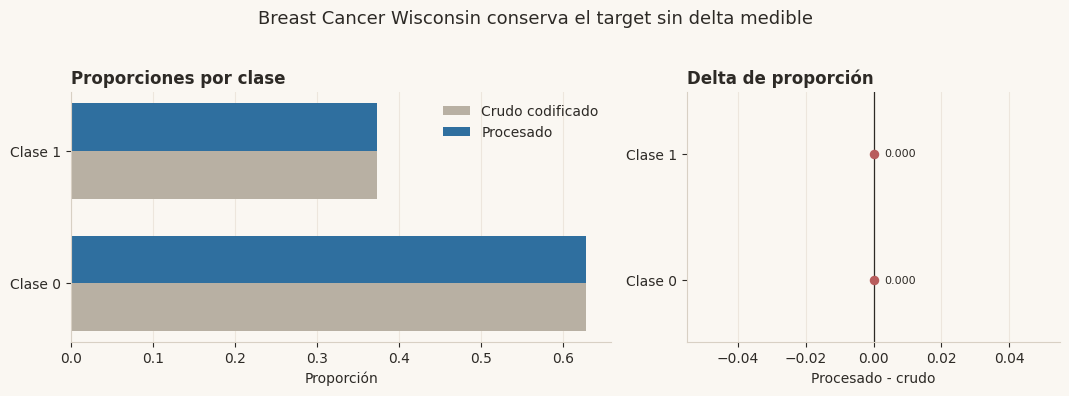

In [39]:
target_distribution_breast_cancer_wisconsin = resumir_distribucion_target("breast_cancer_wisconsin")
target_comparison_breast_cancer_wisconsin = comparar_target_raw_processed("breast_cancer_wisconsin")
target_tests_breast_cancer_wisconsin = pd.DataFrame([evaluar_tests_target("breast_cancer_wisconsin", target_comparison_breast_cancer_wisconsin)])

mostrar_tabla(target_comparison_breast_cancer_wisconsin, "Target crudo vs procesado - Breast Cancer Wisconsin", n=20)
mostrar_tabla(target_tests_breast_cancer_wisconsin, "Tests del target crudo vs procesado - Breast Cancer Wisconsin")
graficar_target_dataset(target_comparison_breast_cancer_wisconsin, "breast_cancer_wisconsin")


Lectura del target: el delta máximo entre crudo y procesado vale 0.000000; el ratio 1.68 mantiene un binario moderadamente desbalanceado.


### Target Post-Preprocesado: `customer_churn`


**Target crudo vs procesado - Customer Churn** - 2 filas, 9 columnas.

origen,Dataset,Código de clase,N crudo,N procesado,Diferencia de N,Proporción cruda,Proporción procesada,Diferencia de proporción,|diferencia de proporción|
0,customer_churn,0,190833.0,190833.0,0.0,0.432893,0.432893,0.0,0.0
1,customer_churn,1,249999.0,249999.0,0.0,0.567107,0.567107,0.0,0.0


**Tests del target crudo vs procesado - Customer Churn** - 1 filas, 13 columnas.

,Dataset,Estadístico chi2,Valor p chi2,Grados de libertad chi2,Odds ratio Fisher,Valor p Fisher,Máx. |diferencia de proporción|,Ratio mayoritaria/minoritaria crudo,Ratio mayoritaria/minoritaria procesado,Diferencia de ratio,Entropía cruda,Entropía procesada,Diferencia de entropía
0,customer_churn,0.0,1.0,1,1.0,1.0,0.0,1.310041,1.310041,0.0,0.986967,0.986967,0.0


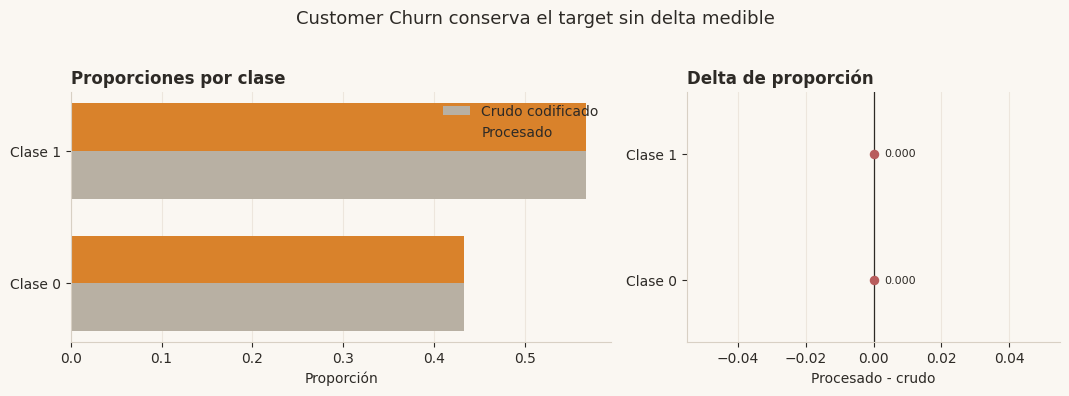

In [40]:
target_distribution_customer_churn = resumir_distribucion_target("customer_churn")
target_comparison_customer_churn = comparar_target_raw_processed("customer_churn")
target_tests_customer_churn = pd.DataFrame([evaluar_tests_target("customer_churn", target_comparison_customer_churn)])

mostrar_tabla(target_comparison_customer_churn, "Target crudo vs procesado - Customer Churn", n=20)
mostrar_tabla(target_tests_customer_churn, "Tests del target crudo vs procesado - Customer Churn")
graficar_target_dataset(target_comparison_customer_churn, "customer_churn")


Revisión del target: crudo codificado y procesado coinciden con diferencia máxima 0.000000; el ratio 1.31 pide estratificación posterior.


### Target Post-Preprocesado: `madelon`


**Target crudo vs procesado - Madelon** - 2 filas, 9 columnas.

origen,Dataset,Código de clase,N crudo,N procesado,Diferencia de N,Proporción cruda,Proporción procesada,Diferencia de proporción,|diferencia de proporción|
0,madelon,0,1000.0,1000.0,0.0,0.5,0.5,0.0,0.0
1,madelon,1,1000.0,1000.0,0.0,0.5,0.5,0.0,0.0


**Tests del target crudo vs procesado - Madelon** - 1 filas, 13 columnas.

,Dataset,Estadístico chi2,Valor p chi2,Grados de libertad chi2,Odds ratio Fisher,Valor p Fisher,Máx. |diferencia de proporción|,Ratio mayoritaria/minoritaria crudo,Ratio mayoritaria/minoritaria procesado,Diferencia de ratio,Entropía cruda,Entropía procesada,Diferencia de entropía
0,madelon,0.0,1.0,1,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0


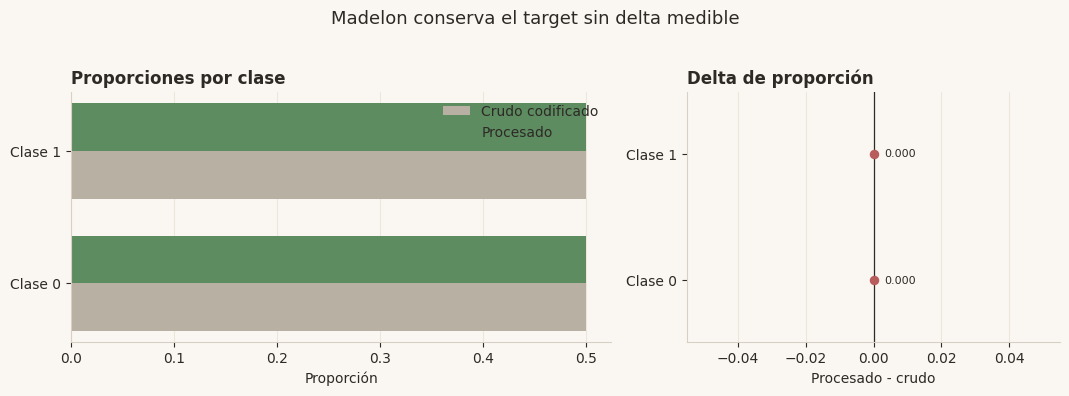

In [41]:
target_distribution_madelon = resumir_distribucion_target("madelon")
target_comparison_madelon = comparar_target_raw_processed("madelon")
target_tests_madelon = pd.DataFrame([evaluar_tests_target("madelon", target_comparison_madelon)])

mostrar_tabla(target_comparison_madelon, "Target crudo vs procesado - Madelon", n=20)
mostrar_tabla(target_tests_madelon, "Tests del target crudo vs procesado - Madelon")
graficar_target_dataset(target_comparison_madelon, "madelon")


Control del target: las dos clases quedan en proporción 0.50/0.50 y delta 0.000000; la dificultad procede de 500 features.


### Target Post-Preprocesado: `olive_oil`


**Target crudo vs procesado - Olive Oil** - 9 filas, 9 columnas.

origen,Dataset,Código de clase,N crudo,N procesado,Diferencia de N,Proporción cruda,Proporción procesada,Diferencia de proporción,|diferencia de proporción|
0,olive_oil,0,56.0,56.0,0.0,0.097902,0.097902,0.0,0.0
1,olive_oil,1,33.0,33.0,0.0,0.057692,0.057692,0.0,0.0
2,olive_oil,2,50.0,50.0,0.0,0.087413,0.087413,0.0,0.0
3,olive_oil,3,65.0,65.0,0.0,0.113636,0.113636,0.0,0.0
4,olive_oil,4,25.0,25.0,0.0,0.043706,0.043706,0.0,0.0
5,olive_oil,5,36.0,36.0,0.0,0.062937,0.062937,0.0,0.0
6,olive_oil,6,206.0,206.0,0.0,0.360140,0.360140,0.0,0.0
7,olive_oil,7,51.0,51.0,0.0,0.089161,0.089161,0.0,0.0
8,olive_oil,8,50.0,50.0,0.0,0.087413,0.087413,0.0,0.0


**Tests del target crudo vs procesado - Olive Oil** - 1 filas, 13 columnas.

,Dataset,Estadístico chi2,Valor p chi2,Grados de libertad chi2,Odds ratio Fisher,Valor p Fisher,Máx. |diferencia de proporción|,Ratio mayoritaria/minoritaria crudo,Ratio mayoritaria/minoritaria procesado,Diferencia de ratio,Entropía cruda,Entropía procesada,Diferencia de entropía
0,olive_oil,0.0,1.0,8,NaN,NaN,0.0,8.24,8.24,0.0,2.826929,2.826929,0.0


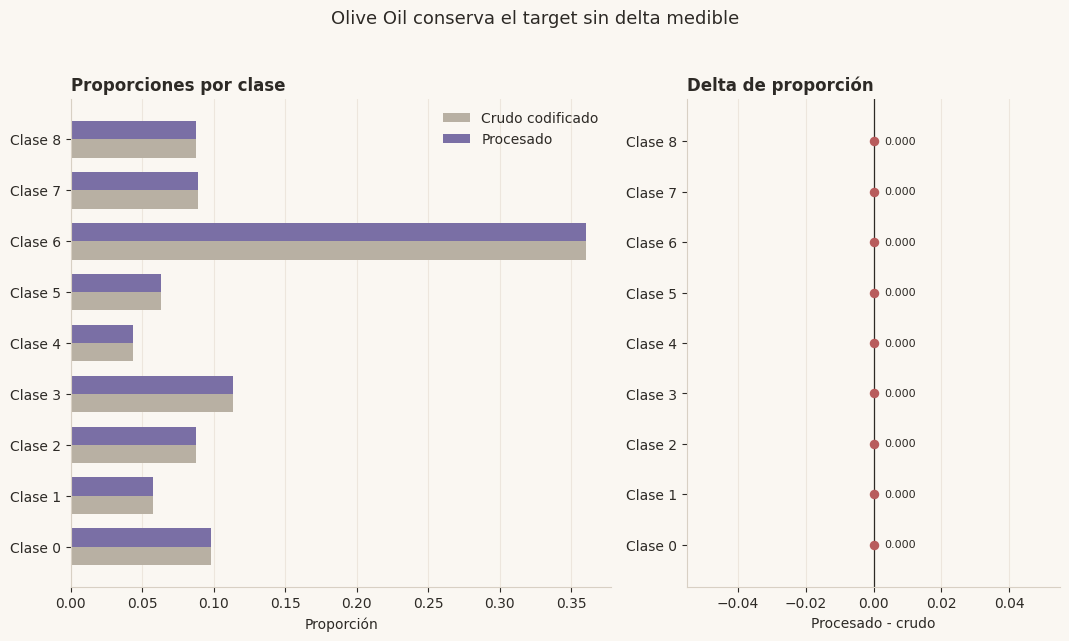

In [42]:
target_distribution_olive_oil = resumir_distribucion_target("olive_oil")
target_comparison_olive_oil = comparar_target_raw_processed("olive_oil")
target_tests_olive_oil = pd.DataFrame([evaluar_tests_target("olive_oil", target_comparison_olive_oil)])

mostrar_tabla(target_comparison_olive_oil, "Target crudo vs procesado - Olive Oil", n=20)
mostrar_tabla(target_tests_olive_oil, "Tests del target crudo vs procesado - Olive Oil")
graficar_target_dataset(target_comparison_olive_oil, "olive_oil")


Chequeo del target: las 9 clases conservan proporciones con delta 0.000000, pero el ratio 8.24 exige una partición estratificada.


### Resumen Comparativo del Target


In [43]:
target_distribution = pd.concat([
    target_distribution_breast_cancer_wisconsin,
    target_distribution_customer_churn,
    target_distribution_madelon,
    target_distribution_olive_oil,
], ignore_index=True)

target_comparison = pd.concat([
    target_comparison_breast_cancer_wisconsin,
    target_comparison_customer_churn,
    target_comparison_madelon,
    target_comparison_olive_oil,
], ignore_index=True)

target_tests = pd.concat([
    target_tests_breast_cancer_wisconsin,
    target_tests_customer_churn,
    target_tests_madelon,
    target_tests_olive_oil,
], ignore_index=True)

target_summary = target_comparison.groupby("dataset", as_index=False).agg(
    clases=("codigo", "nunique"),
    proporcion_minima=("proporcion_processed", "min"),
    proporcion_maxima=("proporcion_processed", "max"),
    max_delta_proporcion=("delta_proporcion_abs", "max"),
)
target_summary["ratio_mayoritaria_minoritaria"] = target_summary["proporcion_maxima"] / target_summary["proporcion_minima"]
target_summary = target_summary.merge(
    target_tests[["dataset", "chi2_p_value", "fisher_p_value", "delta_ratio_may_min", "delta_entropia"]],
    on="dataset",
    how="left",
)

guardar_tabla(target_distribution, "fase3_target_distribucion.csv")
guardar_tabla(target_comparison, "fase3_target_shift.csv")
guardar_tabla(target_tests, "fase3_target_tests.csv")
guardar_tabla(target_summary, "fase3_target_resumen.csv")
mostrar_tabla(target_summary, "Resumen estadístico del target")

def resumen_target_markdown(target_table):
    lines = ["**Lectura de resultados del target.**"]
    for _, row in target_table.iterrows():
        fisher_text = "no aplica por target multiclase" if pd.isna(row["fisher_p_value"]) else f"Fisher p={row['fisher_p_value']:.3f}"
        lines.append(
            f"- `{row['dataset']}`: max |delta proporción|={row['max_delta_proporcion']:.6f}, "
            f"ratio mayoritaria/minoritaria={row['ratio_mayoritaria_minoritaria']:.2f}, "
            f"chi2 p={row['chi2_p_value']:.3f}, {fisher_text}. "
            "El indicio importante es el delta nulo o casi nulo: el preprocesado no cambia la composición del problema."
        )
    lines.append(
        "Implicación: Fase 4 debe preservar estas proporciones con split estratificado; los p-valores solo respaldan la conservación, "
        "no sustituyen la lectura práctica del delta y del desbalance."
    )
    return "\n".join(lines)


display(Markdown(resumen_target_markdown(target_summary)))


**Resumen estadístico del target** - 4 filas, 10 columnas.

,Dataset,Clases,Proporción mínima,Proporción máxima,Máx. |diferencia de proporción|,Ratio mayoritaria/minoritaria,Valor p chi2,Valor p Fisher,Diferencia de ratio,Diferencia de entropía
0,breast_cancer_wisconsin,2,0.372583,0.627417,0.0,1.683962,1.0,1.0,0.0,0.0
1,customer_churn,2,0.432893,0.567107,0.0,1.310041,1.0,1.0,0.0,0.0
2,madelon,2,0.500000,0.500000,0.0,1.000000,1.0,1.0,0.0,0.0
3,olive_oil,9,0.043706,0.360140,0.0,8.240000,1.0,NaN,0.0,0.0


**Lectura de resultados del target.**
- `breast_cancer_wisconsin`: max |delta proporción|=0.000000, ratio mayoritaria/minoritaria=1.68, chi2 p=1.000, Fisher p=1.000. El indicio importante es el delta nulo o casi nulo: el preprocesado no cambia la composición del problema.
- `customer_churn`: max |delta proporción|=0.000000, ratio mayoritaria/minoritaria=1.31, chi2 p=1.000, Fisher p=1.000. El indicio importante es el delta nulo o casi nulo: el preprocesado no cambia la composición del problema.
- `madelon`: max |delta proporción|=0.000000, ratio mayoritaria/minoritaria=1.00, chi2 p=1.000, Fisher p=1.000. El indicio importante es el delta nulo o casi nulo: el preprocesado no cambia la composición del problema.
- `olive_oil`: max |delta proporción|=0.000000, ratio mayoritaria/minoritaria=8.24, chi2 p=1.000, no aplica por target multiclase. El indicio importante es el delta nulo o casi nulo: el preprocesado no cambia la composición del problema.
Implicación: Fase 4 debe preservar estas proporciones con split estratificado; los p-valores solo respaldan la conservación, no sustituyen la lectura práctica del delta y del desbalance.

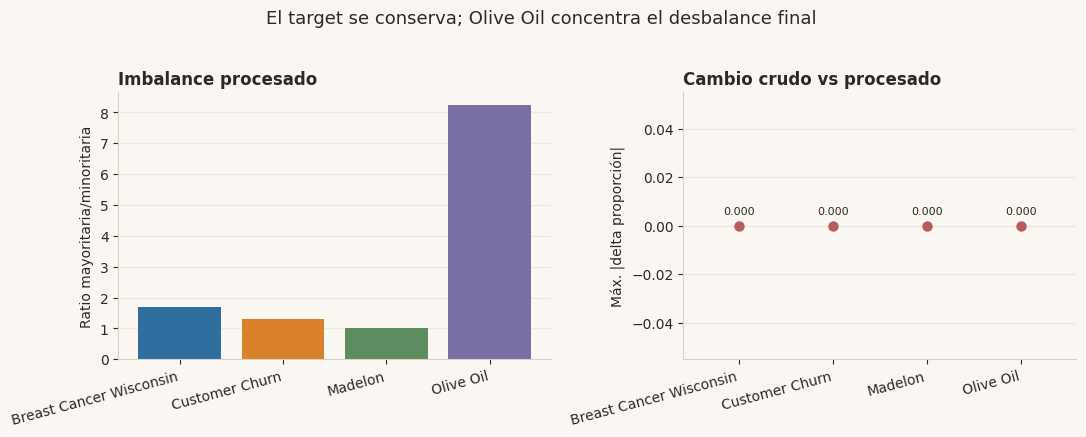

In [44]:
figura, ejes = plt.subplots(1, 2, figsize=(11.0, 4.2), width_ratios=[1.1, 1.0])
positions = np.arange(len(target_summary))
ejes[0].bar(positions, target_summary["ratio_mayoritaria_minoritaria"], color=[DATASET_COLORS[name] for name in target_summary["dataset"]])
ejes[0].set_xticks(positions)
ejes[0].set_xticklabels([etiqueta_dataset(name) for name in target_summary["dataset"]], rotation=15, ha="right")
ejes[0].set_ylabel("Ratio mayoritaria/minoritaria")
ejes[0].set_title("Imbalance procesado", loc="left", fontweight="bold")

ejes[1].bar(positions, target_summary["max_delta_proporcion"], color="#B85C5C")
ejes[1].scatter(positions, target_summary["max_delta_proporcion"], color="#B85C5C", s=42, zorder=3)
for position, delta in zip(positions, target_summary["max_delta_proporcion"]):
    ejes[1].annotate(f"{delta:.3f}", (position, delta), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
ejes[1].set_xticks(positions)
ejes[1].set_xticklabels([etiqueta_dataset(name) for name in target_summary["dataset"]], rotation=15, ha="right")
ejes[1].set_ylabel("Máx. |delta proporción|")
ejes[1].set_title("Cambio crudo vs procesado", loc="left", fontweight="bold")

for eje in ejes:
    aplicar_estilo_eje(eje, eje_rejilla="y")
fijar_titulo_narrativo(figura, "El target se conserva; Olive Oil concentra el desbalance final")
cerrar_figura_narrativa(figura, "fase3_target_desbalance.png")


Lectura de la figura comparativa: el máximo cambio de proporción es 0.000000 en los 4 datasets, mientras `olive_oil` alcanza el mayor desbalance con ratio 8.24. La figura separa conservación del target y dificultad de estratificación.


## 3.5 Comparación Distribucional de Variables Numéricas

Se comparan variables numéricas que pueden emparejarse entre raw y processed tras el renombrado. El objetivo es comprobar que el preprocesado estructural no ha introducido cambios inesperados de mediana o dispersión.

Las métricas miran el mismo fenómeno desde ángulos distintos:

- KS mide la máxima distancia entre distribuciones acumuladas. Es sensible a cambios globales de forma.
- Wasserstein mide cuánto habría que desplazar una distribución para parecerse a la otra. Es útil cuando la escala de la variable importa.
- PSI resume desplazamiento por bins; valores cercanos a cero indican estabilidad práctica entre raw y processed.
- JS divergence compara histogramas normalizados de forma simétrica y acotada.
- Spearman raw-processed evalúa si el orden relativo de las filas se conserva tras el preprocesado.

En `breast_cancer_wisconsin`, `madelon` y `olive_oil` se espera conservación casi exacta porque no se aplican transformaciones numéricas globales. En `customer_churn`, la lectura se restringe a numéricas comparables y deja las categóricas para el entrenamiento posterior al split.


In [45]:
def mapa_original_a_procesada(nombre_dataset):
    selected = renaming_phase2[renaming_phase2["dataset"].eq(nombre_dataset)]
    return dict(zip(selected["columna_original"], selected["columna_procesada"]))


def variables_comparables(nombre_dataset):
    rename_map = mapa_original_a_procesada(nombre_dataset)
    processed_columns = set(processed_datasets[nombre_dataset].columns)
    rows = []
    for raw_name, processed_name in rename_map.items():
        if processed_name in processed_columns and processed_name != PROCESSED_TARGET and raw_name != RAW_TARGETS[nombre_dataset]:
            rows.append((raw_name, processed_name))
    return rows


In [46]:
def calcular_iqr(serie):
    return serie.quantile(0.75) - serie.quantile(0.25)


def calcular_bordes_histograma(raw_values, processed_values, bins=10):
    quantile_edges = np.unique(np.quantile(raw_values, np.linspace(0, 1, bins + 1)))
    if len(quantile_edges) >= 3:
        return quantile_edges
    min_value = min(raw_values.min(), processed_values.min())
    max_value = max(raw_values.max(), processed_values.max())
    if min_value == max_value:
        return None
    return np.linspace(min_value, max_value, min(bins + 1, raw_values.nunique() + 1))


def normalizar_histograma(histogram):
    epsilon = 1e-8
    proportions = histogram / max(histogram.sum(), 1)
    proportions = np.clip(proportions, epsilon, None)
    return proportions / proportions.sum()


def calcular_histogramas_comparables(raw_values, processed_values, bins=10):
    raw_values = pd.Series(raw_values).dropna()
    processed_values = pd.Series(processed_values).dropna()
    if raw_values.empty or processed_values.empty:
        return None, None
    edges = calcular_bordes_histograma(raw_values, processed_values, bins)
    if edges is None:
        return None, None
    raw_hist, _ = np.histogram(raw_values, bins=edges)
    processed_hist, _ = np.histogram(processed_values, bins=edges)
    return normalizar_histograma(raw_hist), normalizar_histograma(processed_hist)


In [47]:
def calcular_psi(raw_values, processed_values):
    raw_prop, processed_prop = calcular_histogramas_comparables(raw_values, processed_values)
    if raw_prop is None:
        return np.nan
    return float(np.sum((processed_prop - raw_prop) * np.log(processed_prop / raw_prop)))


def calcular_js_divergence(raw_values, processed_values):
    raw_prop, processed_prop = calcular_histogramas_comparables(raw_values, processed_values)
    if raw_prop is None:
        return np.nan
    midpoint = 0.5 * (raw_prop + processed_prop)
    return float(0.5 * np.sum(raw_prop * np.log2(raw_prop / midpoint)) + 0.5 * np.sum(processed_prop * np.log2(processed_prop / midpoint)))


In [48]:
def calcular_spearman_pareado(raw_series, processed_series):
    paired = pd.DataFrame({"raw": pd.to_numeric(raw_series, errors="coerce"), "processed": pd.to_numeric(processed_series, errors="coerce")}).dropna()
    if len(paired) < 3 or paired["raw"].nunique() < 2 or paired["processed"].nunique() < 2:
        return np.nan
    return float(spearmanr(paired["raw"], paired["processed"]).statistic)


def convertir_a_numerica_limpia(serie):
    return pd.to_numeric(serie, errors="coerce").dropna()


def metricas_centro_dispersion(raw_values, processed_values):
    raw_iqr = calcular_iqr(raw_values)
    processed_iqr = calcular_iqr(processed_values)
    return {
        "mediana_raw": float(raw_values.median()),
        "mediana_processed": float(processed_values.median()),
        "delta_mediana_abs": float(abs(raw_values.median() - processed_values.median())),
        "iqr_raw": float(raw_iqr),
        "iqr_processed": float(processed_iqr),
        "delta_iqr_abs": float(abs(raw_iqr - processed_iqr)),
    }


def metricas_tests_distribucion(raw_values, processed_values):
    ks_result = ks_2samp(raw_values, processed_values)
    return {
        "ks_statistic": float(ks_result.statistic),
        "ks_p_value": float(ks_result.pvalue),
        "wasserstein_distance": float(wasserstein_distance(raw_values, processed_values)),
        "psi": calcular_psi(raw_values, processed_values),
        "js_divergence": calcular_js_divergence(raw_values, processed_values),
    }


def max_delta_percentiles(raw_values, processed_values):
    return float(max(abs(raw_values.quantile(q) - processed_values.quantile(q)) for q in [0, 0.25, 0.5, 0.75, 1.0]))


In [49]:
def crear_fila_shift_distribucional(nombre_dataset, raw_name, processed_name):
    raw_values = convertir_a_numerica_limpia(raw_datasets[nombre_dataset][raw_name])
    processed_values = convertir_a_numerica_limpia(processed_datasets[nombre_dataset][processed_name])
    return {
        "dataset": nombre_dataset,
        "variable": processed_name,
        **metricas_centro_dispersion(raw_values, processed_values),
        **metricas_tests_distribucion(raw_values, processed_values),
        "max_delta_percentil": max_delta_percentiles(raw_values, processed_values),
        "spearman_raw_processed": calcular_spearman_pareado(
            raw_datasets[nombre_dataset][raw_name],
            processed_datasets[nombre_dataset][processed_name],
        ),
    }


In [50]:
def crear_filas_percentiles(nombre_dataset, raw_name, processed_name):
    raw_values = pd.to_numeric(raw_datasets[nombre_dataset][raw_name], errors="coerce").dropna()
    processed_values = pd.to_numeric(processed_datasets[nombre_dataset][processed_name], errors="coerce").dropna()
    if raw_values.empty or processed_values.empty:
        return []
    return [{"dataset": nombre_dataset, "variable": processed_name, "percentil": q, "valor_raw": raw_values.quantile(q), "valor_processed": processed_values.quantile(q), "delta_abs": abs(raw_values.quantile(q) - processed_values.quantile(q))} for q in [0, 0.25, 0.5, 0.75, 1.0]]


def resumir_shift_distribucional(nombre_dataset):
    rows = []
    for raw_name, processed_name in variables_comparables(nombre_dataset):
        raw_series = raw_datasets[nombre_dataset][raw_name]
        processed_series = processed_datasets[nombre_dataset][processed_name]
        if pd.api.types.is_numeric_dtype(raw_series) and pd.api.types.is_numeric_dtype(processed_series):
            rows.append(crear_fila_shift_distribucional(nombre_dataset, raw_name, processed_name))
    return pd.DataFrame(rows)


def resumir_percentiles_comparables(nombre_dataset):
    rows = []
    for raw_name, processed_name in variables_comparables(nombre_dataset):
        rows.extend(crear_filas_percentiles(nombre_dataset, raw_name, processed_name))
    return pd.DataFrame(rows)


In [51]:
def limites_diagonal(tabla, columna_raw, columna_processed):
    minimo = min(tabla[columna_raw].min(), tabla[columna_processed].min())
    maximo = max(tabla[columna_raw].max(), tabla[columna_processed].max())
    return [minimo, maximo]


def dibujar_diagonal_conservacion(eje, tabla, columna_raw, columna_processed, color):
    eje.scatter(tabla[columna_raw], tabla[columna_processed], s=34, color=color, alpha=0.78)
    limites = limites_diagonal(tabla, columna_raw, columna_processed)
    eje.plot(limites, limites, color="#2D2A26", linewidth=1.0)


def titular_panel_conservacion(eje, xlabel, ylabel, titulo):
    eje.set_xlabel(xlabel)
    eje.set_ylabel(ylabel)
    eje.set_title(titulo, loc="left", fontweight="bold")
    aplicar_estilo_eje(eje, eje_rejilla="both")


In [52]:
def mensaje_distribucional(distribution_shift_dataset, nombre_dataset):
    score_maximo = distribution_shift_dataset["score_shift"].max()
    if score_maximo < 1e-12:
        return f"{etiqueta_dataset(nombre_dataset)} conserva mediana e IQR en variables comparables"
    return f"{etiqueta_dataset(nombre_dataset)} muestra desplazamiento distribucional a revisar"


def dibujar_top_shift_distribucional(eje, distribution_shift_dataset, nombre_dataset):
    top_shift = distribution_shift_dataset.sort_values("score_shift", ascending=False).head(8).sort_values("score_shift")
    bar_color = color_dataset(nombre_dataset)
    eje.barh(top_shift["variable"], top_shift["score_shift"], color=bar_color)
    eje.set_xlabel("KS + PSI + JS")
    eje.set_title("Variables con mayor shift", loc="left", fontweight="bold")
    aplicar_estilo_eje(eje, eje_rejilla="x")


def graficar_conservacion_distribucional_dataset(distribution_shift_dataset, nombre_dataset):
    if distribution_shift_dataset.empty:
        return
    figura, ejes = plt.subplots(1, 3, figsize=(13.4, 4.4), width_ratios=[1.0, 1.0, 1.2])
    color = color_dataset(nombre_dataset)
    dibujar_diagonal_conservacion(ejes[0], distribution_shift_dataset, "mediana_raw", "mediana_processed", color)
    dibujar_diagonal_conservacion(ejes[1], distribution_shift_dataset, "iqr_raw", "iqr_processed", color)
    dibujar_top_shift_distribucional(ejes[2], distribution_shift_dataset, nombre_dataset)
    titular_panel_conservacion(ejes[0], "Mediana raw", "Mediana processed", "Medianas")
    titular_panel_conservacion(ejes[1], "IQR raw", "IQR processed", "Dispersión")
    fijar_titulo_narrativo(figura, mensaje_distribucional(distribution_shift_dataset, nombre_dataset))
    cerrar_figura_narrativa(figura, f"fase3_distribucion_conservacion_{nombre_dataset}.png")


### Distribuciones Comparables: `breast_cancer_wisconsin`


**Tests de conservación distribucional - Breast Cancer Wisconsin** - 30 filas, 16 columnas.

,Dataset,Variable,Mediana cruda,Mediana procesada,|diferencia de mediana|,IQR crudo,IQR procesado,|diferencia de IQR|,Estadístico KS,Valor p KS,Distancia Wasserstein,PSI,Divergencia JS,Máx. |diferencia de percentil|,Spearman crudo/procesado,Score de desplazamiento
0,breast_cancer_wisconsin,radius_mean,13.37000,13.37000,0.0,4.08000,4.08000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,breast_cancer_wisconsin,texture_mean,18.84000,18.84000,0.0,5.63000,5.63000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,breast_cancer_wisconsin,perimeter_mean,86.24000,86.24000,0.0,28.93000,28.93000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,breast_cancer_wisconsin,area_mean,551.10000,551.10000,0.0,362.40000,362.40000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,breast_cancer_wisconsin,smoothness_mean,0.09587,0.09587,0.0,0.01893,0.01893,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5,breast_cancer_wisconsin,compactness_mean,0.09263,0.09263,0.0,0.06548,0.06548,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6,breast_cancer_wisconsin,concavity_mean,0.06154,0.06154,0.0,0.10114,0.10114,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7,breast_cancer_wisconsin,concave_points_mean,0.03350,0.03350,0.0,0.05369,0.05369,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
8,breast_cancer_wisconsin,symmetry_mean,0.17920,0.17920,0.0,0.03380,0.03380,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9,breast_cancer_wisconsin,fractal_dimension_mean,0.06154,0.06154,0.0,0.00842,0.00842,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


**Percentiles crudos vs procesados - Breast Cancer Wisconsin** - 150 filas, 6 columnas.

,Dataset,Variable,Percentil,Valor raw,Valor processed,|diferencia|
0,breast_cancer_wisconsin,radius_mean,0.00,6.981,6.981,0.0
1,breast_cancer_wisconsin,radius_mean,0.25,11.700,11.700,0.0
2,breast_cancer_wisconsin,radius_mean,0.50,13.370,13.370,0.0
3,breast_cancer_wisconsin,radius_mean,0.75,15.780,15.780,0.0
4,breast_cancer_wisconsin,radius_mean,1.00,28.110,28.110,0.0
5,breast_cancer_wisconsin,texture_mean,0.00,9.710,9.710,0.0
6,breast_cancer_wisconsin,texture_mean,0.25,16.170,16.170,0.0
7,breast_cancer_wisconsin,texture_mean,0.50,18.840,18.840,0.0
8,breast_cancer_wisconsin,texture_mean,0.75,21.800,21.800,0.0
9,breast_cancer_wisconsin,texture_mean,1.00,39.280,39.280,0.0


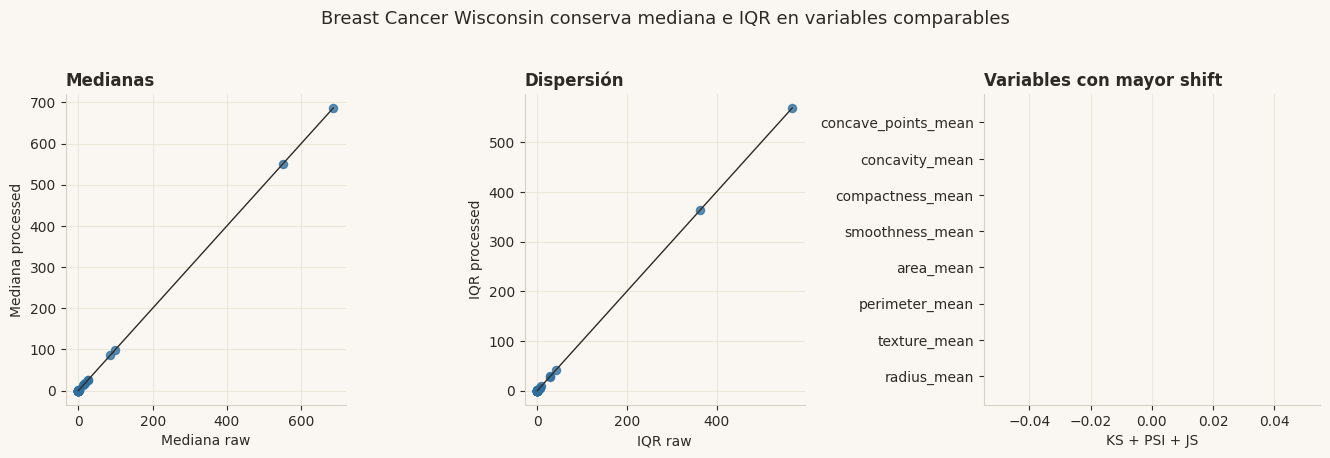

In [53]:
distribution_shift_breast_cancer_wisconsin = resumir_shift_distribucional("breast_cancer_wisconsin")
if not distribution_shift_breast_cancer_wisconsin.empty:
    distribution_shift_breast_cancer_wisconsin["score_shift"] = (
        distribution_shift_breast_cancer_wisconsin["ks_statistic"].fillna(0)
        + distribution_shift_breast_cancer_wisconsin["psi"].fillna(0)
        + distribution_shift_breast_cancer_wisconsin["js_divergence"].fillna(0)
    )
percentiles_breast_cancer_wisconsin = resumir_percentiles_comparables("breast_cancer_wisconsin")

mostrar_tabla(distribution_shift_breast_cancer_wisconsin.sort_values("score_shift", ascending=False), "Tests de conservación distribucional - Breast Cancer Wisconsin", n=12)
mostrar_tabla(percentiles_breast_cancer_wisconsin, "Percentiles crudos vs procesados - Breast Cancer Wisconsin", n=12)
graficar_conservacion_distribucional_dataset(distribution_shift_breast_cancer_wisconsin, "breast_cancer_wisconsin")


Observación: en 30 variables comparables, KS llega a 0.000000, PSI queda en 0.000000 y Spearman mínimo=1.000000; mediana e IQR se conservan.


### Distribuciones Comparables: `customer_churn`


**Tests de conservación distribucional - Customer Churn** - 7 filas, 16 columnas.

,Dataset,Variable,Mediana cruda,Mediana procesada,|diferencia de mediana|,IQR crudo,IQR procesado,|diferencia de IQR|,Estadístico KS,Valor p KS,Distancia Wasserstein,PSI,Divergencia JS,Máx. |diferencia de percentil|,Spearman crudo/procesado,Score de desplazamiento
0,customer_churn,age,39.0,39.0,0.0,19.0,19.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,customer_churn,tenure,32.0,32.0,0.0,30.0,30.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,customer_churn,usage_frequency,16.0,16.0,0.0,14.0,14.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,customer_churn,support_calls,3.0,3.0,0.0,5.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,customer_churn,payment_delay,12.0,12.0,0.0,13.0,13.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5,customer_churn,total_spend,661.0,661.0,0.0,350.0,350.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6,customer_churn,last_interaction,14.0,14.0,0.0,15.0,15.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


**Percentiles crudos vs procesados - Customer Churn** - 35 filas, 6 columnas.

,Dataset,Variable,Percentil,Valor raw,Valor processed,|diferencia|
0,customer_churn,age,0.00,18.0,18.0,0.0
1,customer_churn,age,0.25,29.0,29.0,0.0
2,customer_churn,age,0.50,39.0,39.0,0.0
3,customer_churn,age,0.75,48.0,48.0,0.0
4,customer_churn,age,1.00,65.0,65.0,0.0
5,customer_churn,tenure,0.00,1.0,1.0,0.0
6,customer_churn,tenure,0.25,16.0,16.0,0.0
7,customer_churn,tenure,0.50,32.0,32.0,0.0
8,customer_churn,tenure,0.75,46.0,46.0,0.0
9,customer_churn,tenure,1.00,60.0,60.0,0.0


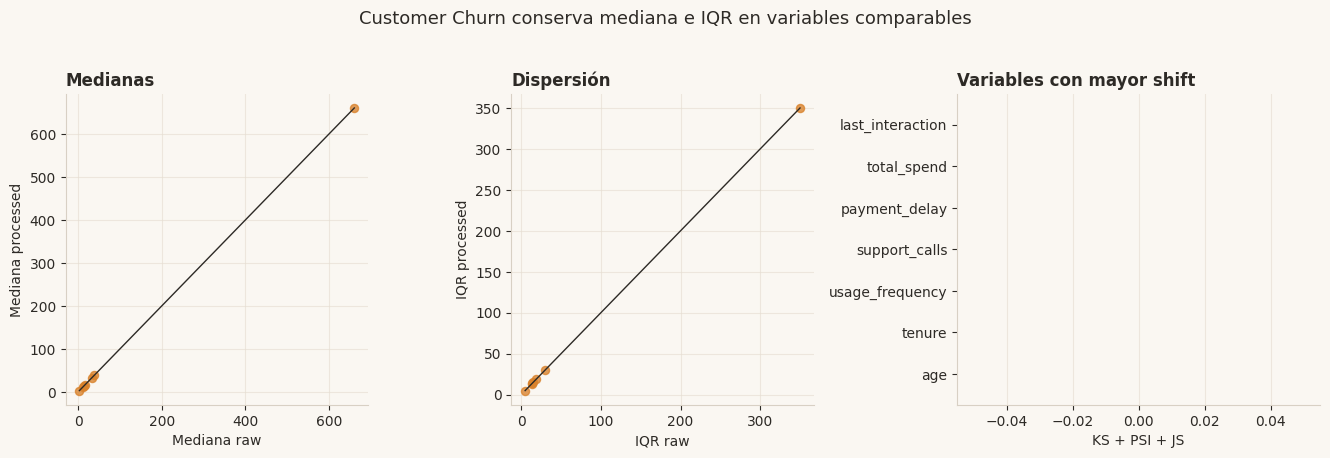

In [54]:
distribution_shift_customer_churn = resumir_shift_distribucional("customer_churn")
if not distribution_shift_customer_churn.empty:
    distribution_shift_customer_churn["score_shift"] = (
        distribution_shift_customer_churn["ks_statistic"].fillna(0)
        + distribution_shift_customer_churn["psi"].fillna(0)
        + distribution_shift_customer_churn["js_divergence"].fillna(0)
    )
percentiles_customer_churn = resumir_percentiles_comparables("customer_churn")

mostrar_tabla(distribution_shift_customer_churn.sort_values("score_shift", ascending=False), "Tests de conservación distribucional - Customer Churn", n=12)
mostrar_tabla(percentiles_customer_churn, "Percentiles crudos vs procesados - Customer Churn", n=12)
graficar_conservacion_distribucional_dataset(distribution_shift_customer_churn, "customer_churn")


Observación: las 7 numéricas comparables dan KS=0.000000 y PSI=0.000000; las 3 categóricas se revisan aparte.


### Distribuciones Comparables: `madelon`


**Tests de conservación distribucional - Madelon** - 500 filas, 16 columnas.

,Dataset,Variable,Mediana cruda,Mediana procesada,|diferencia de mediana|,IQR crudo,IQR procesado,|diferencia de IQR|,Estadístico KS,Valor p KS,Distancia Wasserstein,PSI,Divergencia JS,Máx. |diferencia de percentil|,Spearman crudo/procesado,Score de desplazamiento
499,madelon,feat_499,490.0,490.0,0.0,34.25,34.25,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
0,madelon,feat_0,482.0,482.0,0.0,9.00,9.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,madelon,feat_1,483.0,483.0,0.0,39.00,39.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,madelon,feat_2,510.5,510.5,0.0,51.00,51.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
483,madelon,feat_483,497.0,497.0,0.0,46.00,46.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
482,madelon,feat_482,478.0,478.0,0.0,13.00,13.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
481,madelon,feat_481,478.0,478.0,0.0,37.00,37.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
480,madelon,feat_480,486.0,486.0,0.0,27.00,27.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
479,madelon,feat_479,487.0,487.0,0.0,16.00,16.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
478,madelon,feat_478,483.0,483.0,0.0,51.00,51.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


**Percentiles crudos vs procesados - Madelon** - 2500 filas, 6 columnas.

,Dataset,Variable,Percentil,Valor raw,Valor processed,|diferencia|
0,madelon,feat_0,0.00,462.0,462.0,0.0
1,madelon,feat_0,0.25,477.0,477.0,0.0
2,madelon,feat_0,0.50,482.0,482.0,0.0
3,madelon,feat_0,0.75,486.0,486.0,0.0
4,madelon,feat_0,1.00,503.0,503.0,0.0
5,madelon,feat_1,0.00,381.0,381.0,0.0
6,madelon,feat_1,0.25,464.0,464.0,0.0
7,madelon,feat_1,0.50,483.0,483.0,0.0
8,madelon,feat_1,0.75,503.0,503.0,0.0
9,madelon,feat_1,1.00,600.0,600.0,0.0


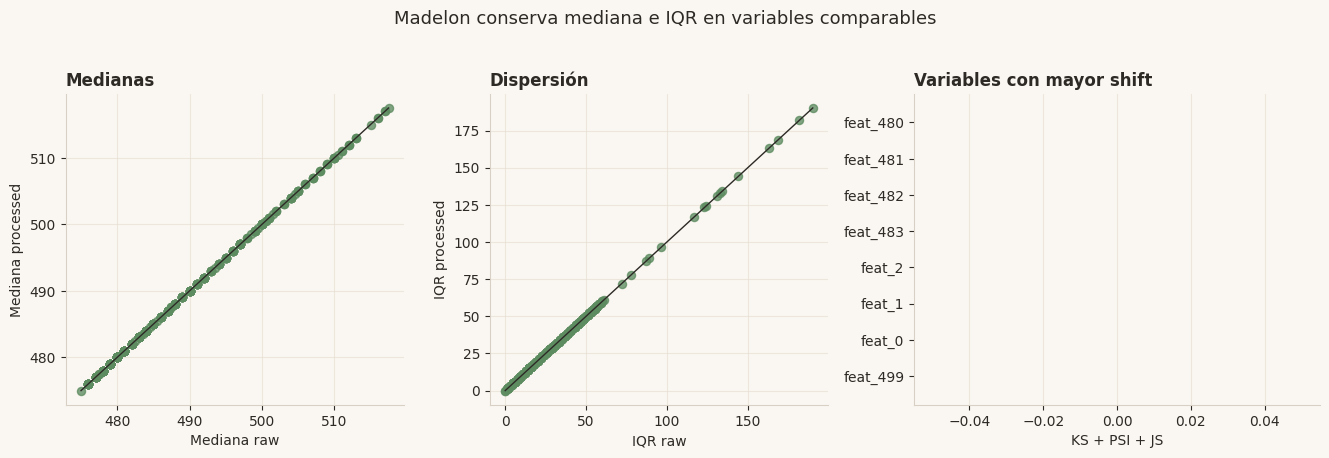

In [55]:
distribution_shift_madelon = resumir_shift_distribucional("madelon")
if not distribution_shift_madelon.empty:
    distribution_shift_madelon["score_shift"] = (
        distribution_shift_madelon["ks_statistic"].fillna(0)
        + distribution_shift_madelon["psi"].fillna(0)
        + distribution_shift_madelon["js_divergence"].fillna(0)
    )
percentiles_madelon = resumir_percentiles_comparables("madelon")

mostrar_tabla(distribution_shift_madelon.sort_values("score_shift", ascending=False), "Tests de conservación distribucional - Madelon", n=12)
mostrar_tabla(percentiles_madelon, "Percentiles crudos vs procesados - Madelon", n=12)
graficar_conservacion_distribucional_dataset(distribution_shift_madelon, "madelon")


Observación: sus 500 variables mantienen KS máximo en 0.000000, PSI en 0.000000 y Spearman mínimo=1.000000; no aparece transformación global.


### Distribuciones Comparables: `olive_oil`


**Tests de conservación distribucional - Olive Oil** - 10 filas, 16 columnas.

,Dataset,Variable,Mediana cruda,Mediana procesada,|diferencia de mediana|,IQR crudo,IQR procesado,|diferencia de IQR|,Estadístico KS,Valor p KS,Distancia Wasserstein,PSI,Divergencia JS,Máx. |diferencia de percentil|,Spearman crudo/procesado,Score de desplazamiento
0,olive_oil,area,1.0,1.0,0.0,2.00,2.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,olive_oil,palmitic,3.0,3.0,0.0,4.00,4.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,olive_oil,palmitoleic,1201.0,1201.0,0.0,265.00,265.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,olive_oil,stearic,110.0,110.0,0.0,81.50,81.50,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,olive_oil,oleic,223.0,223.0,0.0,44.00,44.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5,olive_oil,linoleic,7302.5,7302.5,0.0,680.00,680.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6,olive_oil,linolenic,1030.0,1030.0,0.0,410.00,410.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7,olive_oil,arachidic,33.0,33.0,0.0,14.25,14.25,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
8,olive_oil,eicosenoic,61.0,61.0,0.0,20.00,20.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9,olive_oil,other,17.0,17.0,0.0,26.00,26.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


**Percentiles crudos vs procesados - Olive Oil** - 50 filas, 6 columnas.

,Dataset,Variable,Percentil,Valor raw,Valor processed,|diferencia|
0,olive_oil,area,0.00,1.0,1.0,0.0
1,olive_oil,area,0.25,1.0,1.0,0.0
2,olive_oil,area,0.50,1.0,1.0,0.0
3,olive_oil,area,0.75,3.0,3.0,0.0
4,olive_oil,area,1.00,3.0,3.0,0.0
5,olive_oil,palmitic,0.00,1.0,1.0,0.0
6,olive_oil,palmitic,0.25,3.0,3.0,0.0
7,olive_oil,palmitic,0.50,3.0,3.0,0.0
8,olive_oil,palmitic,0.75,7.0,7.0,0.0
9,olive_oil,palmitic,1.00,9.0,9.0,0.0


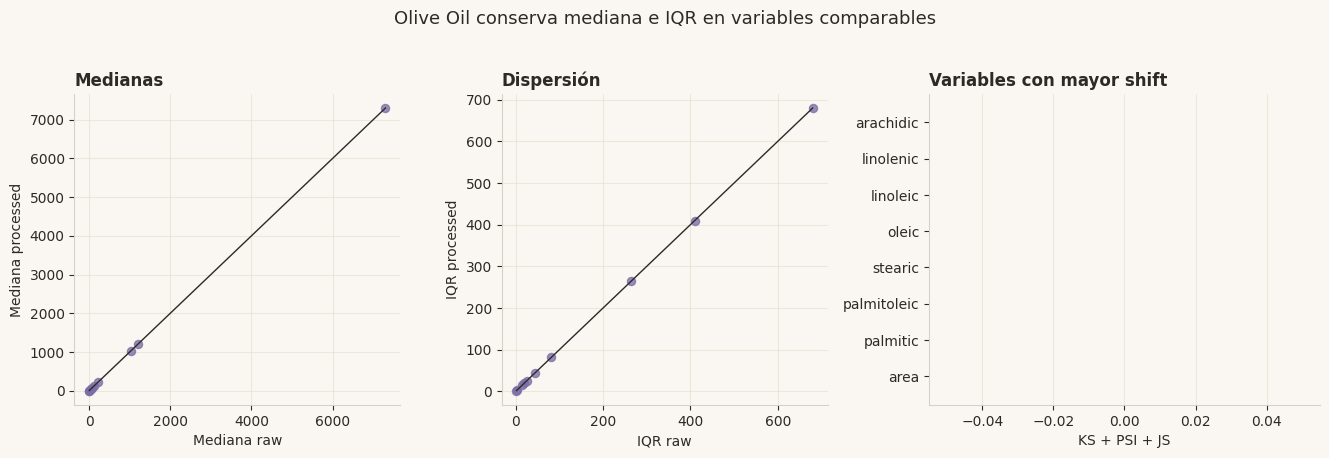

In [56]:
distribution_shift_olive_oil = resumir_shift_distribucional("olive_oil")
if not distribution_shift_olive_oil.empty:
    distribution_shift_olive_oil["score_shift"] = (
        distribution_shift_olive_oil["ks_statistic"].fillna(0)
        + distribution_shift_olive_oil["psi"].fillna(0)
        + distribution_shift_olive_oil["js_divergence"].fillna(0)
    )
percentiles_olive_oil = resumir_percentiles_comparables("olive_oil")

mostrar_tabla(distribution_shift_olive_oil.sort_values("score_shift", ascending=False), "Tests de conservación distribucional - Olive Oil", n=12)
mostrar_tabla(percentiles_olive_oil, "Percentiles crudos vs procesados - Olive Oil", n=12)
graficar_conservacion_distribucional_dataset(distribution_shift_olive_oil, "olive_oil")


Observación: las 10 variables composicionales muestran KS=0.000000 y Wasserstein=0.000000; no hay escalado ni winsorización global.


### Resumen Comparativo de Distribuciones


In [57]:
distribution_shift = pd.concat([
    distribution_shift_breast_cancer_wisconsin,
    distribution_shift_customer_churn,
    distribution_shift_madelon,
    distribution_shift_olive_oil,
], ignore_index=True)

distribution_shift["score_shift"] = (
    distribution_shift["ks_statistic"].fillna(0)
    + distribution_shift["psi"].fillna(0)
    + distribution_shift["js_divergence"].fillna(0)
)

percentiles_comparables = pd.concat([
    percentiles_breast_cancer_wisconsin,
    percentiles_customer_churn,
    percentiles_madelon,
    percentiles_olive_oil,
], ignore_index=True)

guardar_tabla(distribution_shift, "fase3_shift_distribucional.csv")
guardar_tabla(percentiles_comparables, "fase3_percentiles_comparables.csv")
distribution_tests_summary = distribution_shift.groupby("dataset", as_index=False).agg(
    variables=("variable", "count"),
    ks_maximo=("ks_statistic", "max"),
    wasserstein_maximo=("wasserstein_distance", "max"),
    psi_maximo=("psi", "max"),
    js_maximo=("js_divergence", "max"),
    max_delta_percentil=("max_delta_percentil", "max"),
    spearman_minimo=("spearman_raw_processed", "min"),
    score_shift_maximo=("score_shift", "max"),
)
guardar_tabla(distribution_tests_summary, "fase3_shift_distribucional_resumen.csv")
mostrar_tabla(distribution_tests_summary, "Resumen de tests distribucionales")

def resumen_distribucional_markdown(distribution_summary):
    lines = ["**Lectura de resultados distribucionales.**"]
    for _, row in distribution_summary.iterrows():
        lines.append(
            f"- `{row['dataset']}`: KS máximo={row['ks_maximo']:.6f}, "
            f"Wasserstein máximo={row['wasserstein_maximo']:.6f}, PSI máximo={row['psi_maximo']:.6f}, "
            f"Spearman pareado mínimo={row['spearman_minimo']:.6f}. "
            "La combinación de valores nulos o mínimos indica conservación de variables comparables tras renombrado/codificación estructural."
        )
    lines.append(
        "Implicación: si en Fase 4 aparece drift entre splits, deberá atribuirse al particionado o al tamaño muestral, "
        "no a una transformación numérica global introducida en Fase 2/3."
    )
    return "\n".join(lines)


display(Markdown(resumen_distribucional_markdown(distribution_tests_summary)))


**Resumen de tests distribucionales** - 4 filas, 9 columnas.

,Dataset,Variables,KS máximo,Wasserstein máximo,PSI máximo,JS máximo,Máx. |diferencia de percentil|,Spearman mínimo,Score máximo de desplazamiento
0,breast_cancer_wisconsin,30,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,customer_churn,7,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,madelon,500,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,olive_oil,10,0.0,0.0,0.0,0.0,0.0,1.0,0.0


**Lectura de resultados distribucionales.**
- `breast_cancer_wisconsin`: KS máximo=0.000000, Wasserstein máximo=0.000000, PSI máximo=0.000000, Spearman pareado mínimo=1.000000. La combinación de valores nulos o mínimos indica conservación de variables comparables tras renombrado/codificación estructural.
- `customer_churn`: KS máximo=0.000000, Wasserstein máximo=0.000000, PSI máximo=0.000000, Spearman pareado mínimo=1.000000. La combinación de valores nulos o mínimos indica conservación de variables comparables tras renombrado/codificación estructural.
- `madelon`: KS máximo=0.000000, Wasserstein máximo=0.000000, PSI máximo=0.000000, Spearman pareado mínimo=1.000000. La combinación de valores nulos o mínimos indica conservación de variables comparables tras renombrado/codificación estructural.
- `olive_oil`: KS máximo=0.000000, Wasserstein máximo=0.000000, PSI máximo=0.000000, Spearman pareado mínimo=1.000000. La combinación de valores nulos o mínimos indica conservación de variables comparables tras renombrado/codificación estructural.
Implicación: si en Fase 4 aparece drift entre splits, deberá atribuirse al particionado o al tamaño muestral, no a una transformación numérica global introducida en Fase 2/3.

## 3.6 Encoding Pendiente, Rangos y Escalado Posterior

Se revisan variables categóricas pendientes y rangos numéricos finales. Esta fase no ajusta encoders ni escaladores: solo comprueba qué deberá manejar el entrenamiento posterior al split.

El encoding pendiente se trata como una condición heredable, no como una incidencia del dataset procesado: `customer_churn` conserva categóricas para que el encoder se ajuste con entrenamiento y se aplique después a validación/prueba. El resto de datasets queda numérico.

Los rangos se leen con el criterio de heterogeneidad de escala para modelos sensibles a magnitud. No implican escalado global aquí; el escalado, si se necesita, debe formar parte del entrenamiento posterior al split.


In [58]:
def crear_fila_rango_processed(nombre_dataset, serie):
    return {
        "dataset": nombre_dataset,
        "variable": serie.name,
        "minimo": float(serie.min()),
        "maximo": float(serie.max()),
        "rango": float(serie.max() - serie.min()),
        "mediana": float(serie.median()),
        "iqr": float(calcular_iqr(serie)),
    }


def resumir_rangos_processed(nombre_dataset, datos_processed):
    rows = []
    for variable_name in datos_processed.columns:
        if variable_name != PROCESSED_TARGET and pd.api.types.is_numeric_dtype(datos_processed[variable_name]):
            rows.append(crear_fila_rango_processed(nombre_dataset, datos_processed[variable_name]))
    return pd.DataFrame(rows)


### Encoding y Rangos Finales: `breast_cancer_wisconsin`


In [59]:
ranges_processed_breast_cancer_wisconsin = resumir_rangos_processed("breast_cancer_wisconsin", processed_breast_cancer_wisconsin)

mostrar_estado_categoricas_pendientes(pending_categories_breast_cancer_wisconsin, "breast_cancer_wisconsin")
mostrar_tabla(ranges_processed_breast_cancer_wisconsin.sort_values("rango", ascending=False), "Rangos procesados - Breast Cancer Wisconsin", n=12)


`breast_cancer_wisconsin` no mantiene predictoras categóricas pendientes.

**Rangos procesados - Breast Cancer Wisconsin** - 30 filas, 7 columnas.

,Dataset,Variable,Mínimo,Máximo,Rango,Mediana,IQR
23,breast_cancer_wisconsin,area_worst,185.2000,4254.000,4068.8000,686.5000,568.7000
3,breast_cancer_wisconsin,area_mean,143.5000,2501.000,2357.5000,551.1000,362.4000
13,breast_cancer_wisconsin,area_se,6.8020,542.200,535.3980,24.5300,27.3400
22,breast_cancer_wisconsin,perimeter_worst,50.4100,251.200,200.7900,97.6600,41.2900
2,breast_cancer_wisconsin,perimeter_mean,43.7900,188.500,144.7100,86.2400,28.9300
21,breast_cancer_wisconsin,texture_worst,12.0200,49.540,37.5200,25.4100,8.6400
1,breast_cancer_wisconsin,texture_mean,9.7100,39.280,29.5700,18.8400,5.6300
20,breast_cancer_wisconsin,radius_worst,7.9300,36.040,28.1100,14.9700,5.7800
12,breast_cancer_wisconsin,perimeter_se,0.7570,21.980,21.2230,2.2870,1.7510
0,breast_cancer_wisconsin,radius_mean,6.9810,28.110,21.1290,13.3700,4.0800


Observación: mantiene 30 variables numéricas y 0 categóricas; los rangos heterogéneos deberán escalarse solo dentro del entrenamiento.


### Encoding y Rangos Finales: `customer_churn`


In [60]:
ranges_processed_customer_churn = resumir_rangos_processed("customer_churn", processed_customer_churn)

mostrar_estado_categoricas_pendientes(pending_categories_customer_churn, "customer_churn")
mostrar_tabla(ranges_processed_customer_churn.sort_values("rango", ascending=False), "Rangos procesados - Customer Churn", n=12)


`customer_churn` mantiene 3 predictoras categóricas pendientes (cardinalidad máxima: 3). Se conservan sin codificar hasta el split para que el encoder se ajuste solo con entrenamiento. Variables visibles: `gender`, `subscription_type`, `contract_length`.

**Rangos procesados - Customer Churn** - 7 filas, 7 columnas.

,Dataset,Variable,Mínimo,Máximo,Rango,Mediana,IQR
5,customer_churn,total_spend,100.0,1000.0,900.0,661.0,350.0
1,customer_churn,tenure,1.0,60.0,59.0,32.0,30.0
0,customer_churn,age,18.0,65.0,47.0,39.0,19.0
4,customer_churn,payment_delay,0.0,30.0,30.0,12.0,13.0
2,customer_churn,usage_frequency,1.0,30.0,29.0,16.0,14.0
6,customer_churn,last_interaction,1.0,30.0,29.0,14.0,15.0
3,customer_churn,support_calls,0.0,10.0,10.0,3.0,5.0


Observación: combina 7 numéricas y 3 categóricas pendientes; la siguiente fase necesita tratamiento mixto sin fuga de información.


### Encoding y Rangos Finales: `madelon`


In [61]:
ranges_processed_madelon = resumir_rangos_processed("madelon", processed_madelon)

mostrar_estado_categoricas_pendientes(pending_categories_madelon, "madelon")
mostrar_tabla(ranges_processed_madelon.sort_values("rango", ascending=False), "Rangos procesados - Madelon", n=12)


`madelon` no mantiene predictoras categóricas pendientes.

**Rangos procesados - Madelon** - 500 filas, 7 columnas.

,Dataset,Variable,Mínimo,Máximo,Rango,Mediana,IQR
105,madelon,feat_105,0.0,999.0,999.0,499.0,190.25
493,madelon,feat_493,130.0,920.0,790.0,504.0,182.00
453,madelon,feat_453,84.0,807.0,723.0,487.5,163.25
336,madelon,feat_336,180.0,828.0,648.0,483.5,144.25
153,madelon,feat_153,182.0,814.0,632.0,501.5,169.00
338,madelon,feat_338,207.0,829.0,622.0,496.0,134.25
442,madelon,feat_442,207.0,794.0,587.0,494.0,133.00
64,madelon,feat_64,214.0,768.0,554.0,500.5,124.00
455,madelon,feat_455,265.0,735.0,470.0,504.5,131.00
433,madelon,feat_433,263.0,719.0,456.0,499.5,117.00


Observación: sus 500 variables son numéricas; la prioridad posterior será controlar dimensionalidad y validación, no codificación.


### Encoding y Rangos Finales: `olive_oil`


In [62]:
ranges_processed_olive_oil = resumir_rangos_processed("olive_oil", processed_olive_oil)

mostrar_estado_categoricas_pendientes(pending_categories_olive_oil, "olive_oil")
mostrar_tabla(ranges_processed_olive_oil.sort_values("rango", ascending=False), "Rangos procesados - Olive Oil", n=12)


`olive_oil` no mantiene predictoras categóricas pendientes.

**Rangos procesados - Olive Oil** - 10 filas, 7 columnas.

,Dataset,Variable,Mínimo,Máximo,Rango,Mediana,IQR
5,olive_oil,linoleic,6300.0,8410.0,2110.0,7302.5,680.00
2,olive_oil,palmitoleic,610.0,1753.0,1143.0,1201.0,265.00
6,olive_oil,linolenic,448.0,1470.0,1022.0,1030.0,410.00
3,olive_oil,stearic,15.0,280.0,265.0,110.0,81.50
4,olive_oil,oleic,152.0,375.0,223.0,223.0,44.00
8,olive_oil,eicosenoic,0.0,105.0,105.0,61.0,20.00
7,olive_oil,arachidic,0.0,74.0,74.0,33.0,14.25
9,olive_oil,other,1.0,58.0,57.0,17.0,26.00
1,olive_oil,palmitic,1.0,9.0,8.0,3.0,4.00
0,olive_oil,area,1.0,3.0,2.0,1.0,2.00


Observación: queda con 10 variables numéricas y 9 clases; la estratificación y el escalado posterior importan más que nuevos encoders.


### Resumen Comparativo de Encoding y Rangos


In [63]:
ranges_processed = pd.concat([
    ranges_processed_breast_cancer_wisconsin,
    ranges_processed_customer_churn,
    ranges_processed_madelon,
    ranges_processed_olive_oil,
], ignore_index=True)

encoding_summary = encoding_dimensionality_phase2.copy()

def resumen_encoding_pendiente_markdown(encoding_table):
    lines = ["**Encoding pendiente heredado de Fase 2.**"]
    for _, row in encoding_table.iterrows():
        dataset_label = etiqueta_dataset(row["dataset"])
        categorical = int(row["predictoras_categoricas"])
        if categorical == 0:
            lines.append(f"- `{row['dataset']}`: no mantiene predictoras categóricas pendientes; no hay encoder que ajustar para variables categóricas.")
        else:
            lines.append(
                f"- `{row['dataset']}`: mantiene {categorical} predictoras categóricas. "
                f"Si se codificaran con one-hot, el espacio pasaría de {int(row['predictoras_sin_onehot'])} a {int(row['predictoras_si_onehot'])} predictoras. "
                "Esta cifra es una estimación para diseñar el entrenamiento posterior, no una transformación aplicada en Fase 3."
            )
    lines.append(
        "La tabla fuente sigue siendo `results/tables/02_preprocessing/fase2_dimensionalidad_encoding.csv`; "
        "Fase 3 no la duplica como resultado propio porque aquí no se ajusta ningún encoder."
    )
    return "\n".join(lines)


guardar_tabla(ranges_processed, "fase3_rangos_processed.csv")
display(Markdown(resumen_encoding_pendiente_markdown(encoding_summary)))

def resumen_rangos_markdown(ranges_table):
    summary = ranges_table.groupby("dataset", as_index=False).agg(
        rango_maximo=("rango", "max"),
        rango_mediano=("rango", "median"),
        iqr_mediano=("iqr", "median"),
        variables=("variable", "count"),
    )
    lines = ["**Lectura de rangos y escalado posterior.**"]
    for _, row in summary.iterrows():
        lines.append(
            f"- `{row['dataset']}`: {int(row['variables'])} numéricas, rango máximo={row['rango_maximo']:.3f}, "
            f"rango mediano={row['rango_mediano']:.3f}, IQR mediano={row['iqr_mediano']:.3f}. "
            "Estos rangos justifican escalar dentro del entrenamiento cuando el modelo sea sensible a magnitud."
        )
    lines.append("No se ajusta ningún escalador aquí para evitar fuga de información antes del split.")
    return "\n".join(lines)


display(Markdown(resumen_rangos_markdown(ranges_processed)))


**Encoding pendiente heredado de Fase 2.**
- `breast_cancer_wisconsin`: no mantiene predictoras categóricas pendientes; no hay encoder que ajustar para variables categóricas.
- `customer_churn`: mantiene 3 predictoras categóricas. Si se codificaran con one-hot, el espacio pasaría de 10 a 15 predictoras. Esta cifra es una estimación para diseñar el entrenamiento posterior, no una transformación aplicada en Fase 3.
- `madelon`: no mantiene predictoras categóricas pendientes; no hay encoder que ajustar para variables categóricas.
- `olive_oil`: no mantiene predictoras categóricas pendientes; no hay encoder que ajustar para variables categóricas.
La tabla fuente sigue siendo `results/tables/02_preprocessing/fase2_dimensionalidad_encoding.csv`; Fase 3 no la duplica como resultado propio porque aquí no se ajusta ningún encoder.

**Lectura de rangos y escalado posterior.**
- `breast_cancer_wisconsin`: 30 numéricas, rango máximo=4068.800, rango mediano=0.467, IQR mediano=0.099. Estos rangos justifican escalar dentro del entrenamiento cuando el modelo sea sensible a magnitud.
- `customer_churn`: 7 numéricas, rango máximo=900.000, rango mediano=30.000, IQR mediano=15.000. Estos rangos justifican escalar dentro del entrenamiento cuando el modelo sea sensible a magnitud.
- `madelon`: 500 numéricas, rango máximo=999.000, rango mediano=168.000, IQR mediano=31.000. Estos rangos justifican escalar dentro del entrenamiento cuando el modelo sea sensible a magnitud.
- `olive_oil`: 10 numéricas, rango máximo=2110.000, rango mediano=164.000, IQR mediano=35.000. Estos rangos justifican escalar dentro del entrenamiento cuando el modelo sea sensible a magnitud.
No se ajusta ningún escalador aquí para evitar fuga de información antes del split.

## 3.7 Conservación Exploratoria de Relación Variable-Target

Se calcula asociación exploratoria entre variables numéricas y target antes y después del preprocesado. Se usa Spearman absoluto y mutual information como diagnóstico de conservación de señal; no se seleccionan variables en esta fase.

Este bloque es la garantía previa para el término de relevancia que consumirá QFS: en `PAPER_QFS.pdf`, `I(x_i;y)` define pesos locales del Hamiltoniano, de modo que un preprocesado que cambiara artificialmente los rankings de mutual information alteraría los detunings locales antes de comparar contra métodos clásicos. Por eso se leen cambios de score, solapamiento top-k y correlación de rankings, no solo valores aislados.

Lectura de las métricas:

- Spearman absoluto mide relación monótona entre variable y target codificado. Es robusto a escalas distintas y ayuda a comparar raw codificado contra processed.
- El p-value de Spearman se ajusta con Benjamini-Hochberg para controlar FDR cuando se evalúan muchas variables simultáneamente. Un q-value bajo indica señal estadística exploratoria, no una decisión de selección.
- Mutual information detecta dependencia no necesariamente lineal entre predictor y target. Se combina con Spearman en un score descriptivo para ordenar variables.
- El cambio de ranking y el solapamiento top-k indican si el preprocesado ha reordenado artificialmente las variables con mayor señal.

En `customer_churn` solo entran las numéricas porque las categóricas siguen sin codificar. En `madelon`, la lectura se centra en estabilidad de señal bajo alta dimensionalidad. En `olive_oil`, el target multiclase permite medir dependencia, pero la selección queda fuera de esta fase.


In [64]:
def preparar_matriz_asociacion(datos_dataset, target_name):
    numeric_features = [name for name in datos_dataset.columns if name != target_name and pd.api.types.is_numeric_dtype(datos_dataset[name])]
    if not numeric_features:
        return pd.DataFrame(), pd.Series(dtype=int)
    sampled = datos_dataset[numeric_features + [target_name]].dropna()
    if len(sampled) > MAX_SAMPLE_ASSOCIATION:
        sampled = sampled.sample(MAX_SAMPLE_ASSOCIATION, random_state=RANDOM_STATE)
    predictors = sampled[numeric_features].replace([np.inf, -np.inf], np.nan)
    predictors = predictors.fillna(predictors.median(numeric_only=True))
    target = LabelEncoder().fit_transform(sampled[target_name].astype(str))
    return predictors, pd.Series(target, index=predictors.index)


In [65]:
def ajustar_fdr_bh(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full_like(p_values, np.nan, dtype=float)
    valid_mask = ~np.isnan(p_values)
    valid_p = p_values[valid_mask]
    if len(valid_p) == 0:
        return q_values
    order = np.argsort(valid_p)
    positions = np.arange(1, len(valid_p) + 1)
    adjusted = valid_p[order] * len(valid_p) / positions
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    valid_indices = np.where(valid_mask)[0]
    q_values[valid_indices[order]] = np.clip(adjusted, 0, 1)
    return q_values


def crear_fila_asociacion(nombre_dataset, variable_name, metricas_asociacion):
    spearman_value = metricas_asociacion["spearman"]
    spearman_clean = 0.0 if np.isnan(spearman_value) else float(abs(spearman_value))
    mi_clean = 0.0 if np.isnan(metricas_asociacion["mi"]) else float(metricas_asociacion["mi"])
    p_value = metricas_asociacion["p_value"]
    return {
        "dataset": nombre_dataset,
        "variable": variable_name,
        "spearman_abs": spearman_clean,
        "spearman_p_value": float(p_value) if pd.notna(p_value) else np.nan,
        "mutual_info": mi_clean,
        "score_asociacion": (spearman_clean + mi_clean) / 2,
        "n_usado": metricas_asociacion["n"],
    }


def columnas_asociacion_vacia():
    return [
        "dataset", "variable", "spearman_abs", "spearman_p_value",
        "spearman_q_value_bh", "fdr_significativo_005", "mutual_info",
        "score_asociacion", "ranking", "n_usado",
    ]


def calcular_spearman_con_target(predictors, target, variable_name):
    if predictors[variable_name].nunique(dropna=True) < 2:
        return np.nan, np.nan
    spearman_result = spearmanr(predictors[variable_name], target)
    return spearman_result.statistic, spearman_result.pvalue


def anotar_ranking_y_fdr(tabla_asociacion):
    tabla = tabla_asociacion.sort_values("score_asociacion", ascending=False).reset_index(drop=True)
    tabla["spearman_q_value_bh"] = ajustar_fdr_bh(tabla["spearman_p_value"])
    tabla["fdr_significativo_005"] = tabla["spearman_q_value_bh"] <= 0.05
    tabla["ranking"] = np.arange(1, len(tabla) + 1)
    return tabla


In [66]:
def calcular_asociacion_numerica(nombre_dataset, datos_dataset, target_name):
    predictors, target = preparar_matriz_asociacion(datos_dataset, target_name)
    if predictors.empty:
        return pd.DataFrame(columns=columnas_asociacion_vacia())
    rows = []
    mutual_information = mutual_info_classif(predictors, target, random_state=RANDOM_STATE)
    for variable_name, mi_score in zip(predictors.columns, mutual_information):
        spearman_value, p_value = calcular_spearman_con_target(predictors, target, variable_name)
        rows.append(crear_fila_asociacion(nombre_dataset, variable_name, {"spearman": spearman_value, "p_value": p_value, "mi": mi_score, "n": len(predictors)}))
    return anotar_ranking_y_fdr(pd.DataFrame(rows))


In [67]:
def crear_dataset_raw_codificado(nombre_dataset):
    raw_dataset = raw_datasets[nombre_dataset].rename(columns=mapa_original_a_procesada(nombre_dataset)).copy()
    raw_dataset[PROCESSED_TARGET] = codificar_target_raw(nombre_dataset)
    return raw_dataset


def resumir_shift_asociacion(nombre_dataset):
    raw_assoc = calcular_asociacion_numerica(nombre_dataset, crear_dataset_raw_codificado(nombre_dataset), PROCESSED_TARGET)
    processed_assoc = calcular_asociacion_numerica(nombre_dataset, processed_datasets[nombre_dataset], PROCESSED_TARGET)
    return raw_assoc, processed_assoc, combinar_asociaciones(raw_assoc, processed_assoc, nombre_dataset)


In [68]:
def columnas_shift_asociacion():
    return ["dataset", "variable", "score_raw", "score_processed", "delta_abs", "spearman_raw", "spearman_processed", "delta_spearman_abs", "mutual_info_raw", "mutual_info_processed", "delta_mi_abs", "ranking_raw", "ranking_processed", "delta_ranking"]


def leer_metricas_asociacion(mapa_asociacion, variable_name):
    return {
        "score": mapa_asociacion.loc[variable_name, "score_asociacion"],
        "spearman": mapa_asociacion.loc[variable_name, "spearman_abs"],
        "mi": mapa_asociacion.loc[variable_name, "mutual_info"],
        "ranking": int(mapa_asociacion.loc[variable_name, "ranking"]),
    }


def comparar_metricas_asociacion(raw_metrics, processed_metrics):
    return {
        "score_raw": raw_metrics["score"],
        "score_processed": processed_metrics["score"],
        "delta_abs": abs(processed_metrics["score"] - raw_metrics["score"]),
        "spearman_raw": raw_metrics["spearman"],
        "spearman_processed": processed_metrics["spearman"],
        "delta_spearman_abs": abs(processed_metrics["spearman"] - raw_metrics["spearman"]),
        "mutual_info_raw": raw_metrics["mi"],
        "mutual_info_processed": processed_metrics["mi"],
        "delta_mi_abs": abs(processed_metrics["mi"] - raw_metrics["mi"]),
        "ranking_raw": raw_metrics["ranking"],
        "ranking_processed": processed_metrics["ranking"],
        "delta_ranking": processed_metrics["ranking"] - raw_metrics["ranking"],
    }


In [69]:
def crear_fila_shift_asociacion(nombre_dataset, variable_name, mapas_asociacion):
    raw_metrics = leer_metricas_asociacion(mapas_asociacion["raw"], variable_name)
    processed_metrics = leer_metricas_asociacion(mapas_asociacion["processed"], variable_name)
    return {
        "dataset": nombre_dataset,
        "variable": variable_name,
        **comparar_metricas_asociacion(raw_metrics, processed_metrics),
    }


def combinar_asociaciones(raw_assoc, processed_assoc, nombre_dataset):
    raw_map = raw_assoc.set_index("variable")
    processed_map = processed_assoc.set_index("variable")
    common_variables = sorted(set(raw_map.index) & set(processed_map.index))
    rows = []
    mapas_asociacion = {"raw": raw_map, "processed": processed_map}
    for variable_name in common_variables:
        rows.append(crear_fila_shift_asociacion(nombre_dataset, variable_name, mapas_asociacion))
    return pd.DataFrame(rows, columns=columnas_shift_asociacion())


In [70]:
def fila_asociacion_sin_variables(nombre_dataset):
    return {
        "dataset": nombre_dataset,
        "variables_comunes": 0,
        "spearman_rankings_raw_processed": np.nan,
        "mi_spearman_raw_processed": np.nan,
        "delta_mi_medio": np.nan,
        "fdr_significativas_005": 0,
        "proporcion_fdr_significativas_005": np.nan,
        "efecto_post_maximo_spearman": np.nan,
        "efecto_post_mediano_spearman": np.nan,
        "top_k": 0,
        "top_k_overlap": 0,
        "top_k_overlap_ratio": np.nan,
    }


In [71]:
def calcular_overlap_top_k(raw_assoc, processed_assoc, association_shift_dataset, top_k):
    k = min(top_k, len(association_shift_dataset))
    raw_top = set(raw_assoc.sort_values("ranking").head(k)["variable"])
    processed_top = set(processed_assoc.sort_values("ranking").head(k)["variable"])
    return k, len(raw_top & processed_top)


def resumir_fdr_processed(processed_assoc):
    fdr_count = int(processed_assoc["fdr_significativo_005"].sum()) if "fdr_significativo_005" in processed_assoc else 0
    return fdr_count, fdr_count / max(len(processed_assoc), 1)


def resumir_efecto_processed(processed_assoc):
    if processed_assoc.empty:
        return np.nan, np.nan
    return float(processed_assoc["spearman_abs"].max()), float(processed_assoc["spearman_abs"].median())


In [72]:
def metricas_overlap_top_k(k, overlap):
    return {
        "top_k": k,
        "top_k_overlap": overlap,
        "top_k_overlap_ratio": overlap / max(k, 1),
    }


In [73]:
def metricas_rankings_asociacion(association_shift_dataset, ranking_corr, mi_corr):
    return {
        "spearman_rankings_raw_processed": float(ranking_corr) if pd.notna(ranking_corr) else np.nan,
        "mi_spearman_raw_processed": float(mi_corr) if pd.notna(mi_corr) else np.nan,
        "delta_mi_medio": float(association_shift_dataset["delta_mi_abs"].mean()),
    }


def metricas_fdr_y_efecto(fdr_metrics, effect_metrics):
    fdr_count, fdr_ratio = fdr_metrics
    efecto_maximo, efecto_mediano = effect_metrics
    return {
        "fdr_significativas_005": fdr_count,
        "proporcion_fdr_significativas_005": fdr_ratio,
        "efecto_post_maximo_spearman": efecto_maximo,
        "efecto_post_mediano_spearman": efecto_mediano,
    }


def crear_fila_conservacion_asociacion(nombre_dataset, association_shift_dataset, ranking_corr, mi_corr, top_metrics, fdr_metrics, effect_metrics):
    k, overlap = top_metrics
    return {
        "dataset": nombre_dataset,
        "variables_comunes": len(association_shift_dataset),
        **metricas_rankings_asociacion(association_shift_dataset, ranking_corr, mi_corr),
        **metricas_fdr_y_efecto(fdr_metrics, effect_metrics),
        **metricas_overlap_top_k(k, overlap),
    }


def evaluar_conservacion_asociacion(nombre_dataset, raw_assoc, processed_assoc, association_shift_dataset, top_k=10):
    if association_shift_dataset.empty:
        return fila_asociacion_sin_variables(nombre_dataset)
    ranking_corr = spearmanr(association_shift_dataset["ranking_raw"], association_shift_dataset["ranking_processed"]).statistic
    mi_corr = spearmanr(association_shift_dataset["mutual_info_raw"], association_shift_dataset["mutual_info_processed"]).statistic
    top_metrics = calcular_overlap_top_k(raw_assoc, processed_assoc, association_shift_dataset, top_k)
    fdr_metrics = resumir_fdr_processed(processed_assoc)
    effect_metrics = resumir_efecto_processed(processed_assoc)
    return crear_fila_conservacion_asociacion(nombre_dataset, association_shift_dataset, ranking_corr, mi_corr, top_metrics, fdr_metrics, effect_metrics)


In [74]:
def dibujar_top_asociacion(eje, processed_assoc, nombre_dataset):
    top_processed = processed_assoc.sort_values("score_asociacion", ascending=False).head(10).sort_values("score_asociacion")
    eje.barh(top_processed["variable"], top_processed["score_asociacion"], color=color_dataset(nombre_dataset))
    eje.set_xlabel("Score asociación")
    eje.set_title("Señal final más alta", loc="left", fontweight="bold")
    aplicar_estilo_eje(eje, eje_rejilla="x")


def dibujar_conservacion_asociacion(eje, association_shift_dataset, nombre_dataset):
    if association_shift_dataset.empty:
        eje.axis("off")
        eje.text(0.02, 0.55, "Sin variables numéricas comunes", fontsize=11, color="#2D2A26")
        return
    dibujar_diagonal_conservacion(eje, association_shift_dataset, "score_raw", "score_processed", color_dataset(nombre_dataset))
    titular_panel_conservacion(eje, "Score raw codificado", "Score processed", "Conservación de señal")


def mensaje_asociacion(association_shift_dataset, nombre_dataset):
    if association_shift_dataset.empty:
        return f"{etiqueta_dataset(nombre_dataset)} no tiene señal numérica común comparable"
    ranking_corr = spearmanr(association_shift_dataset["ranking_raw"], association_shift_dataset["ranking_processed"]).statistic
    return f"{etiqueta_dataset(nombre_dataset)} conserva el ranking de señal (Spearman={ranking_corr:.2f})"


In [75]:
def graficar_asociacion_dataset(processed_assoc, association_shift_dataset, nombre_dataset):
    figura, ejes = plt.subplots(1, 2, figsize=(11.4, 4.6), width_ratios=[1.15, 1.0])
    dibujar_top_asociacion(ejes[0], processed_assoc, nombre_dataset)
    dibujar_conservacion_asociacion(ejes[1], association_shift_dataset, nombre_dataset)
    fijar_titulo_narrativo(figura, mensaje_asociacion(association_shift_dataset, nombre_dataset))
    cerrar_figura_narrativa(figura, f"fase3_asociacion_{nombre_dataset}.png")


### Asociación Variable-Target: `breast_cancer_wisconsin`


**Asociación procesada - Breast Cancer Wisconsin** - 30 filas, 10 columnas.

,Dataset,Variable,|Spearman|,Spearman p value,Mutual info,Score de asociación,N usado,Spearman q value bh,Fdr significativo 005,Ranking
0,breast_cancer_wisconsin,perimeter_worst,0.796319,6.742652e-126,0.471842,0.634080,569,2.022796e-124,True,1
1,breast_cancer_wisconsin,area_worst,0.786902,5.641911e-121,0.464313,0.625608,569,5.641911e-120,True,2
2,breast_cancer_wisconsin,radius_worst,0.787933,1.677735e-121,0.451230,0.619581,569,2.516602e-120,True,3
3,breast_cancer_wisconsin,concave_points_worst,0.781674,2.387021e-118,0.436255,0.608964,569,1.790266e-117,True,4
4,breast_cancer_wisconsin,concave_points_mean,0.777877,1.736699e-116,0.438806,0.608342,569,1.042019e-115,True,5
5,breast_cancer_wisconsin,perimeter_mean,0.748496,3.162795e-103,0.402361,0.575428,569,1.581398e-102,True,6
6,breast_cancer_wisconsin,concavity_mean,0.733308,4.509903e-97,0.375447,0.554377,569,1.691214e-96,True,7
7,breast_cancer_wisconsin,radius_mean,0.732785,7.219246e-97,0.362276,0.547530,569,2.406415e-96,True,8
8,breast_cancer_wisconsin,area_mean,0.734122,2.162221e-97,0.360023,0.547073,569,9.266663e-97,True,9
9,breast_cancer_wisconsin,area_se,0.714184,6.704014e-90,0.340759,0.527471,569,2.011204e-89,True,10


**Tests de conservación de señal - Breast Cancer Wisconsin** - 1 filas, 12 columnas.

,Dataset,Variables comunes,Spearman rankings crudo/procesado,Mi spearman raw processed,Delta mi medio,Variables FDR<=0.05,Proporcion fdr significativas 005,Efecto post maximo spearman,Efecto post mediano spearman,Top-k,Solapamiento top-k,Ratio de solapamiento top-k
0,breast_cancer_wisconsin,30,0.999555,0.99822,0.001977,27,0.9,0.796319,0.547764,10,10,1.0


**Shift de asociación - Breast Cancer Wisconsin** - 30 filas, 14 columnas.

,Dataset,Variable,Score crudo,Score procesado,|diferencia|,Spearman raw,Spearman processed,Delta spearman abs,Mutual info raw,Mutual info processed,Delta mi abs,Ranking crudo,Ranking procesado,Delta ranking
17,breast_cancer_wisconsin,perimeter_worst,0.636811,0.634080,0.002730,0.796319,0.796319,0.0,0.477303,0.471842,0.005460,1,1,0
23,breast_cancer_wisconsin,smoothness_worst,0.263143,0.260605,0.002538,0.425513,0.425513,0.0,0.100772,0.095697,0.005075,20,20,0
18,breast_cancer_wisconsin,radius_mean,0.549653,0.547530,0.002122,0.732785,0.732785,0.0,0.366520,0.362276,0.004244,8,8,0
20,breast_cancer_wisconsin,radius_worst,0.621665,0.619581,0.002084,0.787933,0.787933,0.0,0.455398,0.451230,0.004168,3,3,0
21,breast_cancer_wisconsin,smoothness_mean,0.227784,0.225816,0.001968,0.371892,0.371892,0.0,0.083675,0.079740,0.003935,22,23,1
7,breast_cancer_wisconsin,concave_points_se,0.309017,0.307066,0.001951,0.488717,0.488717,0.0,0.129316,0.125415,0.003901,16,16,0
27,breast_cancer_wisconsin,texture_mean,0.277365,0.279255,0.001890,0.461971,0.461971,0.0,0.092760,0.096540,0.003780,19,19,0
24,breast_cancer_wisconsin,symmetry_mean,0.197279,0.199144,0.001865,0.332567,0.332567,0.0,0.061991,0.065721,0.003729,24,24,0
26,breast_cancer_wisconsin,symmetry_worst,0.247932,0.246139,0.001793,0.396843,0.396843,0.0,0.099021,0.095435,0.003587,21,21,0
9,breast_cancer_wisconsin,concavity_mean,0.553192,0.554377,0.001186,0.733308,0.733308,0.0,0.373076,0.375447,0.002371,7,7,0


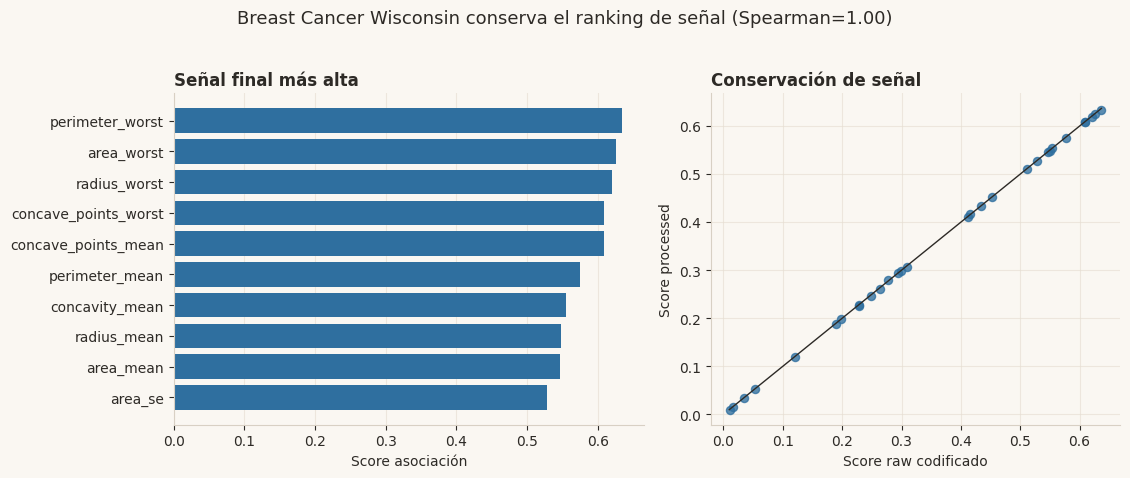

In [76]:
raw_assoc_breast_cancer_wisconsin, processed_assoc_breast_cancer_wisconsin, association_shift_breast_cancer_wisconsin = resumir_shift_asociacion("breast_cancer_wisconsin")
association_tests_breast_cancer_wisconsin = pd.DataFrame([
    evaluar_conservacion_asociacion("breast_cancer_wisconsin", raw_assoc_breast_cancer_wisconsin, processed_assoc_breast_cancer_wisconsin, association_shift_breast_cancer_wisconsin)
])

mostrar_tabla(processed_assoc_breast_cancer_wisconsin, "Asociación procesada - Breast Cancer Wisconsin", n=12)
mostrar_tabla(association_tests_breast_cancer_wisconsin, "Tests de conservación de señal - Breast Cancer Wisconsin")
mostrar_tabla(association_shift_breast_cancer_wisconsin.sort_values("delta_abs", ascending=False), "Shift de asociación - Breast Cancer Wisconsin", n=12)
graficar_asociacion_dataset(processed_assoc_breast_cancer_wisconsin, association_shift_breast_cancer_wisconsin, "breast_cancer_wisconsin")


Observación: se comparan 30 variables comunes, con top-k 10/10 y 27 señales FDR<=0.05; no se seleccionan features aquí.


### Asociación Variable-Target: `customer_churn`


**Asociación procesada - Customer Churn** - 7 filas, 10 columnas.

,Dataset,Variable,|Spearman|,Spearman p value,Mutual info,Score de asociación,N usado,Spearman q value bh,Fdr significativo 005,Ranking
0,customer_churn,total_spend,0.408048,0.000000e+00,0.393637,0.400842,12000,0.000000e+00,True,1
1,customer_churn,support_calls,0.552058,0.000000e+00,0.238758,0.395408,12000,0.000000e+00,True,2
2,customer_churn,payment_delay,0.283435,1.670684e-220,0.130429,0.206932,12000,3.898263e-220,True,3
3,customer_churn,age,0.204385,2.396026e-113,0.123875,0.164130,12000,4.193046e-113,True,4
4,customer_churn,last_interaction,0.147851,1.279013e-59,0.019438,0.083645,12000,1.790618e-59,True,5
5,customer_churn,tenure,0.052929,6.569887e-09,0.000000,0.026465,12000,7.664868e-09,True,6
6,customer_churn,usage_frequency,0.044362,1.165167e-06,0.002403,0.023382,12000,1.165167e-06,True,7


**Tests de conservación de señal - Customer Churn** - 1 filas, 12 columnas.

,Dataset,Variables comunes,Spearman rankings crudo/procesado,Mi spearman raw processed,Delta mi medio,Variables FDR<=0.05,Proporcion fdr significativas 005,Efecto post maximo spearman,Efecto post mediano spearman,Top-k,Solapamiento top-k,Ratio de solapamiento top-k
0,customer_churn,7,1.0,1.0,0.002978,7,1.0,0.552058,0.204385,7,6,0.857143


**Shift de asociación - Customer Churn** - 7 filas, 14 columnas.

,Dataset,Variable,Score crudo,Score procesado,|diferencia|,Spearman raw,Spearman processed,Delta spearman abs,Mutual info raw,Mutual info processed,Delta mi abs,Ranking crudo,Ranking procesado,Delta ranking
1,customer_churn,last_interaction,0.078628,0.083645,0.005016,0.147851,0.147851,0.0,0.009406,0.019438,0.010032,6,5,-1
4,customer_churn,tenure,0.027961,0.026465,0.001496,0.052929,0.052929,0.0,0.002993,0.000000,0.002993,7,6,-1
2,customer_churn,payment_delay,0.205493,0.206932,0.001439,0.283435,0.283435,0.0,0.127551,0.130429,0.002878,4,3,-1
6,customer_churn,usage_frequency,0.024787,0.023382,0.001405,0.044362,0.044362,0.0,0.005212,0.002403,0.002809,8,7,-1
3,customer_churn,support_calls,0.396026,0.395408,0.000618,0.552058,0.552058,0.0,0.239994,0.238758,0.001236,3,2,-1
5,customer_churn,total_spend,0.401204,0.400842,0.000362,0.408048,0.408048,0.0,0.394361,0.393637,0.000724,2,1,-1
0,customer_churn,age,0.164042,0.164130,0.000088,0.204385,0.204385,0.0,0.123699,0.123875,0.000176,5,4,-1


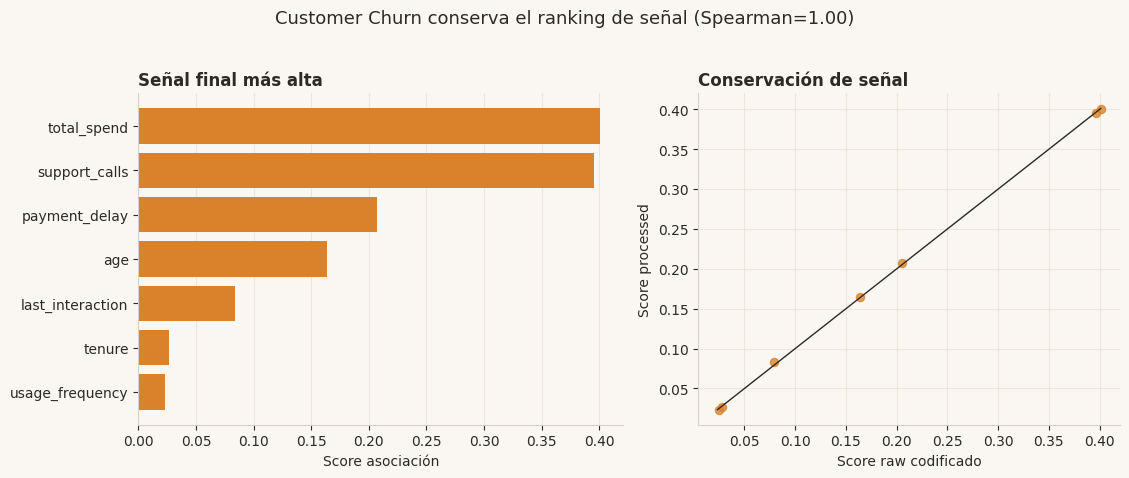

In [77]:
raw_assoc_customer_churn, processed_assoc_customer_churn, association_shift_customer_churn = resumir_shift_asociacion("customer_churn")
association_tests_customer_churn = pd.DataFrame([
    evaluar_conservacion_asociacion("customer_churn", raw_assoc_customer_churn, processed_assoc_customer_churn, association_shift_customer_churn)
])

mostrar_tabla(processed_assoc_customer_churn, "Asociación procesada - Customer Churn", n=12)
mostrar_tabla(association_tests_customer_churn, "Tests de conservación de señal - Customer Churn")
mostrar_tabla(association_shift_customer_churn.sort_values("delta_abs", ascending=False), "Shift de asociación - Customer Churn", n=12)
graficar_asociacion_dataset(processed_assoc_customer_churn, association_shift_customer_churn, "customer_churn")


Observación: se comparan 7 numéricas, con top-k 6/7 y 7 señales FDR<=0.05; las categóricas esperan al entrenamiento posterior.


### Asociación Variable-Target: `madelon`


**Asociación procesada - Madelon** - 500 filas, 10 columnas.

,Dataset,Variable,|Spearman|,Spearman p value,Mutual info,Score de asociación,N usado,Spearman q value bh,Fdr significativo 005,Ranking
0,madelon,feat_241,0.226986,8.740662e-25,0.043452,0.135219,2000,4.186545e-22,True,1
1,madelon,feat_475,0.225634,1.674618e-24,0.021157,0.123396,2000,4.186545e-22,True,2
2,madelon,feat_336,0.169303,2.501454e-14,0.037231,0.103267,2000,4.169090e-12,True,3
3,madelon,feat_338,0.141860,1.860069e-10,0.028029,0.084945,2000,1.860069e-08,True,4
4,madelon,feat_64,0.165602,9.136320e-14,0.000000,0.082801,2000,1.142040e-11,True,5
5,madelon,feat_105,0.131736,3.348769e-09,0.022599,0.077168,2000,2.391978e-07,True,6
6,madelon,feat_128,0.134217,1.681574e-09,0.014581,0.074399,2000,1.401311e-07,True,7
7,madelon,feat_472,0.106976,1.627617e-06,0.022816,0.064896,2000,7.398261e-05,True,8
8,madelon,feat_48,0.119035,9.343462e-08,0.006749,0.062892,2000,5.839664e-06,True,9
9,madelon,feat_442,0.107761,1.363376e-06,0.015792,0.061777,2000,6.816880e-05,True,10


**Tests de conservación de señal - Madelon** - 1 filas, 12 columnas.

,Dataset,Variables comunes,Spearman rankings crudo/procesado,Mi spearman raw processed,Delta mi medio,Variables FDR<=0.05,Proporcion fdr significativas 005,Efecto post maximo spearman,Efecto post mediano spearman,Top-k,Solapamiento top-k,Ratio de solapamiento top-k
0,madelon,500,1.0,1.0,0.0,13,0.026,0.226986,0.016847,10,10,1.0


**Shift de asociación - Madelon** - 500 filas, 14 columnas.

,Dataset,Variable,Score crudo,Score procesado,|diferencia|,Spearman raw,Spearman processed,Delta spearman abs,Mutual info raw,Mutual info processed,Delta mi abs,Ranking crudo,Ranking procesado,Delta ranking
499,madelon,feat_99,0.009345,0.009345,0.0,0.005898,0.005898,0.0,0.012793,0.012793,0.0,289,289,0
0,madelon,feat_0,0.013155,0.013155,0.0,0.005654,0.005654,0.0,0.020656,0.020656,0.0,187,187,0
1,madelon,feat_1,0.010959,0.010959,0.0,0.020846,0.020846,0.0,0.001072,0.001072,0.0,249,249,0
2,madelon,feat_10,0.027397,0.027397,0.0,0.054794,0.054794,0.0,0.000000,0.000000,0.0,29,29,0
483,madelon,feat_84,0.008422,0.008422,0.0,0.016845,0.016845,0.0,0.000000,0.000000,0.0,318,318,0
482,madelon,feat_83,0.008544,0.008544,0.0,0.017088,0.017088,0.0,0.000000,0.000000,0.0,316,316,0
481,madelon,feat_82,0.004957,0.004957,0.0,0.004593,0.004593,0.0,0.005320,0.005320,0.0,397,397,0
480,madelon,feat_81,0.000049,0.000049,0.0,0.000099,0.000099,0.0,0.000000,0.000000,0.0,500,500,0
479,madelon,feat_80,0.003186,0.003186,0.0,0.006372,0.006372,0.0,0.000000,0.000000,0.0,440,440,0
478,madelon,feat_8,0.006087,0.006087,0.0,0.012174,0.012174,0.0,0.000000,0.000000,0.0,370,370,0


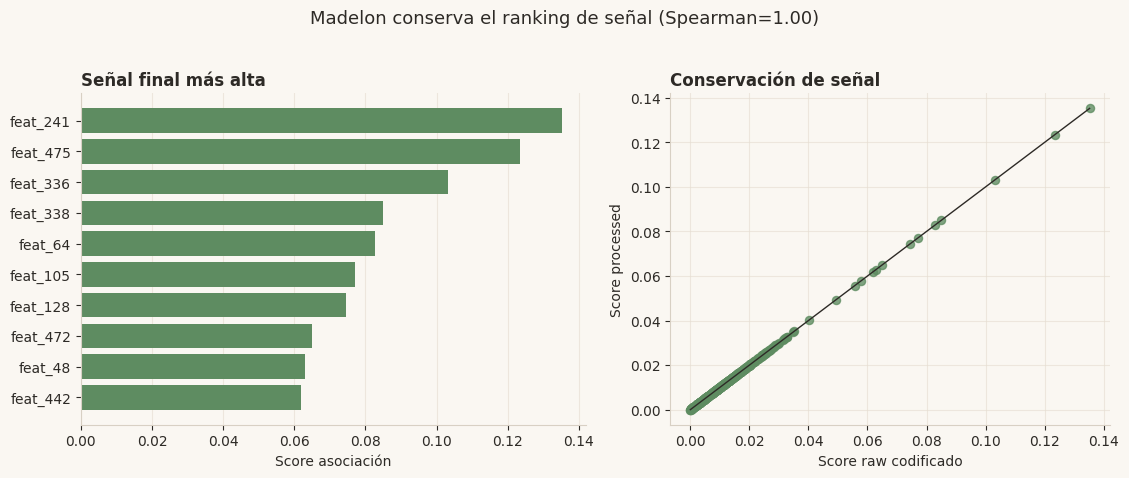

In [78]:
raw_assoc_madelon, processed_assoc_madelon, association_shift_madelon = resumir_shift_asociacion("madelon")
association_tests_madelon = pd.DataFrame([
    evaluar_conservacion_asociacion("madelon", raw_assoc_madelon, processed_assoc_madelon, association_shift_madelon)
])

mostrar_tabla(processed_assoc_madelon, "Asociación procesada - Madelon", n=12)
mostrar_tabla(association_tests_madelon, "Tests de conservación de señal - Madelon")
mostrar_tabla(association_shift_madelon.sort_values("delta_abs", ascending=False), "Shift de asociación - Madelon", n=12)
graficar_asociacion_dataset(processed_assoc_madelon, association_shift_madelon, "madelon")


Observación: se comparan 500 variables, con top-k 10/10 y 13 señales FDR<=0.05; la señal se audita bajo alta dimensionalidad.


### Asociación Variable-Target: `olive_oil`


**Asociación procesada - Olive Oil** - 10 filas, 10 columnas.

,Dataset,Variable,|Spearman|,Spearman p value,Mutual info,Score de asociación,N usado,Spearman q value bh,Fdr significativo 005,Ranking
0,olive_oil,palmitic,0.331371,3.985914e-16,1.966499,1.148935,572,1.328638e-15,True,1
1,olive_oil,eicosenoic,0.573923,2.031528e-51,0.637933,0.605928,572,2.031528e-50,True,2
2,olive_oil,stearic,0.163104,8.905613e-05,1.033483,0.598294,572,1.781123e-04,True,3
3,olive_oil,area,0.150314,3.089805e-04,0.989245,0.569780,572,5.149674e-04,True,4
4,olive_oil,linoleic,0.008641,8.366318e-01,1.089402,0.549021,572,8.366318e-01,False,5
5,olive_oil,linolenic,0.010537,8.014561e-01,1.060305,0.535421,572,8.366318e-01,False,6
6,olive_oil,oleic,0.376829,9.706901e-21,0.643804,0.510316,572,4.853450e-20,True,7
7,olive_oil,arachidic,0.242039,4.533158e-09,0.709803,0.475921,572,1.133290e-08,True,8
8,olive_oil,other,0.069354,9.750477e-02,0.809857,0.439606,572,1.392925e-01,False,9
9,olive_oil,palmitoleic,0.019158,6.474977e-01,0.851457,0.435308,572,8.093722e-01,False,10


**Tests de conservación de señal - Olive Oil** - 1 filas, 12 columnas.

,Dataset,Variables comunes,Spearman rankings crudo/procesado,Mi spearman raw processed,Delta mi medio,Variables FDR<=0.05,Proporcion fdr significativas 005,Efecto post maximo spearman,Efecto post mediano spearman,Top-k,Solapamiento top-k,Ratio de solapamiento top-k
0,olive_oil,10,0.987879,0.963636,0.017997,6,0.6,0.573923,0.156709,10,9,0.9


**Shift de asociación - Olive Oil** - 10 filas, 14 columnas.

,Dataset,Variable,Score crudo,Score procesado,|diferencia|,Spearman raw,Spearman processed,Delta spearman abs,Mutual info raw,Mutual info processed,Delta mi abs,Ranking crudo,Ranking procesado,Delta ranking
2,olive_oil,eicosenoic,0.635328,0.605928,0.029399,0.573923,0.573923,0.0,0.696732,0.637933,0.058799,3,2,-1
5,olive_oil,oleic,0.492602,0.510316,0.017715,0.376829,0.376829,0.0,0.608375,0.643804,0.035429,8,7,-1
0,olive_oil,arachidic,0.460420,0.475921,0.015500,0.242039,0.242039,0.0,0.678802,0.709803,0.031001,9,8,-1
6,olive_oil,other,0.429121,0.439606,0.010485,0.069354,0.069354,0.0,0.788888,0.809857,0.020970,11,9,-2
1,olive_oil,area,0.576654,0.569780,0.006874,0.150314,0.150314,0.0,1.002993,0.989245,0.013748,5,4,-1
8,olive_oil,palmitoleic,0.429162,0.435308,0.006146,0.019158,0.019158,0.0,0.839165,0.851457,0.012292,10,10,0
9,olive_oil,stearic,0.601205,0.598294,0.002911,0.163104,0.163104,0.0,1.039305,1.033483,0.005822,4,3,-1
3,olive_oil,linoleic,0.549910,0.549021,0.000889,0.008641,0.008641,0.0,1.091180,1.089402,0.001777,6,5,-1
4,olive_oil,linolenic,0.535489,0.535421,0.000068,0.010537,0.010537,0.0,1.060441,1.060305,0.000136,7,6,-1
7,olive_oil,palmitic,1.148935,1.148935,0.000000,0.331371,0.331371,0.0,1.966499,1.966499,0.000000,1,1,0


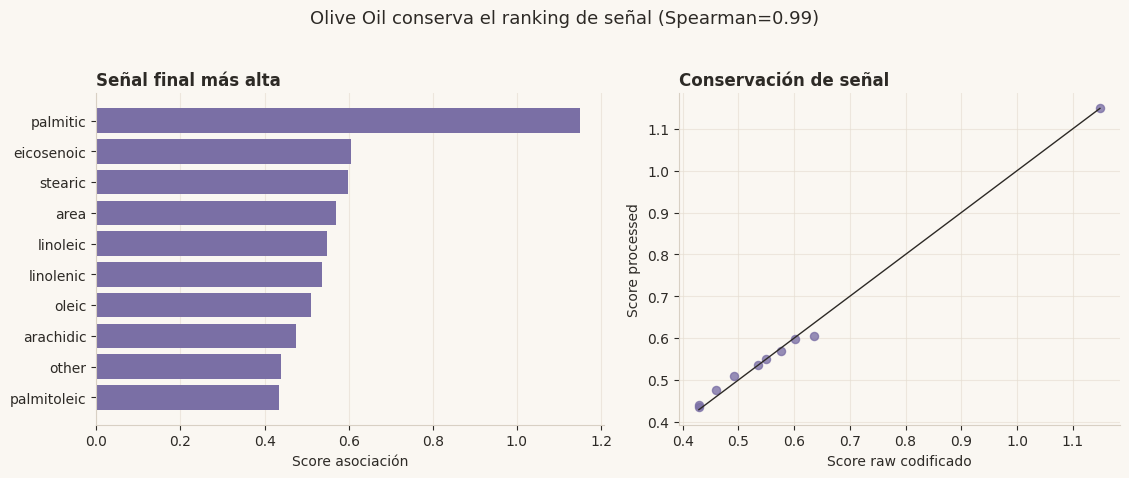

In [79]:
raw_assoc_olive_oil, processed_assoc_olive_oil, association_shift_olive_oil = resumir_shift_asociacion("olive_oil")
association_tests_olive_oil = pd.DataFrame([
    evaluar_conservacion_asociacion("olive_oil", raw_assoc_olive_oil, processed_assoc_olive_oil, association_shift_olive_oil)
])

mostrar_tabla(processed_assoc_olive_oil, "Asociación procesada - Olive Oil", n=12)
mostrar_tabla(association_tests_olive_oil, "Tests de conservación de señal - Olive Oil")
mostrar_tabla(association_shift_olive_oil.sort_values("delta_abs", ascending=False), "Shift de asociación - Olive Oil", n=12)
graficar_asociacion_dataset(processed_assoc_olive_oil, association_shift_olive_oil, "olive_oil")


Observación: se comparan 10 variables, con top-k 9/10 y 6 señales FDR<=0.05; la selección queda para la fase correspondiente.


### Resumen Comparativo de Asociación


In [80]:
processed_association = pd.concat([
    processed_assoc_breast_cancer_wisconsin,
    processed_assoc_customer_churn,
    processed_assoc_madelon,
    processed_assoc_olive_oil,
], ignore_index=True)

association_shift = pd.concat([
    association_shift_breast_cancer_wisconsin,
    association_shift_customer_churn,
    association_shift_madelon,
    association_shift_olive_oil,
], ignore_index=True)

association_tests = pd.concat([
    association_tests_breast_cancer_wisconsin,
    association_tests_customer_churn,
    association_tests_madelon,
    association_tests_olive_oil,
], ignore_index=True)

guardar_tabla(processed_association, "fase3_asociacion_processed.csv")
guardar_tabla(association_shift, "fase3_asociacion_shift.csv")
guardar_tabla(association_tests, "fase3_asociacion_tests.csv")
mostrar_tabla(association_tests, "Resumen de conservación de asociación")
mostrar_tabla(association_shift.sort_values("delta_abs", ascending=False), "Mayores cambios de asociación", n=20)

def resumen_asociacion_markdown(association_summary):
    lines = ["**Lectura de resultados de asociación variable-target.**"]
    for _, row in association_summary.iterrows():
        ranking = row["spearman_rankings_raw_processed"]
        ranking_text = "no calculable" if pd.isna(ranking) else f"{ranking:.3f}"
        lines.append(
            f"- `{row['dataset']}`: variables comunes={int(row['variables_comunes'])}, "
            f"correlación de rankings raw/processed={ranking_text}, "
            f"top-k overlap={int(row['top_k_overlap'])}/{int(row['top_k'])}, "
            f"FDR significativas={int(row['fdr_significativas_005'])}. "
            "Esto evalúa conservación de señal, no selección de variables."
        )
    lines.append(
        "Implicación: Fase 5 podrá usar estas señales como indicio previo, pero no como lista cerrada de features; "
        "en `madelon` especialmente importa distinguir señal real, ruido y estabilidad."
    )
    return "\n".join(lines)


display(Markdown(resumen_asociacion_markdown(association_tests)))


**Resumen de conservación de asociación** - 4 filas, 12 columnas.

,Dataset,Variables comunes,Spearman rankings crudo/procesado,Mi spearman raw processed,Delta mi medio,Variables FDR<=0.05,Proporcion fdr significativas 005,Efecto post maximo spearman,Efecto post mediano spearman,Top-k,Solapamiento top-k,Ratio de solapamiento top-k
0,breast_cancer_wisconsin,30,0.999555,0.998220,0.001977,27,0.900,0.796319,0.547764,10,10,1.000000
1,customer_churn,7,1.000000,1.000000,0.002978,7,1.000,0.552058,0.204385,7,6,0.857143
2,madelon,500,1.000000,1.000000,0.000000,13,0.026,0.226986,0.016847,10,10,1.000000
3,olive_oil,10,0.987879,0.963636,0.017997,6,0.600,0.573923,0.156709,10,9,0.900000


**Mayores cambios de asociación** - 547 filas, 14 columnas.

,Dataset,Variable,Score crudo,Score procesado,|diferencia|,Spearman raw,Spearman processed,Delta spearman abs,Mutual info raw,Mutual info processed,Delta mi abs,Ranking crudo,Ranking procesado,Delta ranking
539,olive_oil,eicosenoic,0.635328,0.605928,0.029399,0.573923,0.573923,0.0,0.696732,0.637933,0.058799,3,2,-1
542,olive_oil,oleic,0.492602,0.510316,0.017715,0.376829,0.376829,0.0,0.608375,0.643804,0.035429,8,7,-1
537,olive_oil,arachidic,0.460420,0.475921,0.015500,0.242039,0.242039,0.0,0.678802,0.709803,0.031001,9,8,-1
543,olive_oil,other,0.429121,0.439606,0.010485,0.069354,0.069354,0.0,0.788888,0.809857,0.020970,11,9,-2
538,olive_oil,area,0.576654,0.569780,0.006874,0.150314,0.150314,0.0,1.002993,0.989245,0.013748,5,4,-1
545,olive_oil,palmitoleic,0.429162,0.435308,0.006146,0.019158,0.019158,0.0,0.839165,0.851457,0.012292,10,10,0
31,customer_churn,last_interaction,0.078628,0.083645,0.005016,0.147851,0.147851,0.0,0.009406,0.019438,0.010032,6,5,-1
546,olive_oil,stearic,0.601205,0.598294,0.002911,0.163104,0.163104,0.0,1.039305,1.033483,0.005822,4,3,-1
17,breast_cancer_wisconsin,perimeter_worst,0.636811,0.634080,0.002730,0.796319,0.796319,0.0,0.477303,0.471842,0.005460,1,1,0
23,breast_cancer_wisconsin,smoothness_worst,0.263143,0.260605,0.002538,0.425513,0.425513,0.0,0.100772,0.095697,0.005075,20,20,0


**Lectura de resultados de asociación variable-target.**
- `breast_cancer_wisconsin`: variables comunes=30, correlación de rankings raw/processed=1.000, top-k overlap=10/10, FDR significativas=27. Esto evalúa conservación de señal, no selección de variables.
- `customer_churn`: variables comunes=7, correlación de rankings raw/processed=1.000, top-k overlap=6/7, FDR significativas=7. Esto evalúa conservación de señal, no selección de variables.
- `madelon`: variables comunes=500, correlación de rankings raw/processed=1.000, top-k overlap=10/10, FDR significativas=13. Esto evalúa conservación de señal, no selección de variables.
- `olive_oil`: variables comunes=10, correlación de rankings raw/processed=0.988, top-k overlap=9/10, FDR significativas=6. Esto evalúa conservación de señal, no selección de variables.
Implicación: Fase 5 podrá usar estas señales como indicio previo, pero no como lista cerrada de features; en `madelon` especialmente importa distinguir señal real, ruido y estabilidad.

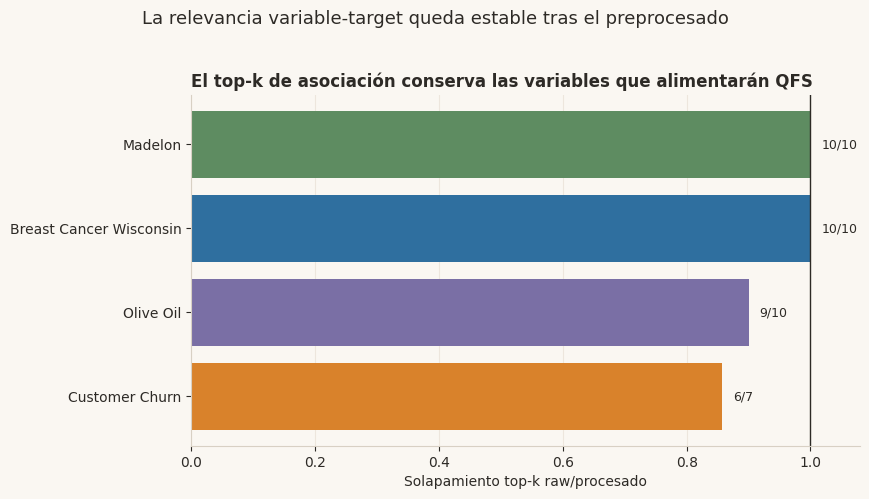

**Lectura de la figura de solapamiento top-k.** El peor caso es `customer_churn` con 6/7 variables compartidas (0.86); el mejor caso es `madelon` con 10/10. Esta lectura sustituye la antigua barra raw/procesado de dimensiones porque evalúa una magnitud relevante para QFS: si el ranking de `I(x_i;y)` cambia o no después del preprocesado.

In [81]:
topk_plot = association_tests.copy()
topk_plot["dataset_label"] = topk_plot["dataset"].map(etiqueta_dataset)
topk_plot["variables_perdidas_topk"] = topk_plot["top_k"] - topk_plot["top_k_overlap"]
topk_plot = topk_plot.sort_values("top_k_overlap_ratio")
figura, eje = plt.subplots(figsize=(8.8, 4.8))
bar_colors = [DATASET_COLORS[name] for name in topk_plot["dataset"]]
eje.barh(topk_plot["dataset_label"], topk_plot["top_k_overlap_ratio"], color=bar_colors)
eje.axvline(1.0, color="#2D2A26", linewidth=1.0)
for _, row in topk_plot.iterrows():
    eje.annotate(
        f"{int(row['top_k_overlap'])}/{int(row['top_k'])}",
        (row["top_k_overlap_ratio"], row["dataset_label"]),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
    )
eje.set_xlim(0, 1.08)
eje.set_xlabel("Solapamiento top-k raw/procesado")
eje.set_title("El top-k de asociación conserva las variables que alimentarán QFS", loc="left", fontweight="bold")
aplicar_estilo_eje(eje, eje_rejilla="x")
fijar_titulo_narrativo(figura, "La relevancia variable-target queda estable tras el preprocesado")
cerrar_figura_narrativa(figura, "fase3_asociacion_topk_overlap_qfs.png")

def lectura_figura_topk_asociacion(topk_table):
    peor = topk_table.sort_values("top_k_overlap_ratio").iloc[0]
    mejor = topk_table.sort_values("top_k_overlap_ratio", ascending=False).iloc[0]
    return (
        "**Lectura de la figura de solapamiento top-k.** "
        f"El peor caso es `{peor['dataset']}` con {int(peor['top_k_overlap'])}/{int(peor['top_k'])} variables compartidas "
        f"({peor['top_k_overlap_ratio']:.2f}); el mejor caso es `{mejor['dataset']}` con "
        f"{int(mejor['top_k_overlap'])}/{int(mejor['top_k'])}. "
        "Esta lectura sustituye la antigua barra raw/procesado de dimensiones porque evalúa una magnitud relevante para QFS: "
        "si el ranking de `I(x_i;y)` cambia o no después del preprocesado."
    )


display(Markdown(lectura_figura_topk_asociacion(topk_plot)))


## 3.8 Redundancia y Correlación Post-Preprocesado

Se revisan correlaciones Pearson y Spearman entre variables numéricas procesadas. Además se compara la matriz raw contra la processed para comprobar si el preprocesado ha cambiado la estructura de redundancia. Si quedan categóricas, se calcula Cramér's V como asociación categórica descriptiva.

Este bloque es la garantía previa para el término de redundancia que consumirá QFS: el paper codifica `I(x_i;x_j)` como proximidad/distancia entre átomos, por lo que una matriz de relaciones internas deformada desplazaría la geometría de MDS y la intensidad efectiva del bloqueo de Rydberg. Aquí se exige que raw y processed mantengan matrices comparables antes de usar cualquier selección.

Pearson captura redundancia lineal y Spearman captura redundancia monótona. El umbral `0.85` marca pares muy parecidos que pueden condicionar selección de características, estabilidad de modelos o interpretabilidad.

VIF aproxima multicolinealidad multivariante: valores altos indican que una variable puede explicarse por una combinación de otras. Aquí se documenta como carga estructural del dataset, no como filtro automático.

La similitud entre matrices raw y processed permite comprobar si el preprocesado cambió relaciones internas. En datasets con categóricas pendientes, Cramér's V solo describe asociación entre variables categóricas y target; no sustituye al encoding posterior.


In [82]:
def obtener_features_numericas(datos_dataset, target_name=PROCESSED_TARGET):
    return [name for name in datos_dataset.columns if name != target_name and pd.api.types.is_numeric_dtype(datos_dataset[name])]


def crear_filas_correlacion_alta(nombre_dataset, corr_matrix, metodo):
    rows = []
    columns = list(corr_matrix.columns)
    for left_position, variable_a in enumerate(columns):
        for variable_b in columns[left_position + 1:]:
            corr_value = float(corr_matrix.loc[variable_a, variable_b])
            if corr_value >= HIGH_CORRELATION_THRESHOLD:
                rows.append({"dataset": nombre_dataset, "metodo": metodo, "variable_a": variable_a, "variable_b": variable_b, "abs_correlacion": corr_value})
    return rows


def crear_tabla_correlaciones(rows):
    return pd.DataFrame(rows, columns=["dataset", "metodo", "variable_a", "variable_b", "abs_correlacion"])


In [83]:
def vectorizar_triangulo_superior(corr_matrix):
    if corr_matrix.shape[0] < 2:
        return np.array([])
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    return corr_matrix.where(mask).stack().to_numpy(dtype=float)


def variables_numericas_comparables(nombre_dataset, raw_renamed):
    comparable = []
    for raw_name, processed_name in variables_comparables(nombre_dataset):
        if (
            processed_name in raw_renamed.columns
            and processed_name in processed_datasets[nombre_dataset].columns
            and pd.api.types.is_numeric_dtype(raw_renamed[processed_name])
            and pd.api.types.is_numeric_dtype(processed_datasets[nombre_dataset][processed_name])
        ):
            comparable.append(processed_name)
    return sorted(set(comparable))


def fila_matriz_no_comparable(nombre_dataset, metodo, n_variables):
    return {
        "dataset": nombre_dataset,
        "metodo": metodo,
        "variables_comunes": n_variables,
        "pares_comunes": 0,
        "correlacion_entre_matrices": np.nan,
        "frobenius_norm_difference": np.nan,
    }


def correlacion_entre_vectores(raw_vector, processed_vector):
    if len(raw_vector) < 2 or np.std(raw_vector) == 0 or np.std(processed_vector) == 0:
        return 1.0 if np.allclose(raw_vector, processed_vector) else np.nan
    return float(np.corrcoef(raw_vector, processed_vector)[0, 1])


In [84]:
def resumir_matrices_correlacion(nombre_dataset, metodo, comparable, raw_corr, processed_corr):
    raw_vector = vectorizar_triangulo_superior(raw_corr)
    processed_vector = vectorizar_triangulo_superior(processed_corr)
    return {
        "dataset": nombre_dataset,
        "metodo": metodo,
        "variables_comunes": len(comparable),
        "pares_comunes": len(raw_vector),
        "correlacion_entre_matrices": correlacion_entre_vectores(raw_vector, processed_vector),
        "frobenius_norm_difference": float(np.linalg.norm(raw_corr.to_numpy() - processed_corr.to_numpy(), ord="fro")),
    }


def comparar_matrices_correlacion(nombre_dataset, metodo):
    raw_renamed = raw_datasets[nombre_dataset].rename(columns=mapa_original_a_procesada(nombre_dataset))
    comparable = variables_numericas_comparables(nombre_dataset, raw_renamed)
    if len(comparable) < 2:
        return fila_matriz_no_comparable(nombre_dataset, metodo, len(comparable))
    raw_corr = raw_renamed[comparable].corr(method=metodo).fillna(0)
    processed_corr = processed_datasets[nombre_dataset][comparable].corr(method=metodo).fillna(0)
    return resumir_matrices_correlacion(nombre_dataset, metodo, comparable, raw_corr, processed_corr)


In [85]:
def matriz_vif_limpia(datos_processed):
    numeric_features = obtener_features_numericas(datos_processed)
    matrix = datos_processed[numeric_features].replace([np.inf, -np.inf], np.nan)
    matrix = matrix.fillna(matrix.median(numeric_only=True))
    return matrix[[name for name in matrix.columns if matrix[name].nunique(dropna=True) > 1]]


def calcular_vif_desde_matriz(matrix):
    corr = matrix.corr(method="pearson").fillna(0)
    corr_values = corr.to_numpy(copy=True)
    np.fill_diagonal(corr_values, 1.0)
    inverse_corr = np.linalg.pinv(corr_values)
    return np.maximum(np.diag(inverse_corr), 1.0)


def calcular_vif_dataset(nombre_dataset, datos_processed):
    matrix = matriz_vif_limpia(datos_processed)
    if matrix.shape[1] < 2:
        return pd.DataFrame(columns=["dataset", "variable", "vif"])
    return pd.DataFrame({"dataset": nombre_dataset, "variable": matrix.columns, "vif": calcular_vif_desde_matriz(matrix)})


def resumir_vif_dataset(nombre_dataset, vif_dataset):
    if vif_dataset.empty:
        return {"dataset": nombre_dataset, "vif_max": np.nan, "vif_mediana": np.nan, "variables_vif_ge_10": 0}
    return {
        "dataset": nombre_dataset,
        "vif_max": float(vif_dataset["vif"].max()),
        "vif_mediana": float(vif_dataset["vif"].median()),
        "variables_vif_ge_10": int((vif_dataset["vif"] >= 10).sum()),
    }


In [86]:
def calcular_cramers_v(serie_a, serie_b):
    contingency = pd.crosstab(serie_a.astype(str), serie_b.astype(str))
    if contingency.empty or contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(contingency, correction=False)[0]
    n = contingency.to_numpy().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denominator = min(kcorr - 1, rcorr - 1)
    if denominator <= 0:
        return np.nan
    return float(np.sqrt(phi2corr / denominator))


In [87]:
def columnas_categoricas_con_target(datos_processed):
    categorical_features = [
        name
        for name in datos_processed.columns
        if name != PROCESSED_TARGET and not pd.api.types.is_numeric_dtype(datos_processed[name])
    ]
    return categorical_features + ([PROCESSED_TARGET] if categorical_features else [])


def crear_fila_cramers_v(nombre_dataset, datos_processed, variable_a, variable_b):
    return {
        "dataset": nombre_dataset,
        "variable_a": variable_a,
        "variable_b": variable_b,
        "incluye_target": variable_a == PROCESSED_TARGET or variable_b == PROCESSED_TARGET,
        "cramers_v": calcular_cramers_v(datos_processed[variable_a], datos_processed[variable_b]),
    }


def calcular_cramers_v_dataset(nombre_dataset, datos_processed):
    rows = []
    for variable_a, variable_b in combinations(columnas_categoricas_con_target(datos_processed), 2):
        rows.append(crear_fila_cramers_v(nombre_dataset, datos_processed, variable_a, variable_b))
    return pd.DataFrame(rows, columns=["dataset", "variable_a", "variable_b", "incluye_target", "cramers_v"])


In [88]:
def preparar_matriz_correlacion(datos_processed, numeric_features):
    matrix = datos_processed[numeric_features].replace([np.inf, -np.inf], np.nan)
    return matrix.fillna(matrix.median(numeric_only=True))


def resumen_correlacion_sin_pares(nombre_dataset, n_features):
    return {
        "dataset": nombre_dataset,
        "variables_numericas": n_features,
        "pares_evaluados": 0,
        "pares_abs_pearson_ge_085": 0,
        "pares_abs_spearman_ge_085": 0,
        "abs_pearson_maxima": np.nan,
        "abs_spearman_maxima": np.nan,
        **resumir_vif_dataset(nombre_dataset, pd.DataFrame()),
    }


def comparar_matrices_pearson_spearman(nombre_dataset):
    return pd.DataFrame([
        comparar_matrices_correlacion(nombre_dataset, "pearson"),
        comparar_matrices_correlacion(nombre_dataset, "spearman"),
    ])


In [89]:
def resumir_correlacion_numerica(nombre_dataset, numeric_features, pearson_matrix, spearman_matrix, vif_dataset):
    pearson_rows = crear_filas_correlacion_alta(nombre_dataset, pearson_matrix, "pearson")
    spearman_rows = crear_filas_correlacion_alta(nombre_dataset, spearman_matrix, "spearman")
    total_pairs = int(len(numeric_features) * (len(numeric_features) - 1) / 2)
    summary = {
        "dataset": nombre_dataset,
        "variables_numericas": len(numeric_features),
        "pares_evaluados": total_pairs,
        "pares_abs_pearson_ge_085": len(pearson_rows),
        "pares_abs_spearman_ge_085": len(spearman_rows),
        "abs_pearson_maxima": float(vectorizar_triangulo_superior(pearson_matrix).max()),
        "abs_spearman_maxima": float(vectorizar_triangulo_superior(spearman_matrix).max()),
        **resumir_vif_dataset(nombre_dataset, vif_dataset),
    }
    return crear_tabla_correlaciones(pearson_rows + spearman_rows), summary


def calcular_auditoria_correlacion(nombre_dataset, datos_processed):
    numeric_features = obtener_features_numericas(datos_processed)
    if len(numeric_features) < 2:
        return crear_tabla_correlaciones([]), resumen_correlacion_sin_pares(nombre_dataset, len(numeric_features)), comparar_matrices_pearson_spearman(nombre_dataset), pd.DataFrame(columns=["dataset", "variable", "vif"]), calcular_cramers_v_dataset(nombre_dataset, datos_processed)
    processed_numeric = preparar_matriz_correlacion(datos_processed, numeric_features)
    pearson_matrix = processed_numeric.corr(method="pearson").abs().fillna(0)
    spearman_matrix = processed_numeric.corr(method="spearman").abs().fillna(0)
    vif_dataset = calcular_vif_dataset(nombre_dataset, datos_processed)
    pairs, summary = resumir_correlacion_numerica(nombre_dataset, numeric_features, pearson_matrix, spearman_matrix, vif_dataset)
    return pairs, summary, comparar_matrices_pearson_spearman(nombre_dataset), vif_dataset, calcular_cramers_v_dataset(nombre_dataset, datos_processed)


In [90]:
def dibujar_distribucion_correlaciones(eje, datos_processed, nombre_dataset):
    numeric_features = obtener_features_numericas(datos_processed)
    if len(numeric_features) < 2:
        eje.axis("off")
        eje.text(0.02, 0.55, "Sin pares numéricos", fontsize=11, color="#2D2A26")
        return
    corr_values = vectorizar_triangulo_superior(datos_processed[numeric_features].corr(method="spearman").abs().fillna(0))
    eje.hist(corr_values, bins=24, color=color_dataset(nombre_dataset), alpha=0.82)
    eje.axvline(HIGH_CORRELATION_THRESHOLD, color="#B85C5C", linewidth=1.2)
    eje.set_xlabel("|Spearman|")
    eje.set_ylabel("Pares")
    eje.set_title("Distribución de redundancia", loc="left", fontweight="bold")
    aplicar_estilo_eje(eje, eje_rejilla="y")


def dibujar_top_vif(eje, vif_dataset):
    if vif_dataset.empty:
        eje.axis("off")
        eje.text(0.02, 0.55, "VIF no calculable", fontsize=11, color="#2D2A26")
        return
    top_vif = vif_dataset.sort_values("vif", ascending=False).head(10).sort_values("vif")
    eje.barh(top_vif["variable"], top_vif["vif"], color="#D9822B")
    eje.axvline(10, color="#B85C5C", linewidth=1.2)
    eje.set_xlabel("VIF")
    eje.set_title("Multicolinealidad final", loc="left", fontweight="bold")
    aplicar_estilo_eje(eje, eje_rejilla="x")


In [91]:
def mensaje_redundancia(vif_dataset, nombre_dataset):
    if vif_dataset.empty:
        return f"{etiqueta_dataset(nombre_dataset)} no permite evaluar multicolinealidad"
    vif_max = vif_dataset["vif"].max()
    if vif_max >= 10:
        return f"{etiqueta_dataset(nombre_dataset)} mantiene multicolinealidad alta documentada"
    return f"{etiqueta_dataset(nombre_dataset)} no muestra multicolinealidad crítica"


def graficar_redundancia_dataset(datos_processed, vif_dataset, nombre_dataset):
    figura, ejes = plt.subplots(1, 2, figsize=(11.2, 4.4), width_ratios=[1.0, 1.15])
    dibujar_distribucion_correlaciones(ejes[0], datos_processed, nombre_dataset)
    dibujar_top_vif(ejes[1], vif_dataset)
    fijar_titulo_narrativo(figura, mensaje_redundancia(vif_dataset, nombre_dataset))
    cerrar_figura_narrativa(figura, f"fase3_redundancia_{nombre_dataset}.png")


### Correlación Post-Preprocesado: `breast_cancer_wisconsin`


**Resumen correlación - Breast Cancer Wisconsin** - 1 filas, 10 columnas.

,Dataset,Variables numéricas,Pares evaluados,Pares Pearson >=0.85,Pares Spearman >=0.85,|Pearson| máxima,|Spearman| máxima,VIF máximo,VIF mediano,Variables con VIF>=10
0,breast_cancer_wisconsin,30,435,29,29,0.997855,0.999602,3806.115296,25.416128,23


**Similitud de matriz cruda vs procesada - Breast Cancer Wisconsin** - 2 filas, 6 columnas.

,Dataset,Método,Variables comunes,Pares comunes,Correlación entre matrices,Diferencia norma Frobenius
0,breast_cancer_wisconsin,pearson,30,435,1.0,0.0
1,breast_cancer_wisconsin,spearman,30,435,1.0,0.0


**VIF procesado - Breast Cancer Wisconsin** - 30 filas, 3 columnas.

,Dataset,Variable,VIF
0,breast_cancer_wisconsin,radius_mean,3806.115296
2,breast_cancer_wisconsin,perimeter_mean,3786.400419
20,breast_cancer_wisconsin,radius_worst,799.105946
22,breast_cancer_wisconsin,perimeter_worst,405.023336
3,breast_cancer_wisconsin,area_mean,347.878657
23,breast_cancer_wisconsin,area_worst,337.221924
10,breast_cancer_wisconsin,radius_se,75.462027
6,breast_cancer_wisconsin,concavity_mean,70.767720
12,breast_cancer_wisconsin,perimeter_se,70.359695
7,breast_cancer_wisconsin,concave_points_mean,60.041733


**Cramér's V categóricas - Breast Cancer Wisconsin** - 0 filas, 5 columnas.

,Dataset,Variable A,Variable B,Incluye target,V de Cramér


**Pares con correlación alta - Breast Cancer Wisconsin** - 58 filas, 5 columnas.

,Dataset,Método,Variable A,Variable B,|correlación|
30,breast_cancer_wisconsin,spearman,radius_mean,area_mean,0.999602
54,breast_cancer_wisconsin,spearman,radius_worst,area_worst,0.998891
0,breast_cancer_wisconsin,pearson,radius_mean,perimeter_mean,0.997855
29,breast_cancer_wisconsin,spearman,radius_mean,perimeter_mean,0.997802
35,breast_cancer_wisconsin,spearman,perimeter_mean,area_mean,0.997068
24,breast_cancer_wisconsin,pearson,radius_worst,perimeter_worst,0.993708
53,breast_cancer_wisconsin,spearman,radius_worst,perimeter_worst,0.993548
55,breast_cancer_wisconsin,spearman,perimeter_worst,area_worst,0.992433
1,breast_cancer_wisconsin,pearson,radius_mean,area_mean,0.987357
6,breast_cancer_wisconsin,pearson,perimeter_mean,area_mean,0.986507


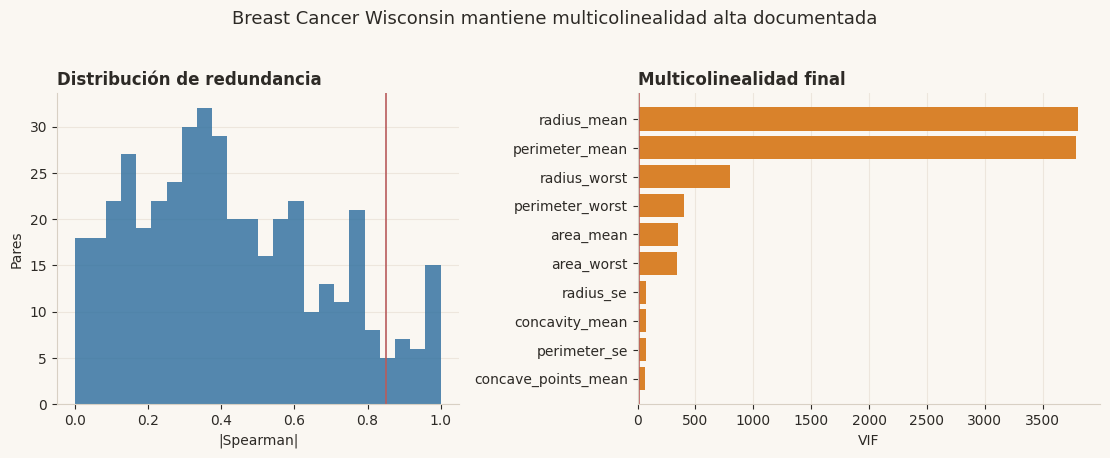

In [92]:
correlation_pairs_breast_cancer_wisconsin, correlation_summary_breast_cancer_wisconsin, correlation_matrix_shift_breast_cancer_wisconsin, vif_breast_cancer_wisconsin, categorical_assoc_breast_cancer_wisconsin = calcular_auditoria_correlacion("breast_cancer_wisconsin", processed_breast_cancer_wisconsin)
correlation_summary_breast_cancer_wisconsin = pd.DataFrame([correlation_summary_breast_cancer_wisconsin])

mostrar_tabla(correlation_summary_breast_cancer_wisconsin, "Resumen correlación - Breast Cancer Wisconsin")
mostrar_tabla(correlation_matrix_shift_breast_cancer_wisconsin, "Similitud de matriz cruda vs procesada - Breast Cancer Wisconsin")
mostrar_tabla(vif_breast_cancer_wisconsin.sort_values("vif", ascending=False), "VIF procesado - Breast Cancer Wisconsin", n=12)
mostrar_tabla(categorical_assoc_breast_cancer_wisconsin.sort_values("cramers_v", ascending=False), "Cramér's V categóricas - Breast Cancer Wisconsin", n=12)
mostrar_tabla(correlation_pairs_breast_cancer_wisconsin.sort_values("abs_correlacion", ascending=False), "Pares con correlación alta - Breast Cancer Wisconsin", n=12)
graficar_redundancia_dataset(processed_breast_cancer_wisconsin, vif_breast_cancer_wisconsin, "breast_cancer_wisconsin")


Observación: la matriz deja 29 pares con Spearman>=0.85 y un VIF máximo de 3806.115; la redundancia morfológica se conserva.


### Correlación Post-Preprocesado: `customer_churn`


**Resumen correlación - Customer Churn** - 1 filas, 10 columnas.

,Dataset,Variables numéricas,Pares evaluados,Pares Pearson >=0.85,Pares Spearman >=0.85,|Pearson| máxima,|Spearman| máxima,VIF máximo,VIF mediano,Variables con VIF>=10
0,customer_churn,7,21,0,0,0.221594,0.199095,1.098391,1.029818,0


**Similitud de matriz cruda vs procesada - Customer Churn** - 2 filas, 6 columnas.

,Dataset,Método,Variables comunes,Pares comunes,Correlación entre matrices,Diferencia norma Frobenius
0,customer_churn,pearson,7,21,1.0,0.0
1,customer_churn,spearman,7,21,1.0,0.0


**VIF procesado - Customer Churn** - 7 filas, 3 columnas.

,Dataset,Variable,VIF
3,customer_churn,support_calls,1.098391
5,customer_churn,total_spend,1.064231
4,customer_churn,payment_delay,1.037381
0,customer_churn,age,1.029818
6,customer_churn,last_interaction,1.008707
1,customer_churn,tenure,1.001890
2,customer_churn,usage_frequency,1.001564


**Cramér's V categóricas - Customer Churn** - 6 filas, 5 columnas.

,Dataset,Variable A,Variable B,Incluye target,V de Cramér
5,customer_churn,contract_length,target,True,0.433548
2,customer_churn,gender,target,True,0.175388
1,customer_churn,gender,contract_length,False,0.067609
4,customer_churn,subscription_type,target,True,0.020443
3,customer_churn,subscription_type,contract_length,False,0.006810
0,customer_churn,gender,subscription_type,False,0.002568


**Pares con correlación alta - Customer Churn** - 0 filas, 5 columnas.

,Dataset,Método,Variable A,Variable B,|correlación|


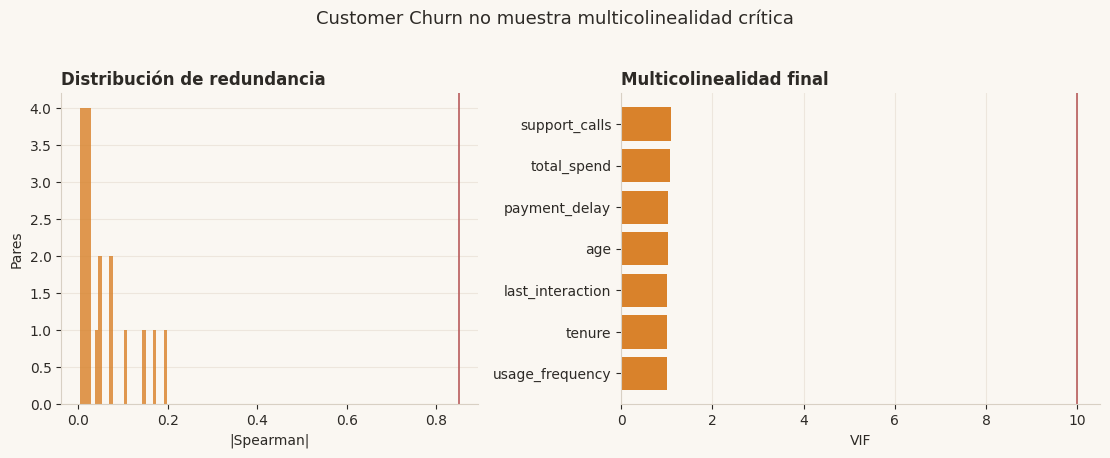

In [93]:
correlation_pairs_customer_churn, correlation_summary_customer_churn, correlation_matrix_shift_customer_churn, vif_customer_churn, categorical_assoc_customer_churn = calcular_auditoria_correlacion("customer_churn", processed_customer_churn)
correlation_summary_customer_churn = pd.DataFrame([correlation_summary_customer_churn])

mostrar_tabla(correlation_summary_customer_churn, "Resumen correlación - Customer Churn")
mostrar_tabla(correlation_matrix_shift_customer_churn, "Similitud de matriz cruda vs procesada - Customer Churn")
mostrar_tabla(vif_customer_churn.sort_values("vif", ascending=False), "VIF procesado - Customer Churn", n=12)
mostrar_tabla(categorical_assoc_customer_churn.sort_values("cramers_v", ascending=False), "Cramér's V categóricas - Customer Churn", n=12)
mostrar_tabla(correlation_pairs_customer_churn.sort_values("abs_correlacion", ascending=False), "Pares con correlación alta - Customer Churn", n=12)
graficar_redundancia_dataset(processed_customer_churn, vif_customer_churn, "customer_churn")


Observación: el recuento de pares Spearman>=0.85 es 0 y el VIF máximo vale 1.098; no hay correlación fuerte en numéricas.


### Correlación Post-Preprocesado: `madelon`


**Resumen correlación - Madelon** - 1 filas, 10 columnas.

,Dataset,Variables numéricas,Pares evaluados,Pares Pearson >=0.85,Pares Spearman >=0.85,|Pearson| máxima,|Spearman| máxima,VIF máximo,VIF mediano,Variables con VIF>=10
0,madelon,500,124750,12,12,0.990429,0.996145,116.63073,1.333522,20


**Similitud de matriz cruda vs procesada - Madelon** - 2 filas, 6 columnas.

,Dataset,Método,Variables comunes,Pares comunes,Correlación entre matrices,Diferencia norma Frobenius
0,madelon,pearson,500,124750,1.0,0.0
1,madelon,spearman,500,124750,1.0,0.0


**VIF procesado - Madelon** - 500 filas, 3 columnas.

,Dataset,Variable,VIF
338,madelon,feat_338,116.630730
472,madelon,feat_472,108.889287
442,madelon,feat_442,107.237639
493,madelon,feat_493,103.744450
64,madelon,feat_64,103.404575
336,madelon,feat_336,103.079673
475,madelon,feat_475,102.405609
105,madelon,feat_105,100.181701
128,madelon,feat_128,97.604157
455,madelon,feat_455,97.073844


**Cramér's V categóricas - Madelon** - 0 filas, 5 columnas.

,Dataset,Variable A,Variable B,Incluye target,V de Cramér


**Pares con correlación alta - Madelon** - 24 filas, 5 columnas.

,Dataset,Método,Variable A,Variable B,|correlación|
22,madelon,spearman,feat_442,feat_472,0.996145
15,madelon,spearman,feat_64,feat_336,0.995649
23,madelon,spearman,feat_453,feat_493,0.995000
16,madelon,spearman,feat_105,feat_128,0.994693
12,madelon,spearman,feat_28,feat_318,0.991467
21,madelon,spearman,feat_318,feat_451,0.991039
19,madelon,spearman,feat_241,feat_475,0.990637
13,madelon,spearman,feat_28,feat_451,0.990560
3,madelon,pearson,feat_64,feat_336,0.990429
10,madelon,pearson,feat_442,feat_472,0.990300


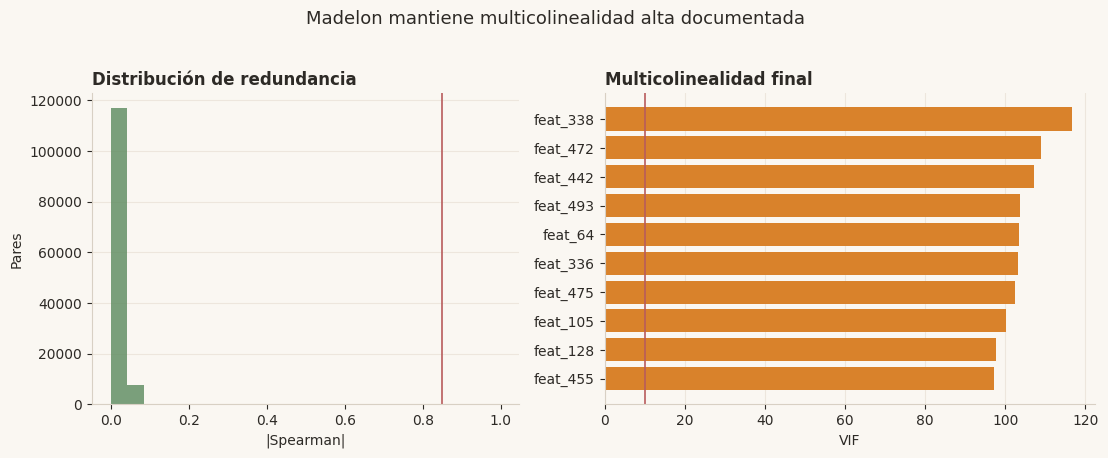

In [94]:
correlation_pairs_madelon, correlation_summary_madelon, correlation_matrix_shift_madelon, vif_madelon, categorical_assoc_madelon = calcular_auditoria_correlacion("madelon", processed_madelon)
correlation_summary_madelon = pd.DataFrame([correlation_summary_madelon])

mostrar_tabla(correlation_summary_madelon, "Resumen correlación - Madelon")
mostrar_tabla(correlation_matrix_shift_madelon, "Similitud de matriz cruda vs procesada - Madelon")
mostrar_tabla(vif_madelon.sort_values("vif", ascending=False), "VIF procesado - Madelon", n=12)
mostrar_tabla(categorical_assoc_madelon.sort_values("cramers_v", ascending=False), "Cramér's V categóricas - Madelon", n=12)
mostrar_tabla(correlation_pairs_madelon.sort_values("abs_correlacion", ascending=False), "Pares con correlación alta - Madelon", n=12)
graficar_redundancia_dataset(processed_madelon, vif_madelon, "madelon")


Observación: se detectan 12 pares por encima de Spearman 0.85 y VIF máximo=116.631; la selección posterior debe manejar redundancia sintética.


### Correlación Post-Preprocesado: `olive_oil`


**Resumen correlación - Olive Oil** - 1 filas, 10 columnas.

,Dataset,Variables numéricas,Pares evaluados,Pares Pearson >=0.85,Pares Spearman >=0.85,|Pearson| máxima,|Spearman| máxima,VIF máximo,VIF mediano,Variables con VIF>=10
0,olive_oil,10,45,3,2,0.95153,0.916474,325.937133,11.490753,5


**Similitud de matriz cruda vs procesada - Olive Oil** - 2 filas, 6 columnas.

,Dataset,Método,Variables comunes,Pares comunes,Correlación entre matrices,Diferencia norma Frobenius
0,olive_oil,pearson,10,45,1.0,0.0
1,olive_oil,spearman,10,45,1.0,0.0


**VIF procesado - Olive Oil** - 10 filas, 3 columnas.

,Dataset,Variable,VIF
5,olive_oil,linoleic,325.937133
6,olive_oil,linolenic,109.860017
2,olive_oil,palmitoleic,66.445436
0,olive_oil,area,25.250450
1,olive_oil,palmitic,13.304520
3,olive_oil,stearic,9.676985
9,olive_oil,other,6.032410
4,olive_oil,oleic,4.328467
7,olive_oil,arachidic,3.151542
8,olive_oil,eicosenoic,2.968024


**Cramér's V categóricas - Olive Oil** - 0 filas, 5 columnas.

,Dataset,Variable A,Variable B,Incluye target,V de Cramér


**Pares con correlación alta - Olive Oil** - 5 filas, 5 columnas.

,Dataset,Método,Variable A,Variable B,|correlación|
0,olive_oil,pearson,area,palmitic,0.951530
3,olive_oil,spearman,area,palmitic,0.916474
4,olive_oil,spearman,stearic,linoleic,0.864409
1,olive_oil,pearson,stearic,linoleic,0.852438
2,olive_oil,pearson,linoleic,linolenic,0.850318


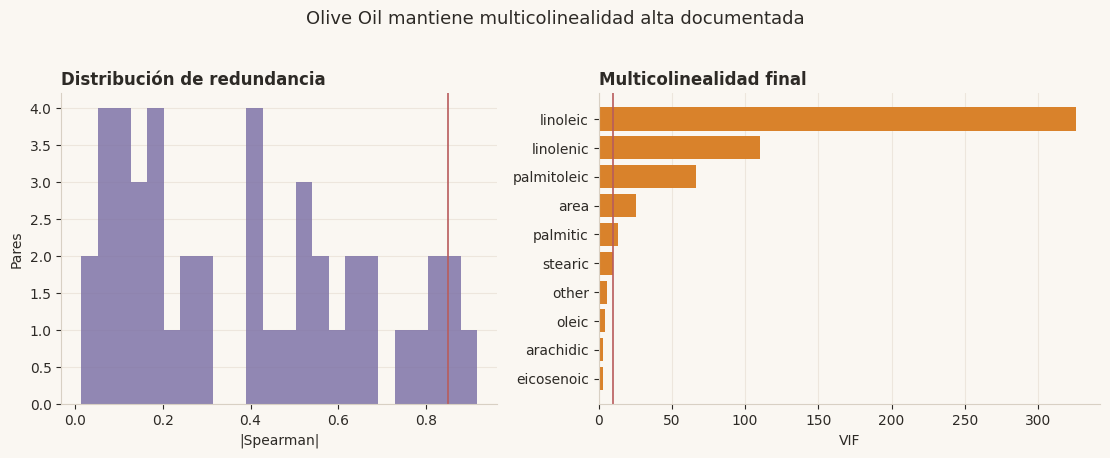

In [95]:
correlation_pairs_olive_oil, correlation_summary_olive_oil, correlation_matrix_shift_olive_oil, vif_olive_oil, categorical_assoc_olive_oil = calcular_auditoria_correlacion("olive_oil", processed_olive_oil)
correlation_summary_olive_oil = pd.DataFrame([correlation_summary_olive_oil])

mostrar_tabla(correlation_summary_olive_oil, "Resumen correlación - Olive Oil")
mostrar_tabla(correlation_matrix_shift_olive_oil, "Similitud de matriz cruda vs procesada - Olive Oil")
mostrar_tabla(vif_olive_oil.sort_values("vif", ascending=False), "VIF procesado - Olive Oil", n=12)
mostrar_tabla(categorical_assoc_olive_oil.sort_values("cramers_v", ascending=False), "Cramér's V categóricas - Olive Oil", n=12)
mostrar_tabla(correlation_pairs_olive_oil.sort_values("abs_correlacion", ascending=False), "Pares con correlación alta - Olive Oil", n=12)
graficar_redundancia_dataset(processed_olive_oil, vif_olive_oil, "olive_oil")


Observación: el resumen marca 2 pares Spearman>=0.85 junto a VIF máximo=325.937; las composiciones correlacionadas se documentan sin filtrado.


### Resumen Comparativo de Correlación


In [96]:
high_correlation_pairs = pd.concat([
    correlation_pairs_breast_cancer_wisconsin,
    correlation_pairs_customer_churn,
    correlation_pairs_madelon,
    correlation_pairs_olive_oil,
], ignore_index=True)

correlation_summary = pd.concat([
    correlation_summary_breast_cancer_wisconsin,
    correlation_summary_customer_churn,
    correlation_summary_madelon,
    correlation_summary_olive_oil,
], ignore_index=True)


In [97]:
correlation_matrix_shift = pd.concat([
    correlation_matrix_shift_breast_cancer_wisconsin,
    correlation_matrix_shift_customer_churn,
    correlation_matrix_shift_madelon,
    correlation_matrix_shift_olive_oil,
], ignore_index=True)

vif_summary = pd.concat([
    vif_breast_cancer_wisconsin,
    vif_customer_churn,
    vif_madelon,
    vif_olive_oil,
], ignore_index=True)

categorical_association = pd.concat([
    categorical_assoc_breast_cancer_wisconsin,
    categorical_assoc_customer_churn,
    categorical_assoc_madelon,
    categorical_assoc_olive_oil,
], ignore_index=True)


In [98]:
guardar_tabla(high_correlation_pairs, "fase3_correlaciones_altas.csv")
guardar_tabla(correlation_summary, "fase3_correlaciones_resumen.csv")
guardar_tabla(correlation_matrix_shift, "fase3_correlaciones_matrices.csv")
guardar_tabla(vif_summary, "fase3_vif_processed.csv")
guardar_tabla(categorical_association, "fase3_cramers_v_categoricas.csv")
mostrar_tabla(correlation_summary, "Resumen de redundancia")
mostrar_tabla(correlation_matrix_shift, "Similitud cruda vs procesada de matrices de correlación", n=20)

def resumen_redundancia_markdown(correlation_table, matrix_shift_table):
    lines = ["**Lectura de resultados de redundancia.**"]
    matrix_lookup = matrix_shift_table.groupby("dataset")["frobenius_norm_difference"].max()
    for _, row in correlation_table.iterrows():
        frob = matrix_lookup.get(row["dataset"], np.nan)
        frob_text = "no calculable" if pd.isna(frob) else f"{frob:.6f}"
        lines.append(
            f"- `{row['dataset']}`: pares Spearman >=0.85={int(row['pares_abs_spearman_ge_085'])}, "
            f"pares Pearson >=0.85={int(row['pares_abs_pearson_ge_085'])}, "
            f"VIF máximo={row['vif_max']:.3f}, diferencia Frobenius raw/processed={frob_text}. "
            "La redundancia se documenta para selección/modelado; no se elimina en esta fase."
        )
    lines.append(
        "Implicación: los selectores de Fase 5 deben separar señal de redundancia. Esta lectura es especialmente importante para Breast Cancer Wisconsin "
        "por familias de medidas correlacionadas y para Madelon por su diseño sintético con variables irrelevantes/redundantes."
    )
    return "\n".join(lines)


display(Markdown(resumen_redundancia_markdown(correlation_summary, correlation_matrix_shift)))


**Resumen de redundancia** - 4 filas, 10 columnas.

,Dataset,Variables numéricas,Pares evaluados,Pares Pearson >=0.85,Pares Spearman >=0.85,|Pearson| máxima,|Spearman| máxima,VIF máximo,VIF mediano,Variables con VIF>=10
0,breast_cancer_wisconsin,30,435,29,29,0.997855,0.999602,3806.115296,25.416128,23
1,customer_churn,7,21,0,0,0.221594,0.199095,1.098391,1.029818,0
2,madelon,500,124750,12,12,0.990429,0.996145,116.630730,1.333522,20
3,olive_oil,10,45,3,2,0.951530,0.916474,325.937133,11.490753,5


**Similitud cruda vs procesada de matrices de correlación** - 8 filas, 6 columnas.

,Dataset,Método,Variables comunes,Pares comunes,Correlación entre matrices,Diferencia norma Frobenius
0,breast_cancer_wisconsin,pearson,30,435,1.0,0.0
1,breast_cancer_wisconsin,spearman,30,435,1.0,0.0
2,customer_churn,pearson,7,21,1.0,0.0
3,customer_churn,spearman,7,21,1.0,0.0
4,madelon,pearson,500,124750,1.0,0.0
5,madelon,spearman,500,124750,1.0,0.0
6,olive_oil,pearson,10,45,1.0,0.0
7,olive_oil,spearman,10,45,1.0,0.0


**Lectura de resultados de redundancia.**
- `breast_cancer_wisconsin`: pares Spearman >=0.85=29, pares Pearson >=0.85=29, VIF máximo=3806.115, diferencia Frobenius raw/processed=0.000000. La redundancia se documenta para selección/modelado; no se elimina en esta fase.
- `customer_churn`: pares Spearman >=0.85=0, pares Pearson >=0.85=0, VIF máximo=1.098, diferencia Frobenius raw/processed=0.000000. La redundancia se documenta para selección/modelado; no se elimina en esta fase.
- `madelon`: pares Spearman >=0.85=12, pares Pearson >=0.85=12, VIF máximo=116.631, diferencia Frobenius raw/processed=0.000000. La redundancia se documenta para selección/modelado; no se elimina en esta fase.
- `olive_oil`: pares Spearman >=0.85=2, pares Pearson >=0.85=3, VIF máximo=325.937, diferencia Frobenius raw/processed=0.000000. La redundancia se documenta para selección/modelado; no se elimina en esta fase.
Implicación: los selectores de Fase 5 deben separar señal de redundancia. Esta lectura es especialmente importante para Breast Cancer Wisconsin por familias de medidas correlacionadas y para Madelon por su diseño sintético con variables irrelevantes/redundantes.

## 3.9 Dimensionalidad Final Antes del Split

Se sintetiza la dificultad dimensional con número de muestras, features, ratio features/muestras, clases del target y varianza PCA exploratoria. PCA se usa como diagnóstico descriptivo, no como transformación aplicada.


In [99]:
def crear_fila_pca(nombre_dataset, pca, n_used):
    explained = pca.explained_variance_ratio_
    return {
        "dataset": nombre_dataset,
        "pca_varianza_2": float(explained[:2].sum()),
        "pca_varianza_5": float(explained[:5].sum()),
        "n_pca_usado": n_used,
    }


def calcular_pca_resumen(nombre_dataset, datos_processed):
    numeric_features = [name for name in datos_processed.columns if name != PROCESSED_TARGET and pd.api.types.is_numeric_dtype(datos_processed[name])]
    if len(numeric_features) < 2:
        return {"dataset": nombre_dataset, "pca_varianza_2": np.nan, "pca_varianza_5": np.nan, "n_pca_usado": 0}
    matrix = datos_processed[numeric_features].replace([np.inf, -np.inf], np.nan)
    matrix = matrix.fillna(matrix.median(numeric_only=True))
    if len(matrix) > MAX_SAMPLE_PCA:
        matrix = matrix.sample(MAX_SAMPLE_PCA, random_state=RANDOM_STATE)
    scaled_matrix = StandardScaler().fit_transform(matrix)
    pca = PCA(n_components=min(5, scaled_matrix.shape[1]), random_state=RANDOM_STATE).fit(scaled_matrix)
    return crear_fila_pca(nombre_dataset, pca, len(matrix))


In [100]:
def resumir_dimensionalidad_final(nombre_dataset, datos_processed):
    features = datos_processed.shape[1] - 1
    ratio = features / len(datos_processed)
    return {
        "dataset": nombre_dataset,
        "filas": len(datos_processed),
        "features": features,
        "ratio_features_muestras": ratio,
        "supera_referencia_020": ratio >= DIMENSIONALITY_RATIO_REFERENCE,
        "target_clases": datos_processed[PROCESSED_TARGET].nunique(dropna=True),
    }


### Dimensionalidad Final: `breast_cancer_wisconsin`


In [101]:
dimensionality_breast_cancer_wisconsin = pd.DataFrame([resumir_dimensionalidad_final("breast_cancer_wisconsin", processed_breast_cancer_wisconsin)])
pca_breast_cancer_wisconsin = pd.DataFrame([calcular_pca_resumen("breast_cancer_wisconsin", processed_breast_cancer_wisconsin)])

mostrar_tabla(dimensionality_breast_cancer_wisconsin, "Dimensionalidad final - Breast Cancer Wisconsin")
mostrar_tabla(pca_breast_cancer_wisconsin, "PCA exploratoria - Breast Cancer Wisconsin")


**Dimensionalidad final - Breast Cancer Wisconsin** - 1 filas, 6 columnas.

,Dataset,Filas,Variables predictoras,Ratio predictoras/muestras,Supera referencia 0.20,Clases del target
0,breast_cancer_wisconsin,569,30,0.052724,False,2


**PCA exploratoria - Breast Cancer Wisconsin** - 1 filas, 4 columnas.

,Dataset,Varianza PCA 2,Varianza PCA 5,Filas usadas en PCA
0,breast_cancer_wisconsin,0.632432,0.847343,569


Observación: ratio p/n=0.052724 y PCA2=0.632; la dimensionalidad es moderada y refleja redundancia estructural.


### Dimensionalidad Final: `customer_churn`


In [102]:
dimensionality_customer_churn = pd.DataFrame([resumir_dimensionalidad_final("customer_churn", processed_customer_churn)])
pca_customer_churn = pd.DataFrame([calcular_pca_resumen("customer_churn", processed_customer_churn)])

mostrar_tabla(dimensionality_customer_churn, "Dimensionalidad final - Customer Churn")
mostrar_tabla(pca_customer_churn, "PCA exploratoria - Customer Churn")


**Dimensionalidad final - Customer Churn** - 1 filas, 6 columnas.

,Dataset,Filas,Variables predictoras,Ratio predictoras/muestras,Supera referencia 0.20,Clases del target
0,customer_churn,440832,10,0.000023,False,2


**PCA exploratoria - Customer Churn** - 1 filas, 4 columnas.

,Dataset,Varianza PCA 2,Varianza PCA 5,Filas usadas en PCA
0,customer_churn,0.362158,0.769217,6000


Observación: ratio p/n=0.000023 y PCA2=0.362; el gran volumen de 440832 filas desplaza el reto hacia tratamiento mixto.


### Dimensionalidad Final: `madelon`


In [103]:
dimensionality_madelon = pd.DataFrame([resumir_dimensionalidad_final("madelon", processed_madelon)])
pca_madelon = pd.DataFrame([calcular_pca_resumen("madelon", processed_madelon)])

mostrar_tabla(dimensionality_madelon, "Dimensionalidad final - Madelon")
mostrar_tabla(pca_madelon, "PCA exploratoria - Madelon")


**Dimensionalidad final - Madelon** - 1 filas, 6 columnas.

,Dataset,Filas,Variables predictoras,Ratio predictoras/muestras,Supera referencia 0.20,Clases del target
0,madelon,2000,500,0.25,True,2


**PCA exploratoria - Madelon** - 1 filas, 4 columnas.

,Dataset,Varianza PCA 2,Varianza PCA 5,Filas usadas en PCA
0,madelon,0.022975,0.042913,2000


Observación: ratio p/n=0.250000 supera la referencia 0.20; Fase 4 y selección deben tratar esta alerta con cuidado.


### Dimensionalidad Final: `olive_oil`


In [104]:
dimensionality_olive_oil = pd.DataFrame([resumir_dimensionalidad_final("olive_oil", processed_olive_oil)])
pca_olive_oil = pd.DataFrame([calcular_pca_resumen("olive_oil", processed_olive_oil)])

mostrar_tabla(dimensionality_olive_oil, "Dimensionalidad final - Olive Oil")
mostrar_tabla(pca_olive_oil, "PCA exploratoria - Olive Oil")


**Dimensionalidad final - Olive Oil** - 1 filas, 6 columnas.

,Dataset,Filas,Variables predictoras,Ratio predictoras/muestras,Supera referencia 0.20,Clases del target
0,olive_oil,572,10,0.017483,False,9


**PCA exploratoria - Olive Oil** - 1 filas, 4 columnas.

,Dataset,Varianza PCA 2,Varianza PCA 5,Filas usadas en PCA
0,olive_oil,0.709206,0.944328,572


Observación: ratio p/n=0.017483 y 9 clases; la dimensionalidad es baja, pero target y desbalance condicionan el split.


### Resumen Comparativo de Dimensionalidad


In [105]:
dimensionality_summary = pd.concat([
    dimensionality_breast_cancer_wisconsin,
    dimensionality_customer_churn,
    dimensionality_madelon,
    dimensionality_olive_oil,
], ignore_index=True)

pca_summary = pd.concat([
    pca_breast_cancer_wisconsin,
    pca_customer_churn,
    pca_madelon,
    pca_olive_oil,
], ignore_index=True)

dimensionality_with_pca = dimensionality_summary.merge(pca_summary, on="dataset", how="left")

guardar_tabla(dimensionality_with_pca, "fase3_dimensionalidad_final.csv")
mostrar_tabla(dimensionality_with_pca, "Dimensionalidad final comparativa")

def resumen_dimensionalidad_markdown(dimensionality_table):
    alerta = dimensionality_table.sort_values("ratio_features_muestras", ascending=False).iloc[0]
    minimo = dimensionality_table.sort_values("ratio_features_muestras").iloc[0]
    pca_top = dimensionality_table.sort_values("pca_varianza_2", ascending=False).iloc[0]
    supera = int(dimensionality_table["supera_referencia_020"].sum())
    lines = [
        "**Lectura comparativa de dimensionalidad.**",
        f"`{alerta['dataset']}` es la alerta principal: {int(alerta['features'])} features para {int(alerta['filas'])} filas, "
        f"ratio p/n={alerta['ratio_features_muestras']:.3f}, por encima de la referencia {DIMENSIONALITY_RATIO_REFERENCE:.2f}.",
        f"El extremo opuesto es `{minimo['dataset']}` con ratio p/n={minimo['ratio_features_muestras']:.6f}; solo {supera}/{len(dimensionality_table)} datasets supera la referencia operativa.",
        f"La PCA descriptiva concentra más varianza inicial en `{pca_top['dataset']}`: las dos primeras componentes explican {pca_top['pca_varianza_2']:.3f}. "
        "Esta cifra describe estructura, no transforma datos antes del split.",
    ]
    return "\n\n".join(lines)


display(Markdown(resumen_dimensionalidad_markdown(dimensionality_with_pca)))


**Dimensionalidad final comparativa** - 4 filas, 9 columnas.

,Dataset,Filas,Variables predictoras,Ratio predictoras/muestras,Supera referencia 0.20,Clases del target,Varianza PCA 2,Varianza PCA 5,Filas usadas en PCA
0,breast_cancer_wisconsin,569,30,0.052724,False,2,0.632432,0.847343,569
1,customer_churn,440832,10,0.000023,False,2,0.362158,0.769217,6000
2,madelon,2000,500,0.250000,True,2,0.022975,0.042913,2000
3,olive_oil,572,10,0.017483,False,9,0.709206,0.944328,572


**Lectura comparativa de dimensionalidad.**

`madelon` es la alerta principal: 500 features para 2000 filas, ratio p/n=0.250, por encima de la referencia 0.20.

El extremo opuesto es `customer_churn` con ratio p/n=0.000023; solo 1/4 datasets supera la referencia operativa.

La PCA descriptiva concentra más varianza inicial en `olive_oil`: las dos primeras componentes explican 0.709. Esta cifra describe estructura, no transforma datos antes del split.

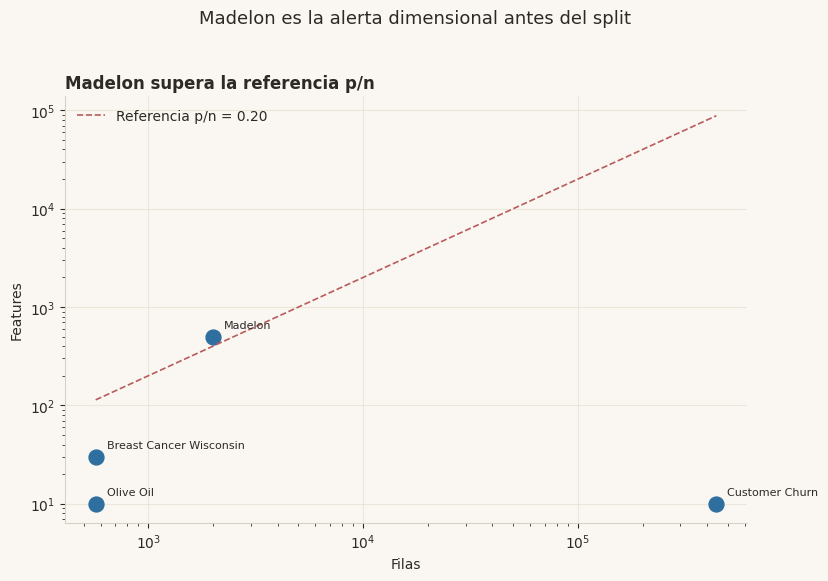

In [106]:
figura, eje = plt.subplots(figsize=(8.4, 5.6))
eje.scatter(dimensionality_with_pca["filas"], dimensionality_with_pca["features"], s=115, color="#2F6F9F")
x_values = np.array([dimensionality_with_pca["filas"].min(), dimensionality_with_pca["filas"].max()])
eje.plot(x_values, DIMENSIONALITY_RATIO_REFERENCE * x_values, color="#B85C5C", linewidth=1.2, linestyle="--", label="Referencia p/n = 0.20")
for _, row in dimensionality_with_pca.iterrows():
    eje.annotate(etiqueta_dataset(row["dataset"]), (row["filas"], row["features"]), xytext=(8, 6), textcoords="offset points", fontsize=8)
eje.set_xscale("log")
eje.set_yscale("log")
eje.set_xlabel("Filas")
eje.set_ylabel("Features")
eje.set_title("Madelon supera la referencia p/n", loc="left", fontweight="bold")
eje.legend(frameon=False)
aplicar_estilo_eje(eje, eje_rejilla="both")
fijar_titulo_narrativo(figura, "Madelon es la alerta dimensional antes del split")
cerrar_figura_narrativa(figura, "fase3_dimensionalidad_final.png")


Lectura de la figura dimensional: `madelon` queda por encima de la referencia p/n=0.20 con ratio 0.250, mientras los otros 3 datasets permanecen por debajo. Esta diferencia justifica tratar su selección de variables con especial cautela.


## 3.10 Síntesis Métrica Para la Fase 4

Se reúne una tabla final de métricas para orientar el split a partir de condiciones medibles de las secciones anteriores. El criterio de lectura combina cuatro riesgos: ratio features/muestras para dimensionalidad, ratio mayoritaria/minoritaria para estratificación del target, número de categóricas pendientes para evitar fuga en encoding y pares Spearman `>=0.85` para redundancia. La figura 2x2 no decide modelos ni selecciona variables; ordena las restricciones que Fase 4 debe preservar antes de que Fase 5 y QFS comparen relevancia y redundancia.


In [107]:
final_metric_summary = (
    structure_summary[["dataset", "filas", "features", "variables_categoricas", "columnas_duplicadas", "target_clases"]]
    .merge(target_summary[["dataset", "ratio_mayoritaria_minoritaria"]], on="dataset", how="left")
    .merge(correlation_summary[["dataset", "pares_abs_spearman_ge_085", "abs_spearman_maxima", "vif_max"]], on="dataset", how="left")
    .merge(dimensionality_with_pca[["dataset", "ratio_features_muestras", "pca_varianza_2", "pca_varianza_5"]], on="dataset", how="left")
)

quality_totals = nulls_summary.groupby("dataset", as_index=False).agg(
    nulos_totales=("nulos", "sum"),
    infinitos_totales=("infinitos", "sum"),
)
final_metric_summary = final_metric_summary.merge(quality_totals, on="dataset", how="left")

guardar_tabla(final_metric_summary, "fase3_resumen_metricas_split.csv")
mostrar_tabla(final_metric_summary, "Resumen métrico para Fase 4")

def resumen_metricas_split_markdown(tabla):
    total_nulos = int(tabla["nulos_totales"].sum())
    total_infinitos = int(tabla["infinitos_totales"].sum())
    max_ratio = tabla.sort_values("ratio_features_muestras", ascending=False).iloc[0]
    max_balance = tabla.sort_values("ratio_mayoritaria_minoritaria", ascending=False).iloc[0]
    return (
        "**Lectura de la tabla métrica para Fase 4.** "
        f"La tabla resume {len(tabla)} datasets y confirma {total_nulos} nulos y {total_infinitos} infinitos antes del split. "
        f"`{max_ratio['dataset']}` fija la mayor carga dimensional con ratio p/n={max_ratio['ratio_features_muestras']:.3f}; "
        f"`{max_balance['dataset']}` fija el mayor desbalance con ratio={max_balance['ratio_mayoritaria_minoritaria']:.2f}. "
        "Estas dos cifras explican por qué la síntesis visual separa dimensionalidad y target en paneles distintos."
    )


display(Markdown(resumen_metricas_split_markdown(final_metric_summary)))


**Resumen métrico para Fase 4** - 4 filas, 15 columnas.

,Dataset,Filas,Variables predictoras,Variables categóricas,Columnas duplicadas,Clases del target,Ratio mayoritaria/minoritaria,Pares Spearman >=0.85,|Spearman| máxima,VIF máximo,Ratio predictoras/muestras,Varianza PCA 2,Varianza PCA 5,Nulos totales,Infinitos totales
0,breast_cancer_wisconsin,569,30,0,0,2,1.683962,29,0.999602,3806.115296,0.052724,0.632432,0.847343,0,0
1,customer_churn,440832,10,3,0,2,1.310041,0,0.199095,1.098391,0.000023,0.362158,0.769217,0,0
2,madelon,2000,500,0,0,2,1.000000,12,0.996145,116.630730,0.250000,0.022975,0.042913,0,0
3,olive_oil,572,10,0,0,9,8.240000,2,0.916474,325.937133,0.017483,0.709206,0.944328,0,0


**Lectura de la tabla métrica para Fase 4.** La tabla resume 4 datasets y confirma 0 nulos y 0 infinitos antes del split. `madelon` fija la mayor carga dimensional con ratio p/n=0.250; `olive_oil` fija el mayor desbalance con ratio=8.24. Estas dos cifras explican por qué la síntesis visual separa dimensionalidad y target en paneles distintos.

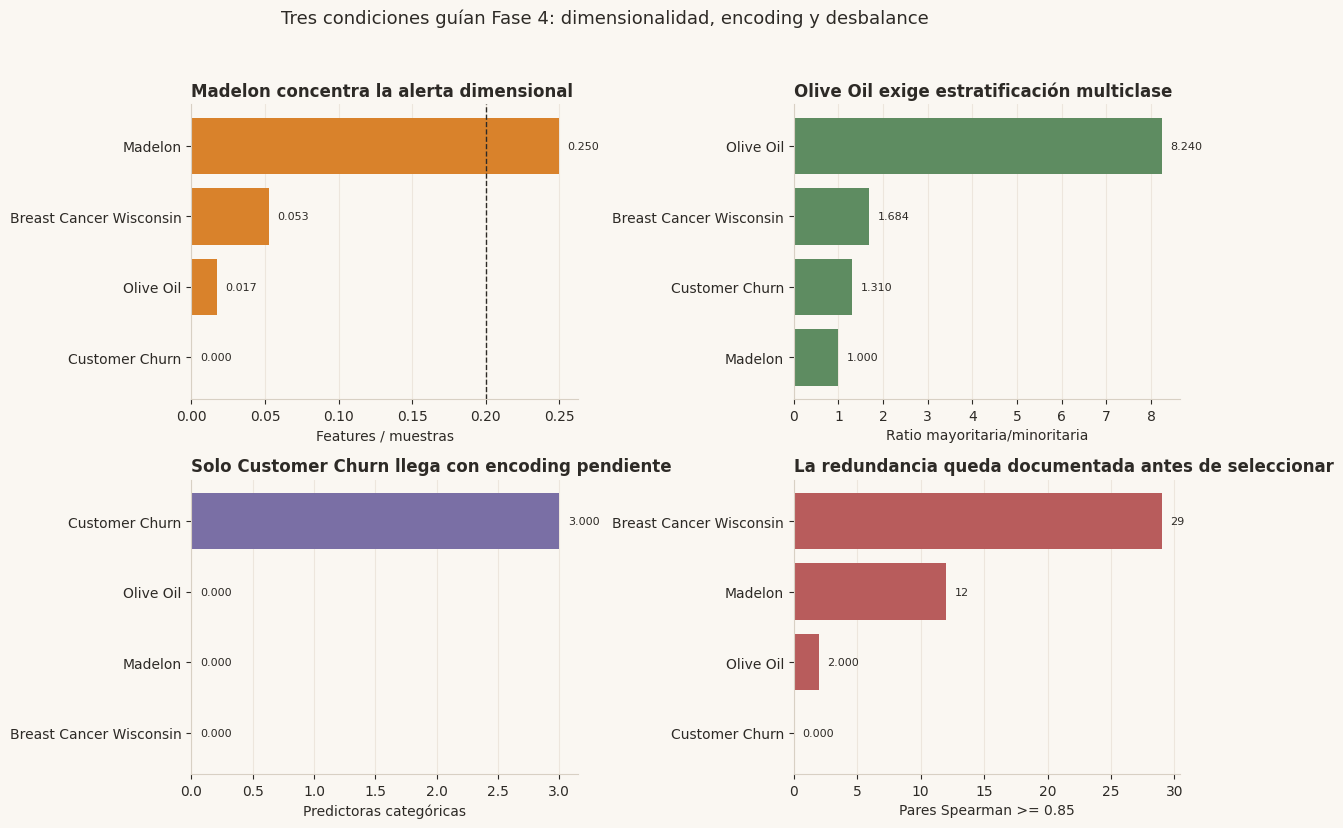

**Lectura del panel 2x2 de síntesis.** Arriba izquierda, dimensionalidad: `madelon` domina con ratio p/n=0.250, frente a la referencia 0.20; por eso 3.11 lo marca como caso que exige control de selección. Arriba derecha, target: `olive_oil` alcanza ratio mayoritaria/minoritaria=8.24, lo que justifica estratificación cuidadosa. Abajo izquierda, encoding: `customer_churn` acumula 3 predictoras categóricas, de modo que el encoder debe ajustarse después del split. Abajo derecha, redundancia: `breast_cancer_wisconsin` concentra 29 pares Spearman >=0.85; esa cifra enlaza con la conclusión de no eliminar variables aquí, sino entregar la estructura a selección clásica y QFS.

In [108]:
figura, ejes = plt.subplots(2, 2, figsize=(12.2, 8.0))
ejes = ejes.ravel()
plot_summary = final_metric_summary.copy()
plot_summary["dataset_label"] = plot_summary["dataset"].map(etiqueta_dataset)

def dibujar_barra_sintesis(eje, tabla, columna, titulo, xlabel, color, referencia=None):
    ordered = tabla.sort_values(columna)
    eje.barh(ordered["dataset_label"], ordered[columna], color=color)
    if referencia is not None:
        eje.axvline(referencia, color="#2D2A26", linewidth=1.0, linestyle="--")
    for _, row in ordered.iterrows():
        valor = row[columna]
        etiqueta = f"{valor:.3f}" if abs(valor) < 10 else f"{valor:.0f}"
        eje.annotate(etiqueta, (valor, row["dataset_label"]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=8)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel(xlabel)
    aplicar_estilo_eje(eje, eje_rejilla="x")


dibujar_barra_sintesis(ejes[0], plot_summary, "ratio_features_muestras", "Madelon concentra la alerta dimensional", "Features / muestras", "#D9822B", DIMENSIONALITY_RATIO_REFERENCE)
dibujar_barra_sintesis(ejes[1], plot_summary, "ratio_mayoritaria_minoritaria", "Olive Oil exige estratificación multiclase", "Ratio mayoritaria/minoritaria", "#5E8C61")
dibujar_barra_sintesis(ejes[2], plot_summary, "variables_categoricas", "Solo Customer Churn llega con encoding pendiente", "Predictoras categóricas", "#7A6FA5")
dibujar_barra_sintesis(ejes[3], plot_summary, "pares_abs_spearman_ge_085", "La redundancia queda documentada antes de seleccionar", "Pares Spearman >= 0.85", "#B85C5C")

fijar_titulo_narrativo(figura, "Tres condiciones guían Fase 4: dimensionalidad, encoding y desbalance")
cerrar_figura_narrativa(figura, "fase3_sintesis_metricas_split.png")

def lectura_panel_sintesis(tabla):
    row_dim = tabla.sort_values("ratio_features_muestras", ascending=False).iloc[0]
    row_balance = tabla.sort_values("ratio_mayoritaria_minoritaria", ascending=False).iloc[0]
    row_cat = tabla.sort_values("variables_categoricas", ascending=False).iloc[0]
    row_corr = tabla.sort_values("pares_abs_spearman_ge_085", ascending=False).iloc[0]
    return (
        "**Lectura del panel 2x2 de síntesis.** "
        f"Arriba izquierda, dimensionalidad: `{row_dim['dataset']}` domina con ratio p/n={row_dim['ratio_features_muestras']:.3f}, "
        f"frente a la referencia {DIMENSIONALITY_RATIO_REFERENCE:.2f}; por eso 3.11 lo marca como caso que exige control de selección. "
        f"Arriba derecha, target: `{row_balance['dataset']}` alcanza ratio mayoritaria/minoritaria={row_balance['ratio_mayoritaria_minoritaria']:.2f}, "
        "lo que justifica estratificación cuidadosa. "
        f"Abajo izquierda, encoding: `{row_cat['dataset']}` acumula {int(row_cat['variables_categoricas'])} predictoras categóricas, "
        "de modo que el encoder debe ajustarse después del split. "
        f"Abajo derecha, redundancia: `{row_corr['dataset']}` concentra {int(row_corr['pares_abs_spearman_ge_085'])} pares Spearman >=0.85; "
        "esa cifra enlaza con la conclusión de no eliminar variables aquí, sino entregar la estructura a selección clásica y QFS."
    )


display(Markdown(lectura_panel_sintesis(final_metric_summary)))


## 3.11 Conclusiones y Consideraciones Para la Fase 4

La auditoría confirma carga correcta, conservación de filas, target estable y ausencia de nulos o infinitos bloqueantes. El criterio de cierre exige que Fase 4 reciba datos particionables, que Fase 5 reciba señal y redundancia sin selección previa, y que QFS pueda medir `I(x_i;y)` e `I(x_i;x_j)` sobre datos y tablas reproducibles.

Condiciones para Fase 4:

- `customer_churn`: codificar categóricas después del split, ajustando el encoder solo con entrenamiento.
- `madelon`: tratar la relación features/muestras como dificultad dimensional.
- `olive_oil`: estratificar con atención al desbalance multiclase.
- Correlaciones y asociaciones son diagnóstico, no selección automática.


In [109]:
summary_lines = [
    "# Resultados de la Fase 3 - Auditoría Post-Preprocesado",
    "",
    "La Fase 3 verifica los datasets procesados antes del split y resume las condiciones medibles que afectan a la partición posterior.",
    "",
    "## Hallazgos principales",
    f"- El target conserva sus proporciones en todos los datasets: max |delta proporción| = {target_summary['max_delta_proporcion'].max():.6f}.",
    f"- Las variables numéricas comparables no muestran desplazamiento distribucional medible: KS máximo = {distribution_tests_summary['ks_maximo'].max():.6f}, PSI máximo = {distribution_tests_summary['psi_maximo'].max():.6f}.",
    f"- `customer_churn` mantiene {len(pending_categories[pending_categories['dataset'].eq('customer_churn')])} categóricas predictoras pendientes; deben codificarse después del split, ajustando el encoder solo con entrenamiento.",
    f"- La similitud de matrices crudas/procesadas es completa en las variables comparables: Frobenius máximo = {correlation_matrix_shift['frobenius_norm_difference'].max():.6f}.",
    f"- La mayor alerta de dimensionalidad es `madelon`, con ratio features/muestras = {float(dimensionality_with_pca.loc[dimensionality_with_pca['dataset'].eq('madelon'), 'ratio_features_muestras'].iloc[0]):.3f}.",
    "",
    "## Tablas generadas",
]

for table_path in sorted(PHASE3_TABLES_DIR.glob("fase3_*.csv")):
    summary_lines.append(f"- `{table_path.relative_to(PROJECT_ROOT)}`")

summary_lines.extend(["", "## Figuras generadas"])
for figure_path in sorted(PHASE3_FIGURES_DIR.glob("fase3_*.png")):
    summary_lines.append(f"- `{figure_path.relative_to(PROJECT_ROOT)}`")

summary_path = PHASE3_REPORTS_DIR / "fase3_resumen_para_memoria.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print("Resumen para memoria escrito correctamente.")
display(Markdown(
    f"**Lectura del informe exportado.** Se escribe `fase3_resumen_para_memoria.md` con {len(list(PHASE3_TABLES_DIR.glob('fase3_*.csv')))} tablas "
    f"y {len(list(PHASE3_FIGURES_DIR.glob('fase3_*.png')))} figuras PNG, cada una acompañada por su PDF vectorial."
))


Resumen para memoria escrito correctamente.


**Lectura del informe exportado.** Se escribe `fase3_resumen_para_memoria.md` con 25 tablas y 20 figuras PNG, cada una acompañada por su PDF vectorial.